# Exploratory Data Analysis

This notebook contains exploratory data analysis of our dataset which will help us determine features

In [11]:
%pip install pandas numpy matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 25.0
[notice] To update, run: python.exe -m pip install --upgrade pip


In [12]:
%pip install seaborn --upgrade


[notice] A new release of pip is available: 24.0 -> 25.0
[notice] To update, run: python.exe -m pip install --upgrade pip


In [13]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# # Set style for better visualizations
# plt.style.use(seaborn)
# sns.set_palette('Set2')

## 1. Data Loading

In [14]:
# Load your data here
file_paths = [
    "../data/Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv",
    "../data/Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv",
    "../data/Tuesday-WorkingHours.pcap_ISCX.csv",
    "../data/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv",
    "../data/Monday-WorkingHours.pcap_ISCX.csv",
    "../data/Friday-WorkingHours-Morning.pcap_ISCX.csv",
    "../data/Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv",
    "../data/Wednesday-workingHours.pcap_ISCX.csv"
]

data_frames = [pd.read_csv(file) for file in file_paths]
# df = pd.read_csv(path)
for df in data_frames:
    print(df.head()) 

# Display first few rows


    Destination Port   Flow Duration   Total Fwd Packets  \
0                 22         1266342                  41   
1                 22         1319353                  41   
2                 22             160                   1   
3                 22         1303488                  41   
4              35396              77                   1   

    Total Backward Packets  Total Length of Fwd Packets  \
0                       44                         2664   
1                       44                         2664   
2                        1                            0   
3                       42                         2728   
4                        2                            0   

    Total Length of Bwd Packets   Fwd Packet Length Max  \
0                          6954                     456   
1                          6954                     456   
2                             0                       0   
3                          6634                 

## 2. Data Overview

In [15]:
# Basic information about the dataset
df.info()

# Statistical summary
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 692703 entries, 0 to 692702
Data columns (total 79 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0    Destination Port             692703 non-null  int64  
 1    Flow Duration                692703 non-null  int64  
 2    Total Fwd Packets            692703 non-null  int64  
 3    Total Backward Packets       692703 non-null  int64  
 4   Total Length of Fwd Packets   692703 non-null  int64  
 5    Total Length of Bwd Packets  692703 non-null  int64  
 6    Fwd Packet Length Max        692703 non-null  int64  
 7    Fwd Packet Length Min        692703 non-null  int64  
 8    Fwd Packet Length Mean       692703 non-null  float64
 9    Fwd Packet Length Std        692703 non-null  float64
 10  Bwd Packet Length Max         692703 non-null  int64  
 11   Bwd Packet Length Min        692703 non-null  int64  
 12   Bwd Packet Length Mean       692703 non-nul

c:\Users\gurle\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
c:\Users\gurle\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Min Packet Length,Max Packet Length,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,CWE Flag Count,ECE Flag Count,Down/Up Ratio,Average Packet Size,Avg Fwd Segment Size,Avg Bwd Segment Size,Fwd Header Length.1,Fwd Avg Bytes/Bulk,Fwd Avg Packets/Bulk,Fwd Avg Bulk Rate,Bwd Avg Bytes/Bulk,Bwd Avg Packets/Bulk,Bwd Avg Bulk Rate,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
count,692703.000000,6.927030e+05,692703.000000,692703.000000,6.927030e+05,6.927030e+05,692703.000000,692703.000000,692703.000000,692703.000000,692703.000000,692703.000000,692703.000000,692703.000000,6.916950e+05,6.927030e+05,6.927030e+05,6.927030e+05,6.927030e+05,6.927030e+05,6.927030e+05,6.927030e+05,6.927030e+05,6.927030e+05,6.927030e+05,6.927030e+05,6.927030e+05,6.927030e+05,6.927030e+05,6.927030e+05,692703.000000,692703.0,692703.0,692703.0,6.927030e+05,6.927030e+05,6.927030e+05,6.927030e+05,692703.000000,692703.000000,692703.000000,692703.000000,6.927030e+05,692703.000000,692703.000000,692703.000000,692703.000000,692703.000000,692703.000000,692703.0,692703.000000,692703.000000,692703.000000,692703.000000,692703.000000,6.927030e+05,692703.0,692703.0,692703.0,692703.0,692703.0,692703.0,692703.000000,6.927030e+05,692703.000000,6.927030e+05,692703.000000,692703.000000,692703.000000,692703.000000,6.927030e+05,6.927030e+05,6.927030e+05,6.927030e+05,6.927030e+05,6.927030e+05,6.927030e+05,6.927030e+05
mean,5686.869462,2.800168e+07,9.556261,10.214079,5.550930e+02,1.699644e+04,233.593936,15.022183,60.555440,82.895863,1661.546313,33.832924,551.940841,658.636320,inf,inf,2.502809e+06,6.844318e+06,2.289307e+07,2.224592e+05,2.774476e+07,5.069287e+06,9.016685e+06,2.279837e+07,1.030778e+06,1.386407e+07,2.647068e+06,3.522882e+06,9.305284e+06,9.268549e+05,0.042201,0.0,0.0,0.0,2.420580e+02,2.492460e+02,9.545305e+04,4.052544e+03,13.723771,1725.129073,278.246605,523.265612,8.876018e+05,0.097301,0.042201,0.000338,0.193693,0.418049,0.066372,0.0,0.000339,0.556957,305.664882,60.555440,551.940841,2.420580e+02,0.0,0.0,0.0,0.0,0.0,0.0,9.556261,5.550930e+02,10.214079,1.699489e+04,5299.671256,1476.643078,6.121279,26.761141,9.224478e+04,4.760852e+04,1.627363e+05,6.315186e+04,2.211122e+07,4.743744e+05,2.252174e+07,2.173373e+07
std,15727.423560,4.276680e+07,747.197814,984.204633,6.163663e+03,2.241175e+06,603.751856,51.068835,157.643794,226.126084,2613.924428,64.586498,797.449564,1098.043102,NaN,NaN,5.595945e+06,1.175401e+07,3.839395e+07,3.673248e+06,4.277094e+07,1.103613e+07,1.600574e+07,3.843629e+07,8.866760e+06,3.335293e+07,9.593760e+06,1.073828e+07,2.616633e+07,8.107914e+06,0.201048,0.0,0.0,0.0,1.564277e+04,1.968957e+04,3.198607e+05,3.091927e+04,27.521716,2634.372188,369.130494,783.442461,1.748895e+06,0.296368,0.201048,0.018376,0.395192,0.493239,0.248931,0.0,0.018416,0.570734,398.045939,157.643794,797.449564,1.564277e+04,0.0,0.0,0.0,0.0,0.0,0.0,747.197814,6.163663e+03,984.204633,2.240953e+06,11869.737394,7315.272621,715.155068,6.322368,7.007049e+05,4.742081e+05,1.094616e+06,6.051023e+05,3.812415e+07,4.488512e+06,3.848292e+07,3.807725e+07
min,0.000000,-1.000000e+00,1.000000,

## 3. Missing Values Analysis

In [16]:
# Check for missing values
for df in data_frames:
    print(df.isnull().sum) 

<bound method DataFrame.sum of          Destination Port   Flow Duration   Total Fwd Packets  \
0                   False           False               False   
1                   False           False               False   
2                   False           False               False   
3                   False           False               False   
4                   False           False               False   
...                   ...             ...                 ...   
286462              False           False               False   
286463              False           False               False   
286464              False           False               False   
286465              False           False               False   
286466              False           False               False   

         Total Backward Packets  Total Length of Fwd Packets  \
0                         False                        False   
1                         False                        False

In [17]:
for df in data_frames:
    print(df['Flow Bytes/s'].isnull().sum())

15
20
201
4
64
28
18
1008


In [18]:
for df in data_frames:
    print(df['Total Length of Fwd Packets'].isnull().sum())  # Count of missing values in "Flow Bytes/s"

0
0
0
0
0
0
0
0


In [19]:
%pip install missingno


[notice] A new release of pip is available: 24.0 -> 25.0
[notice] To update, run: python.exe -m pip install --upgrade pip


c:\Users\gurle\AppData\Local\Programs\Python\Python39\lib\site-packages\missingno\missingno.py:366: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=figsize)


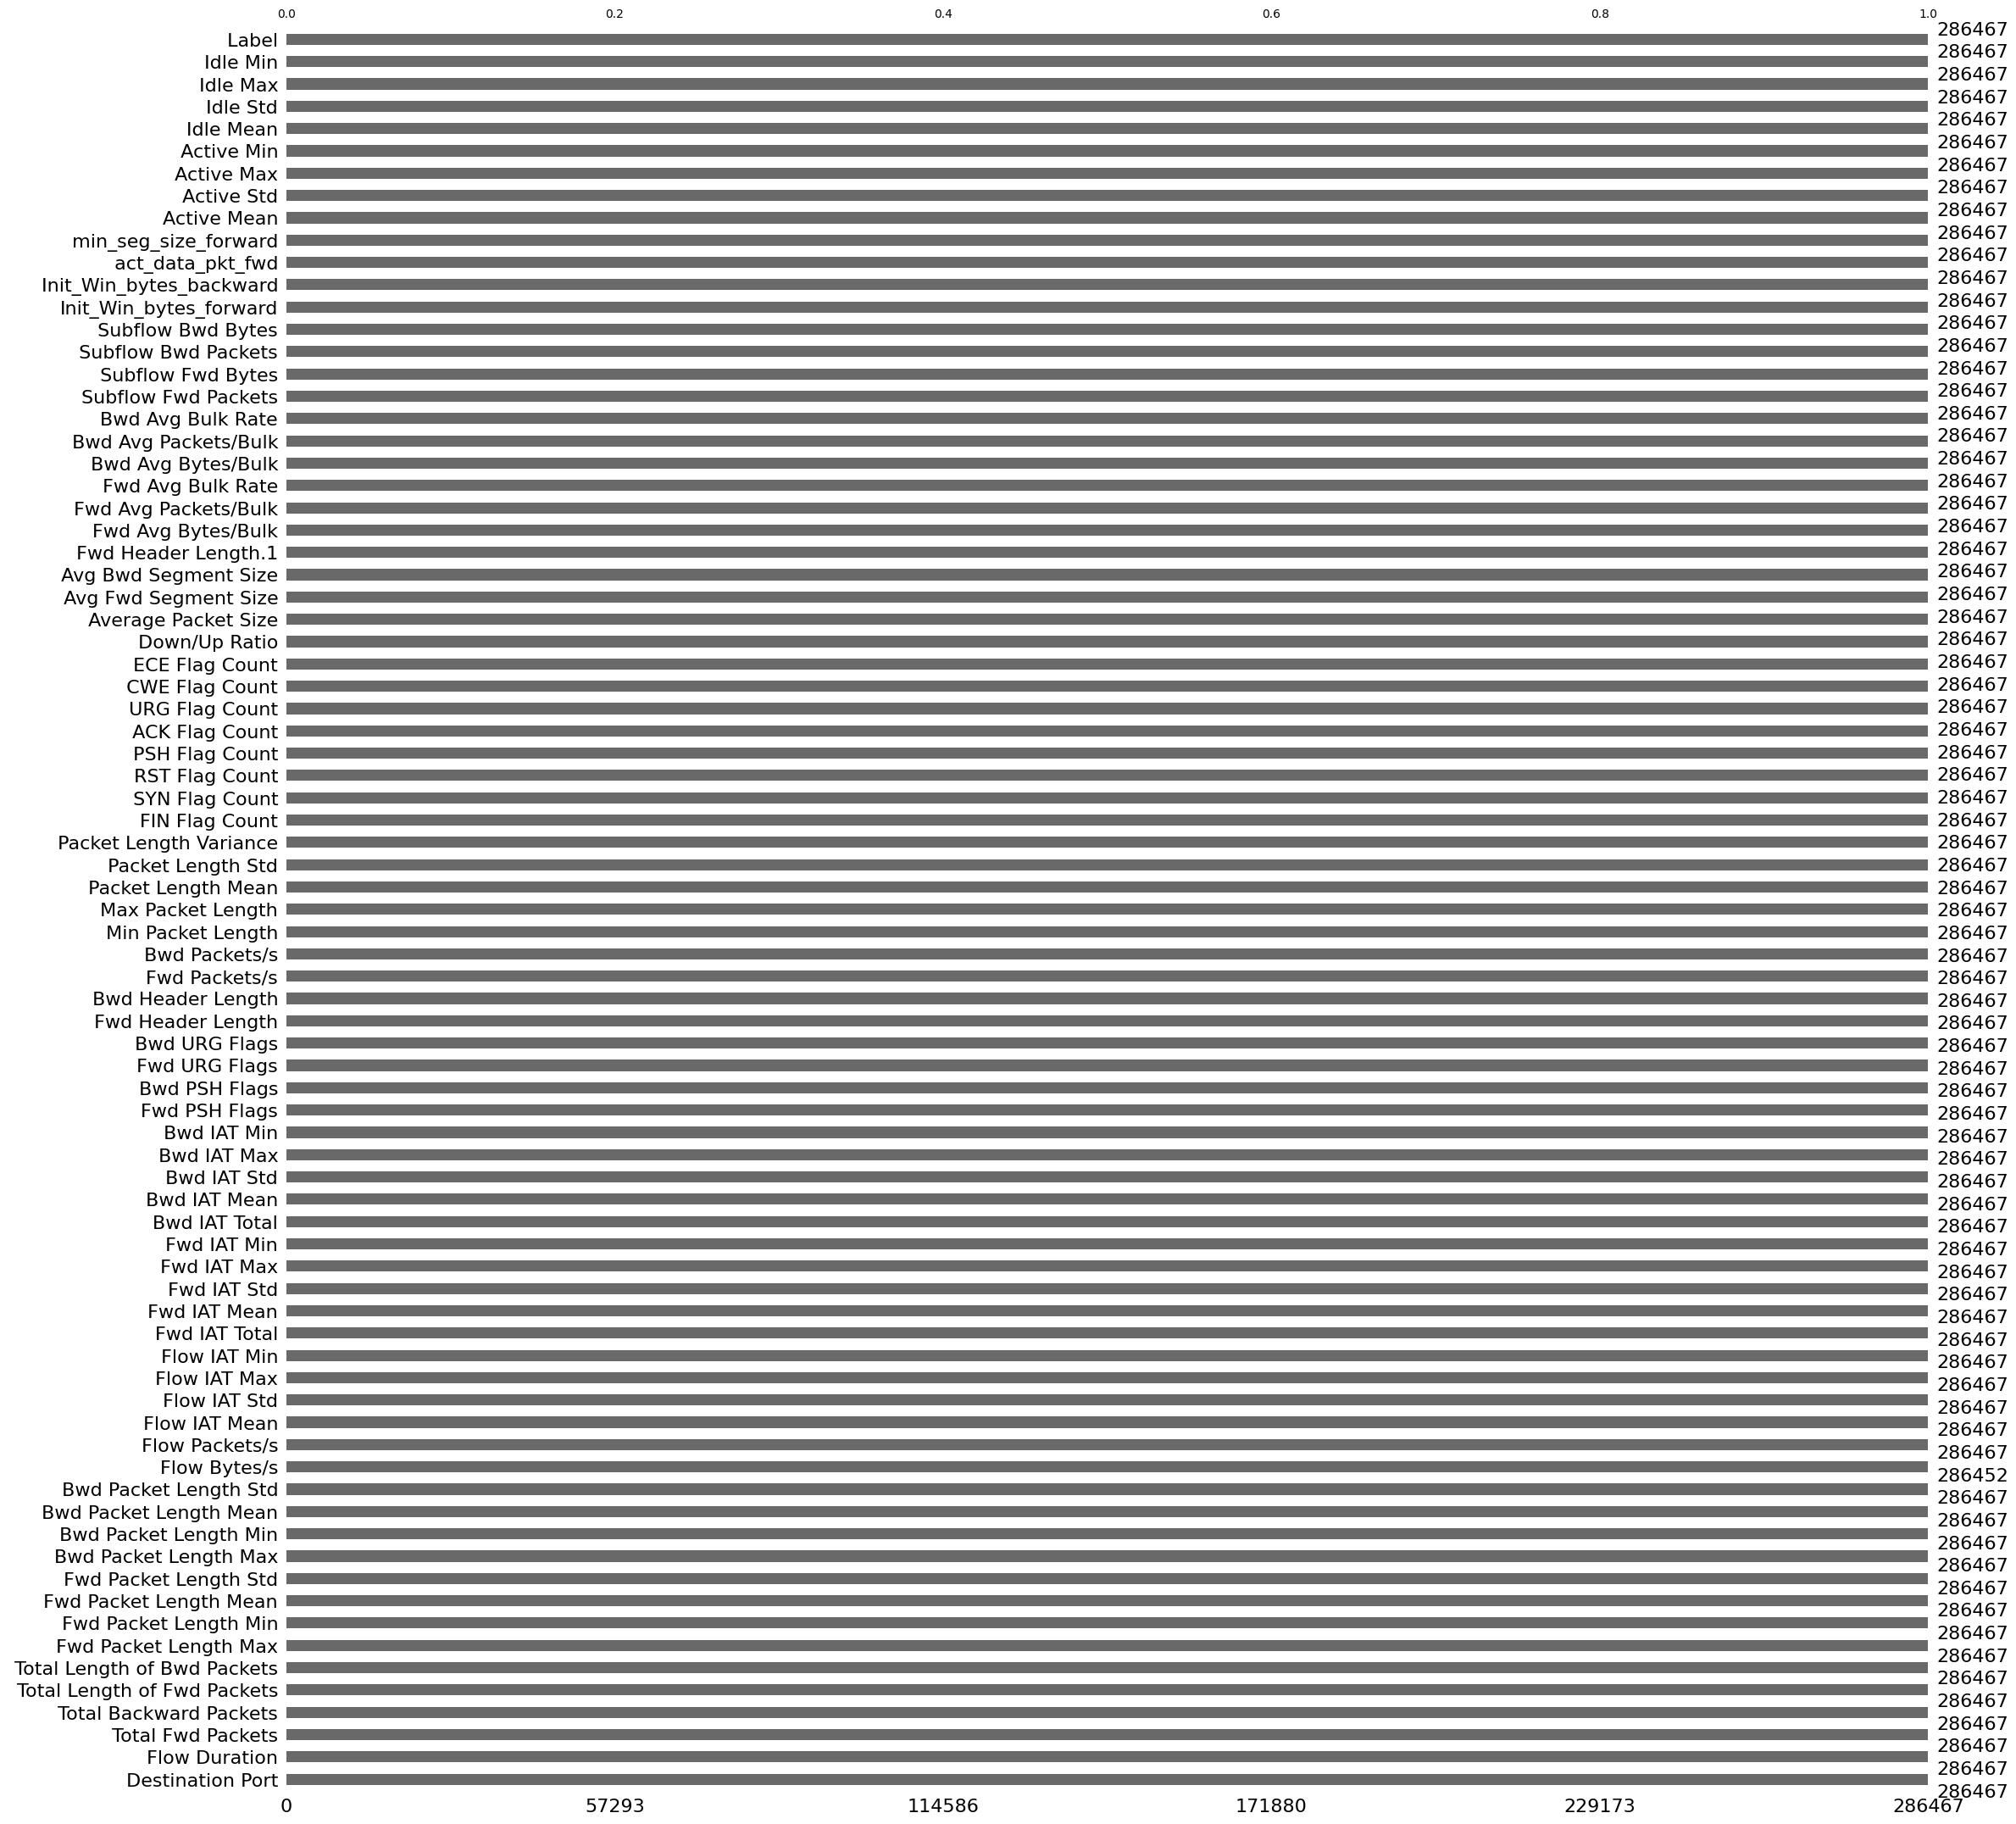

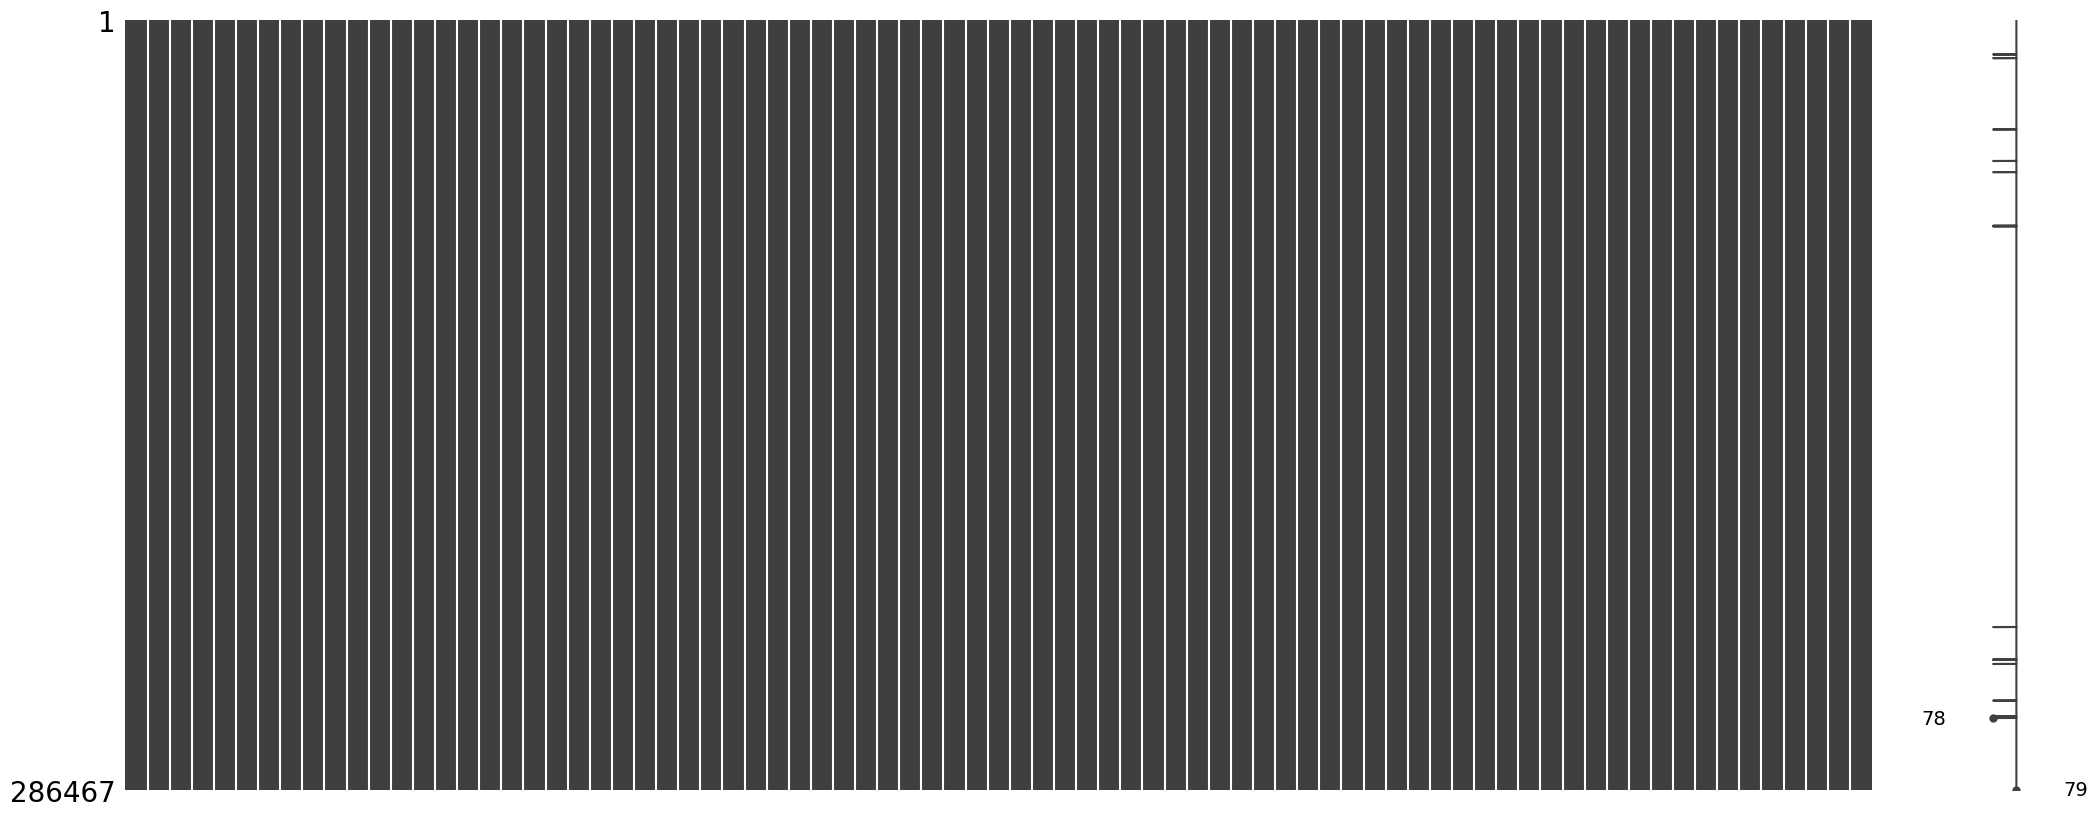

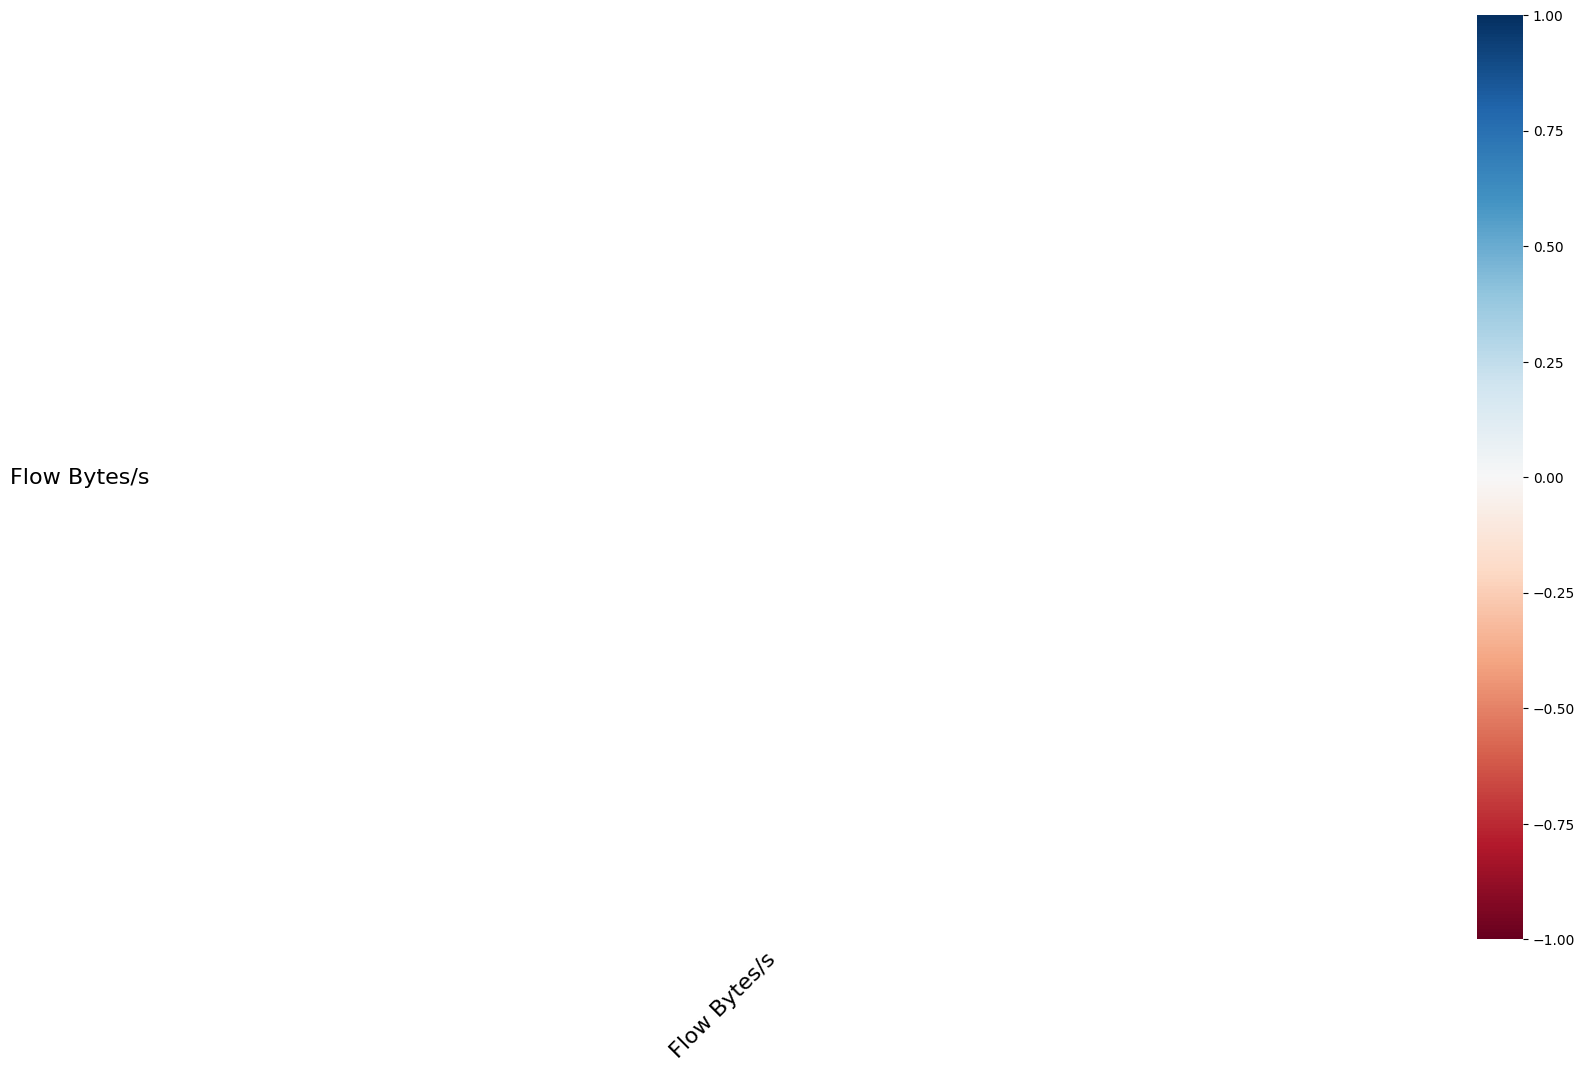

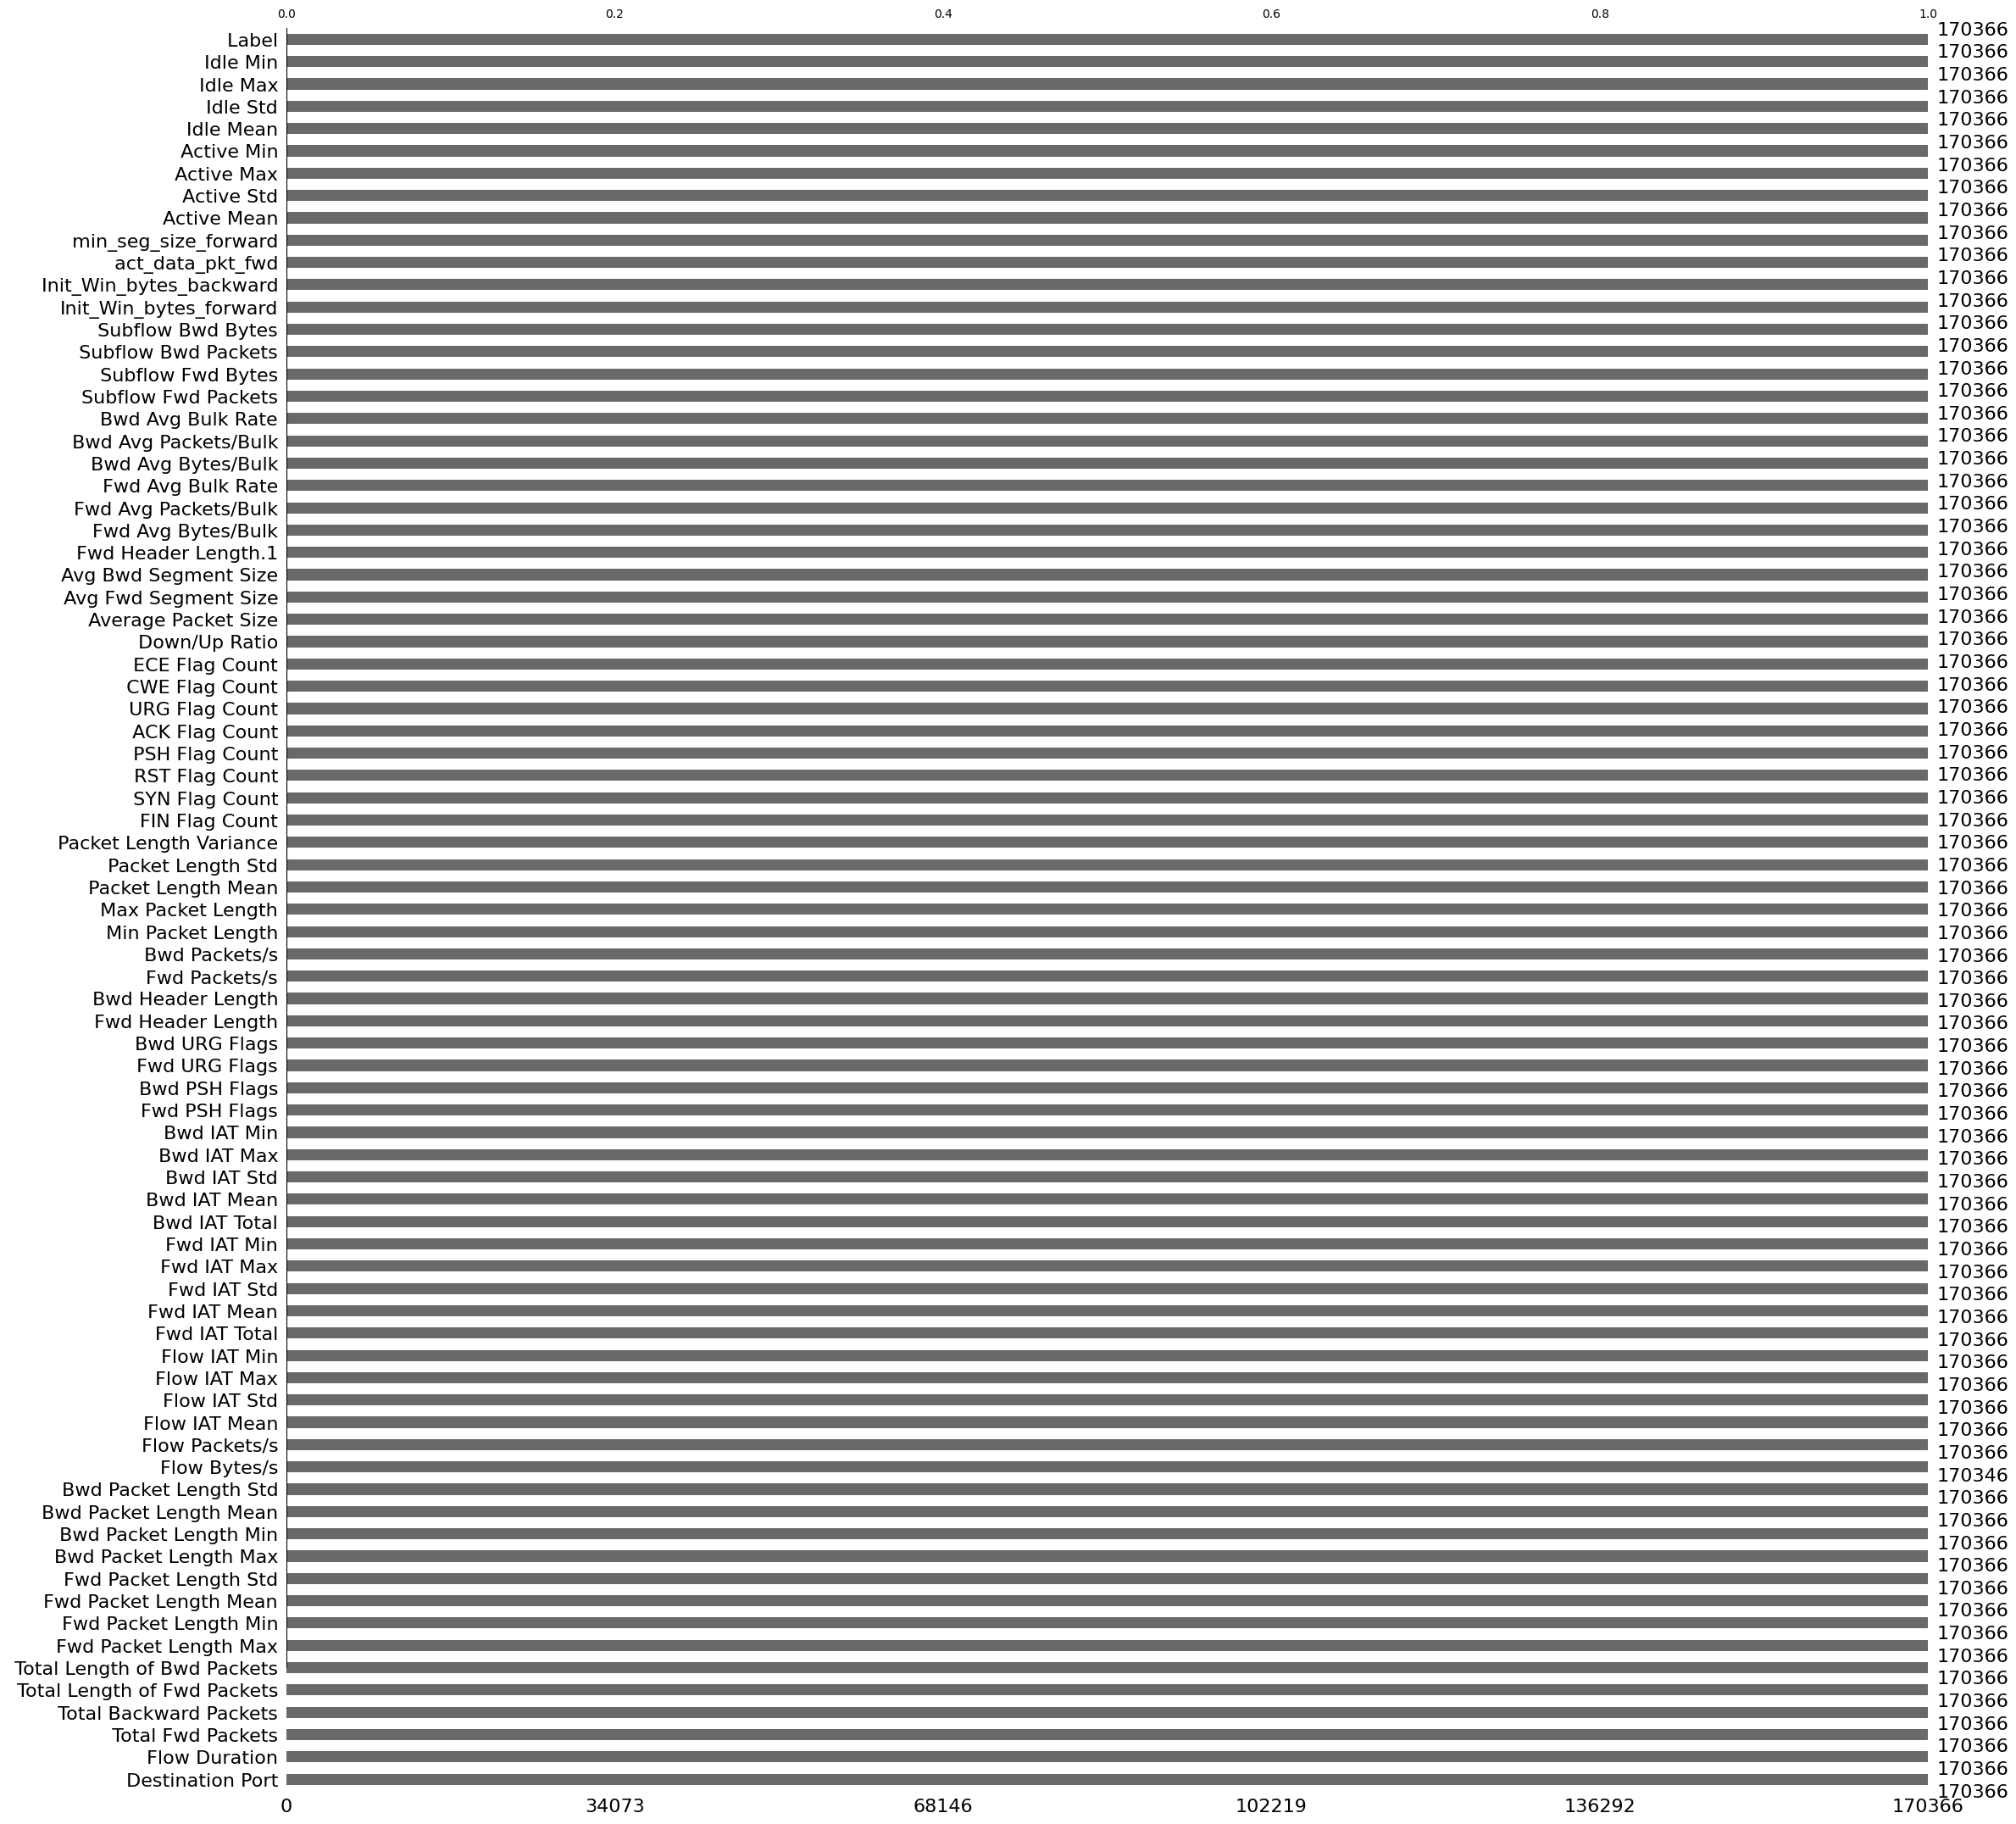

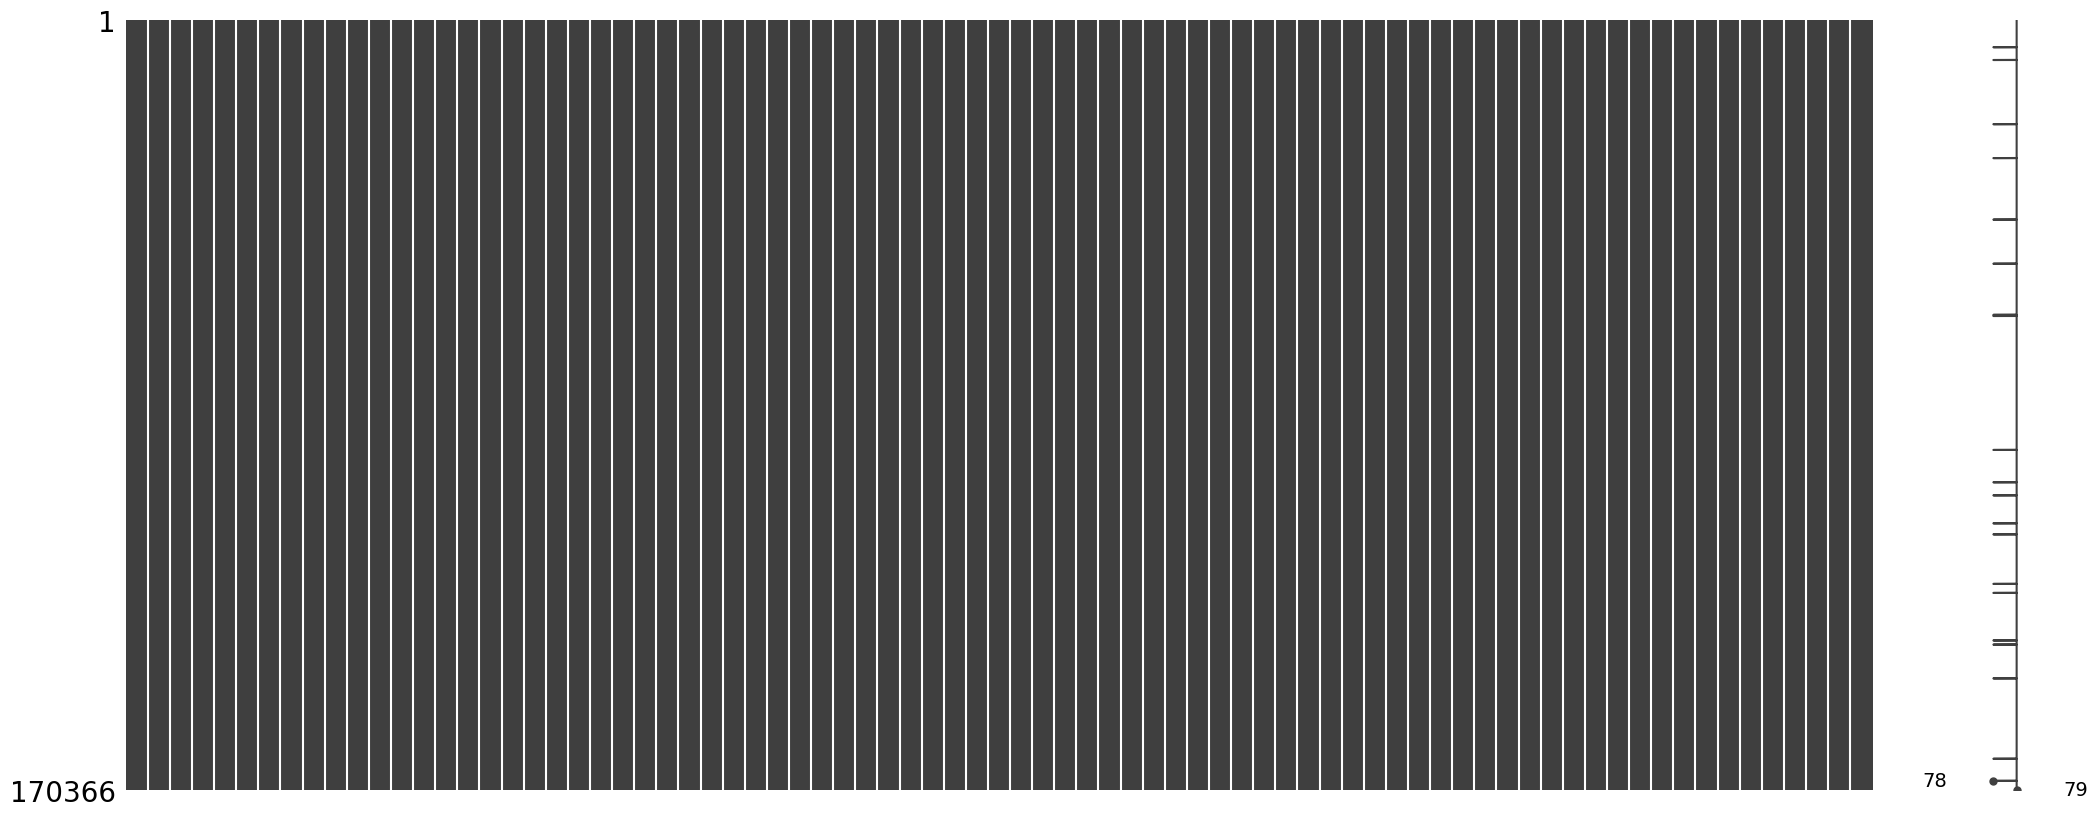

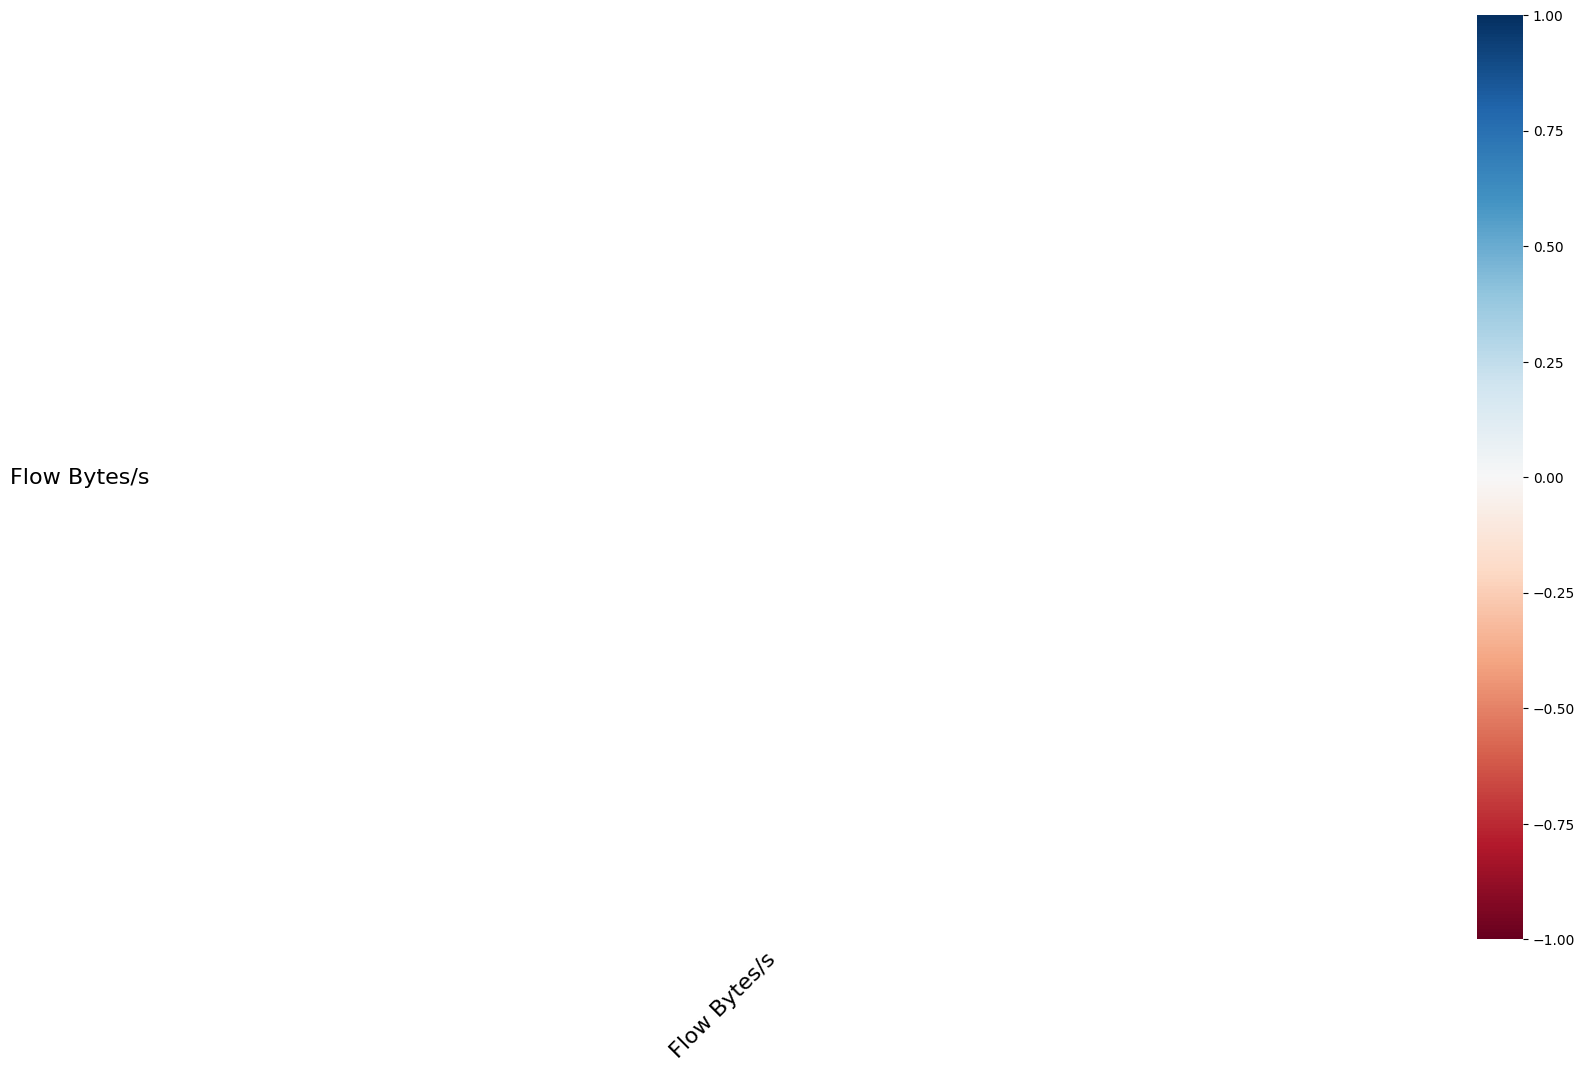

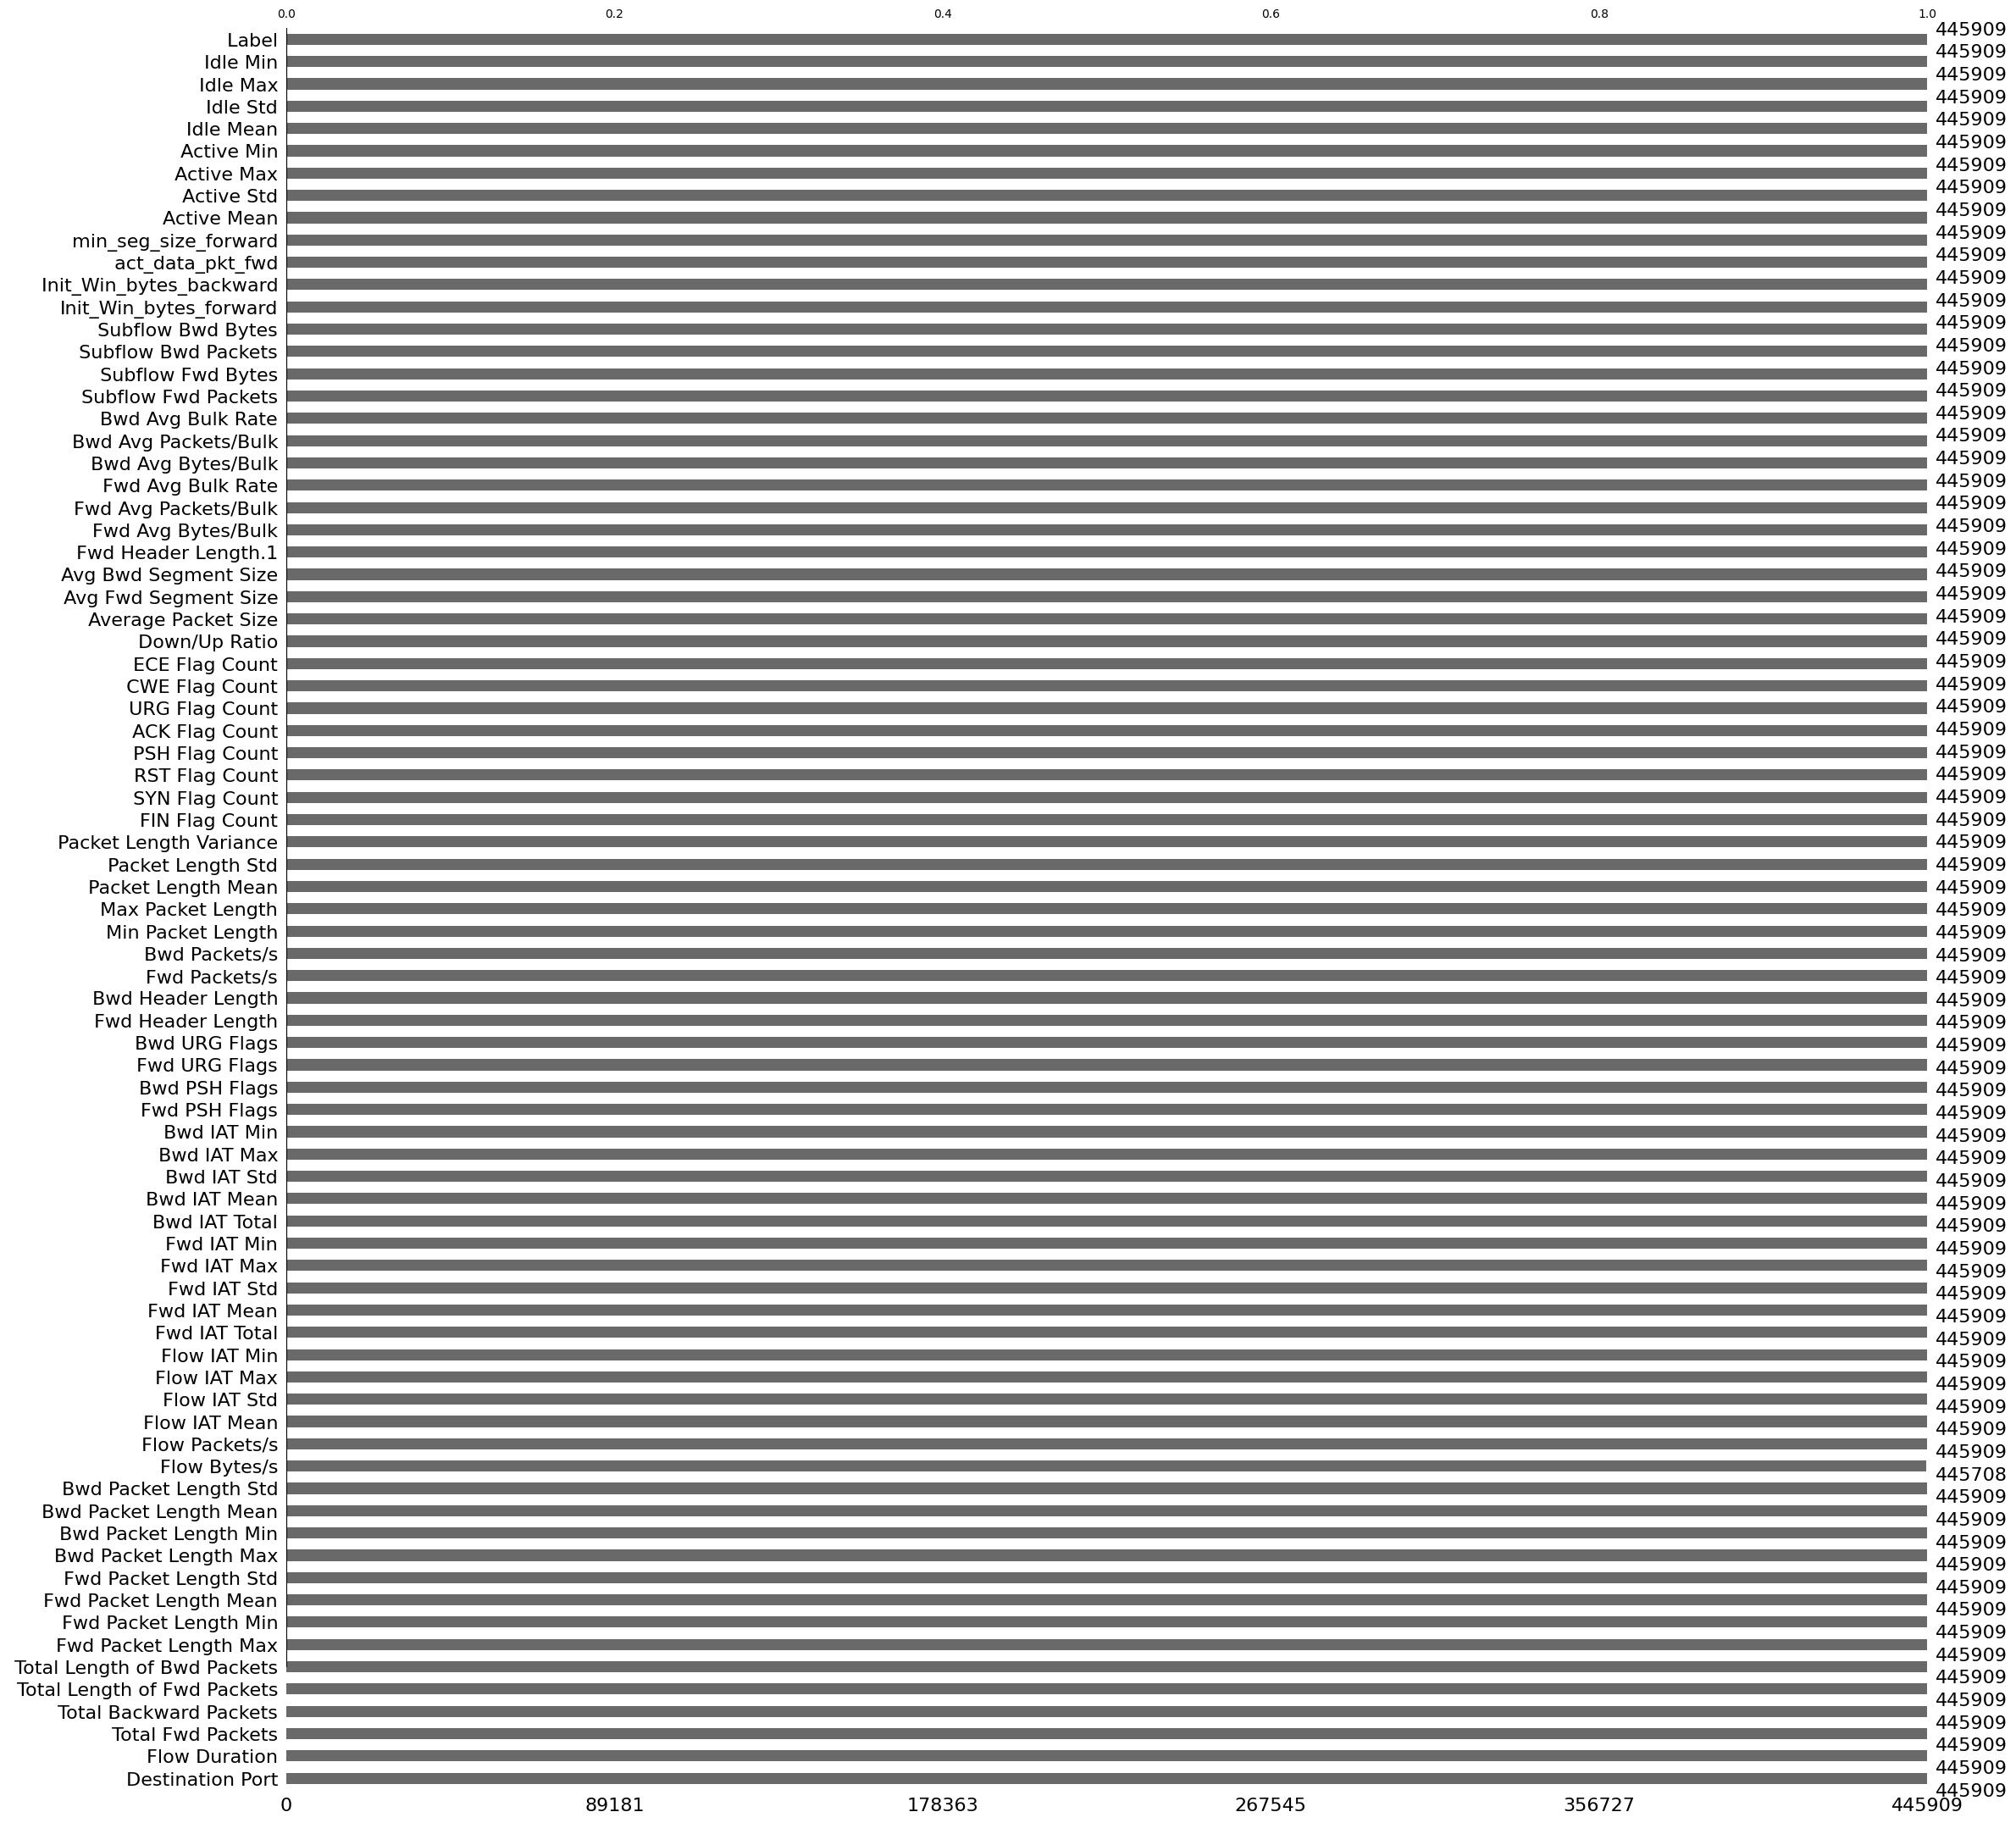

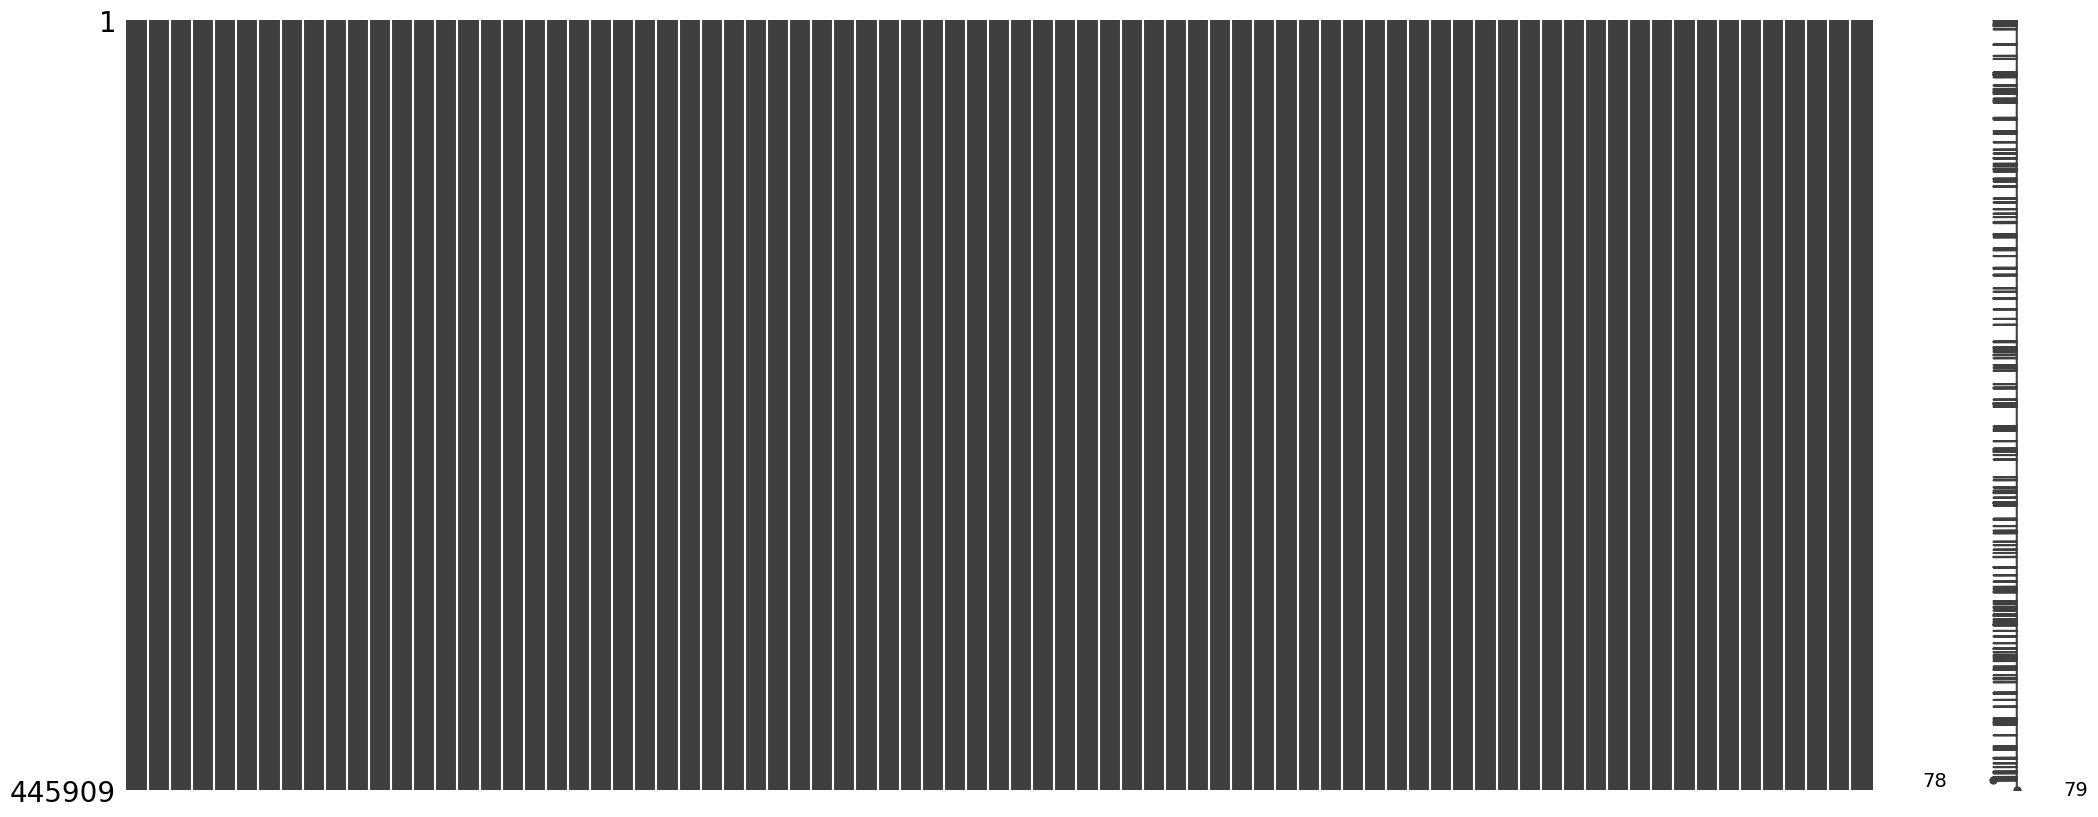

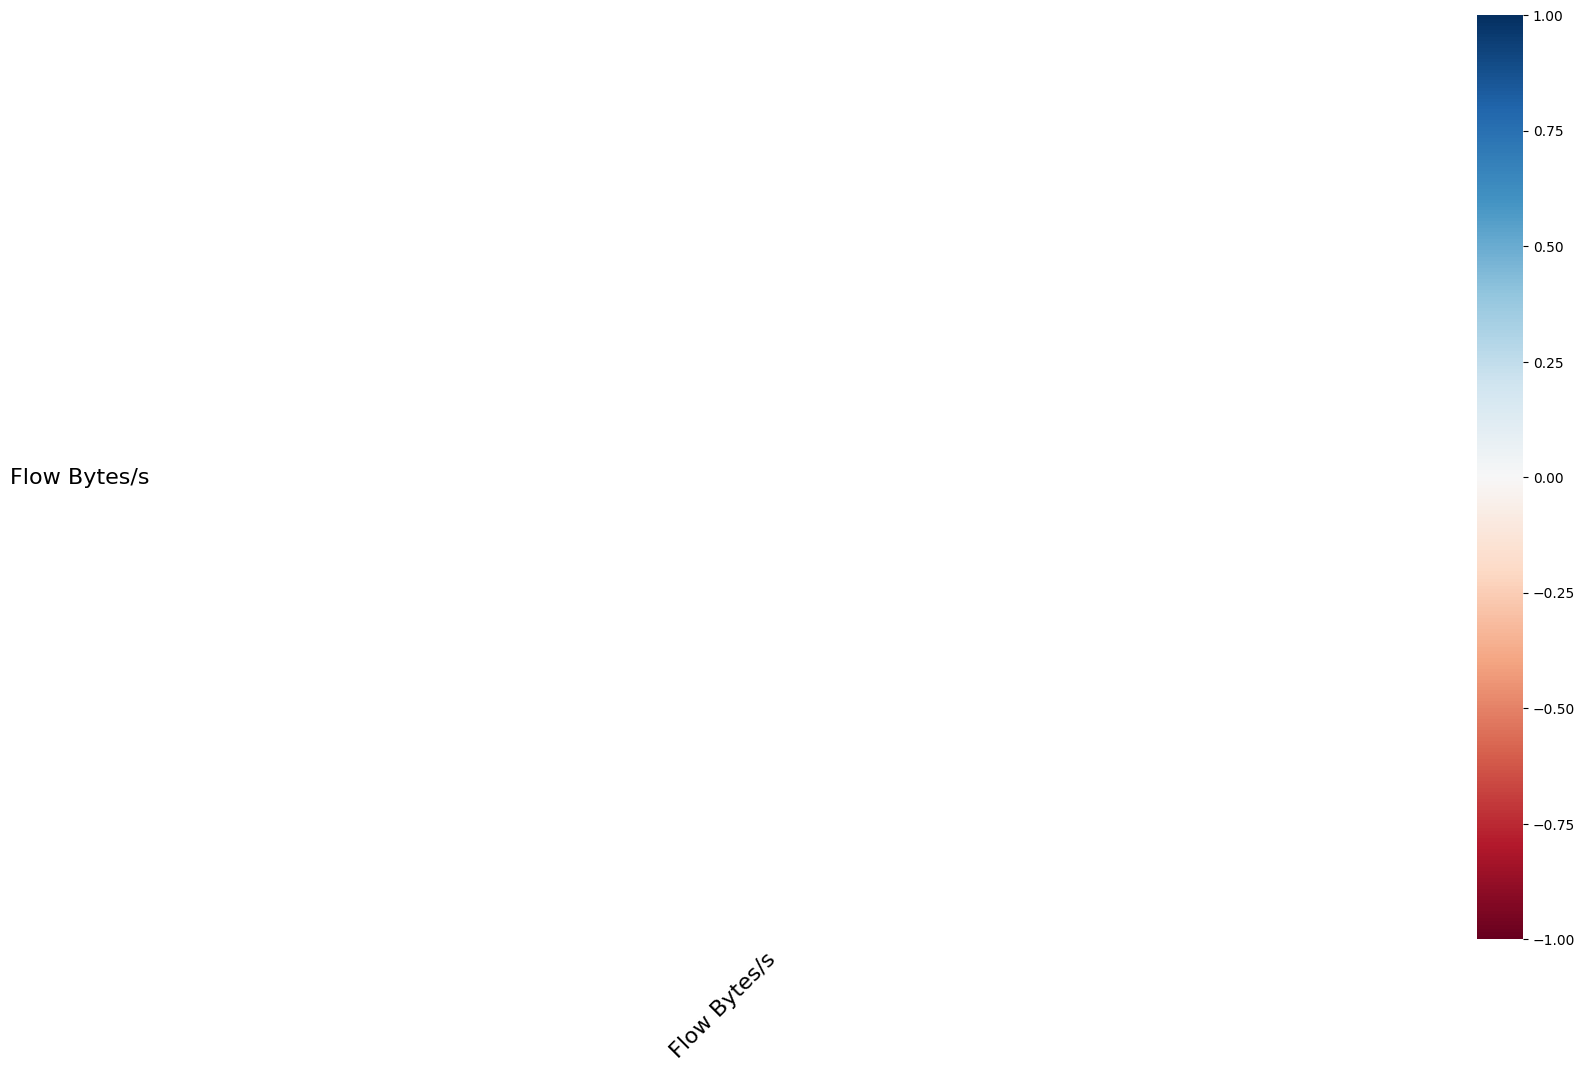

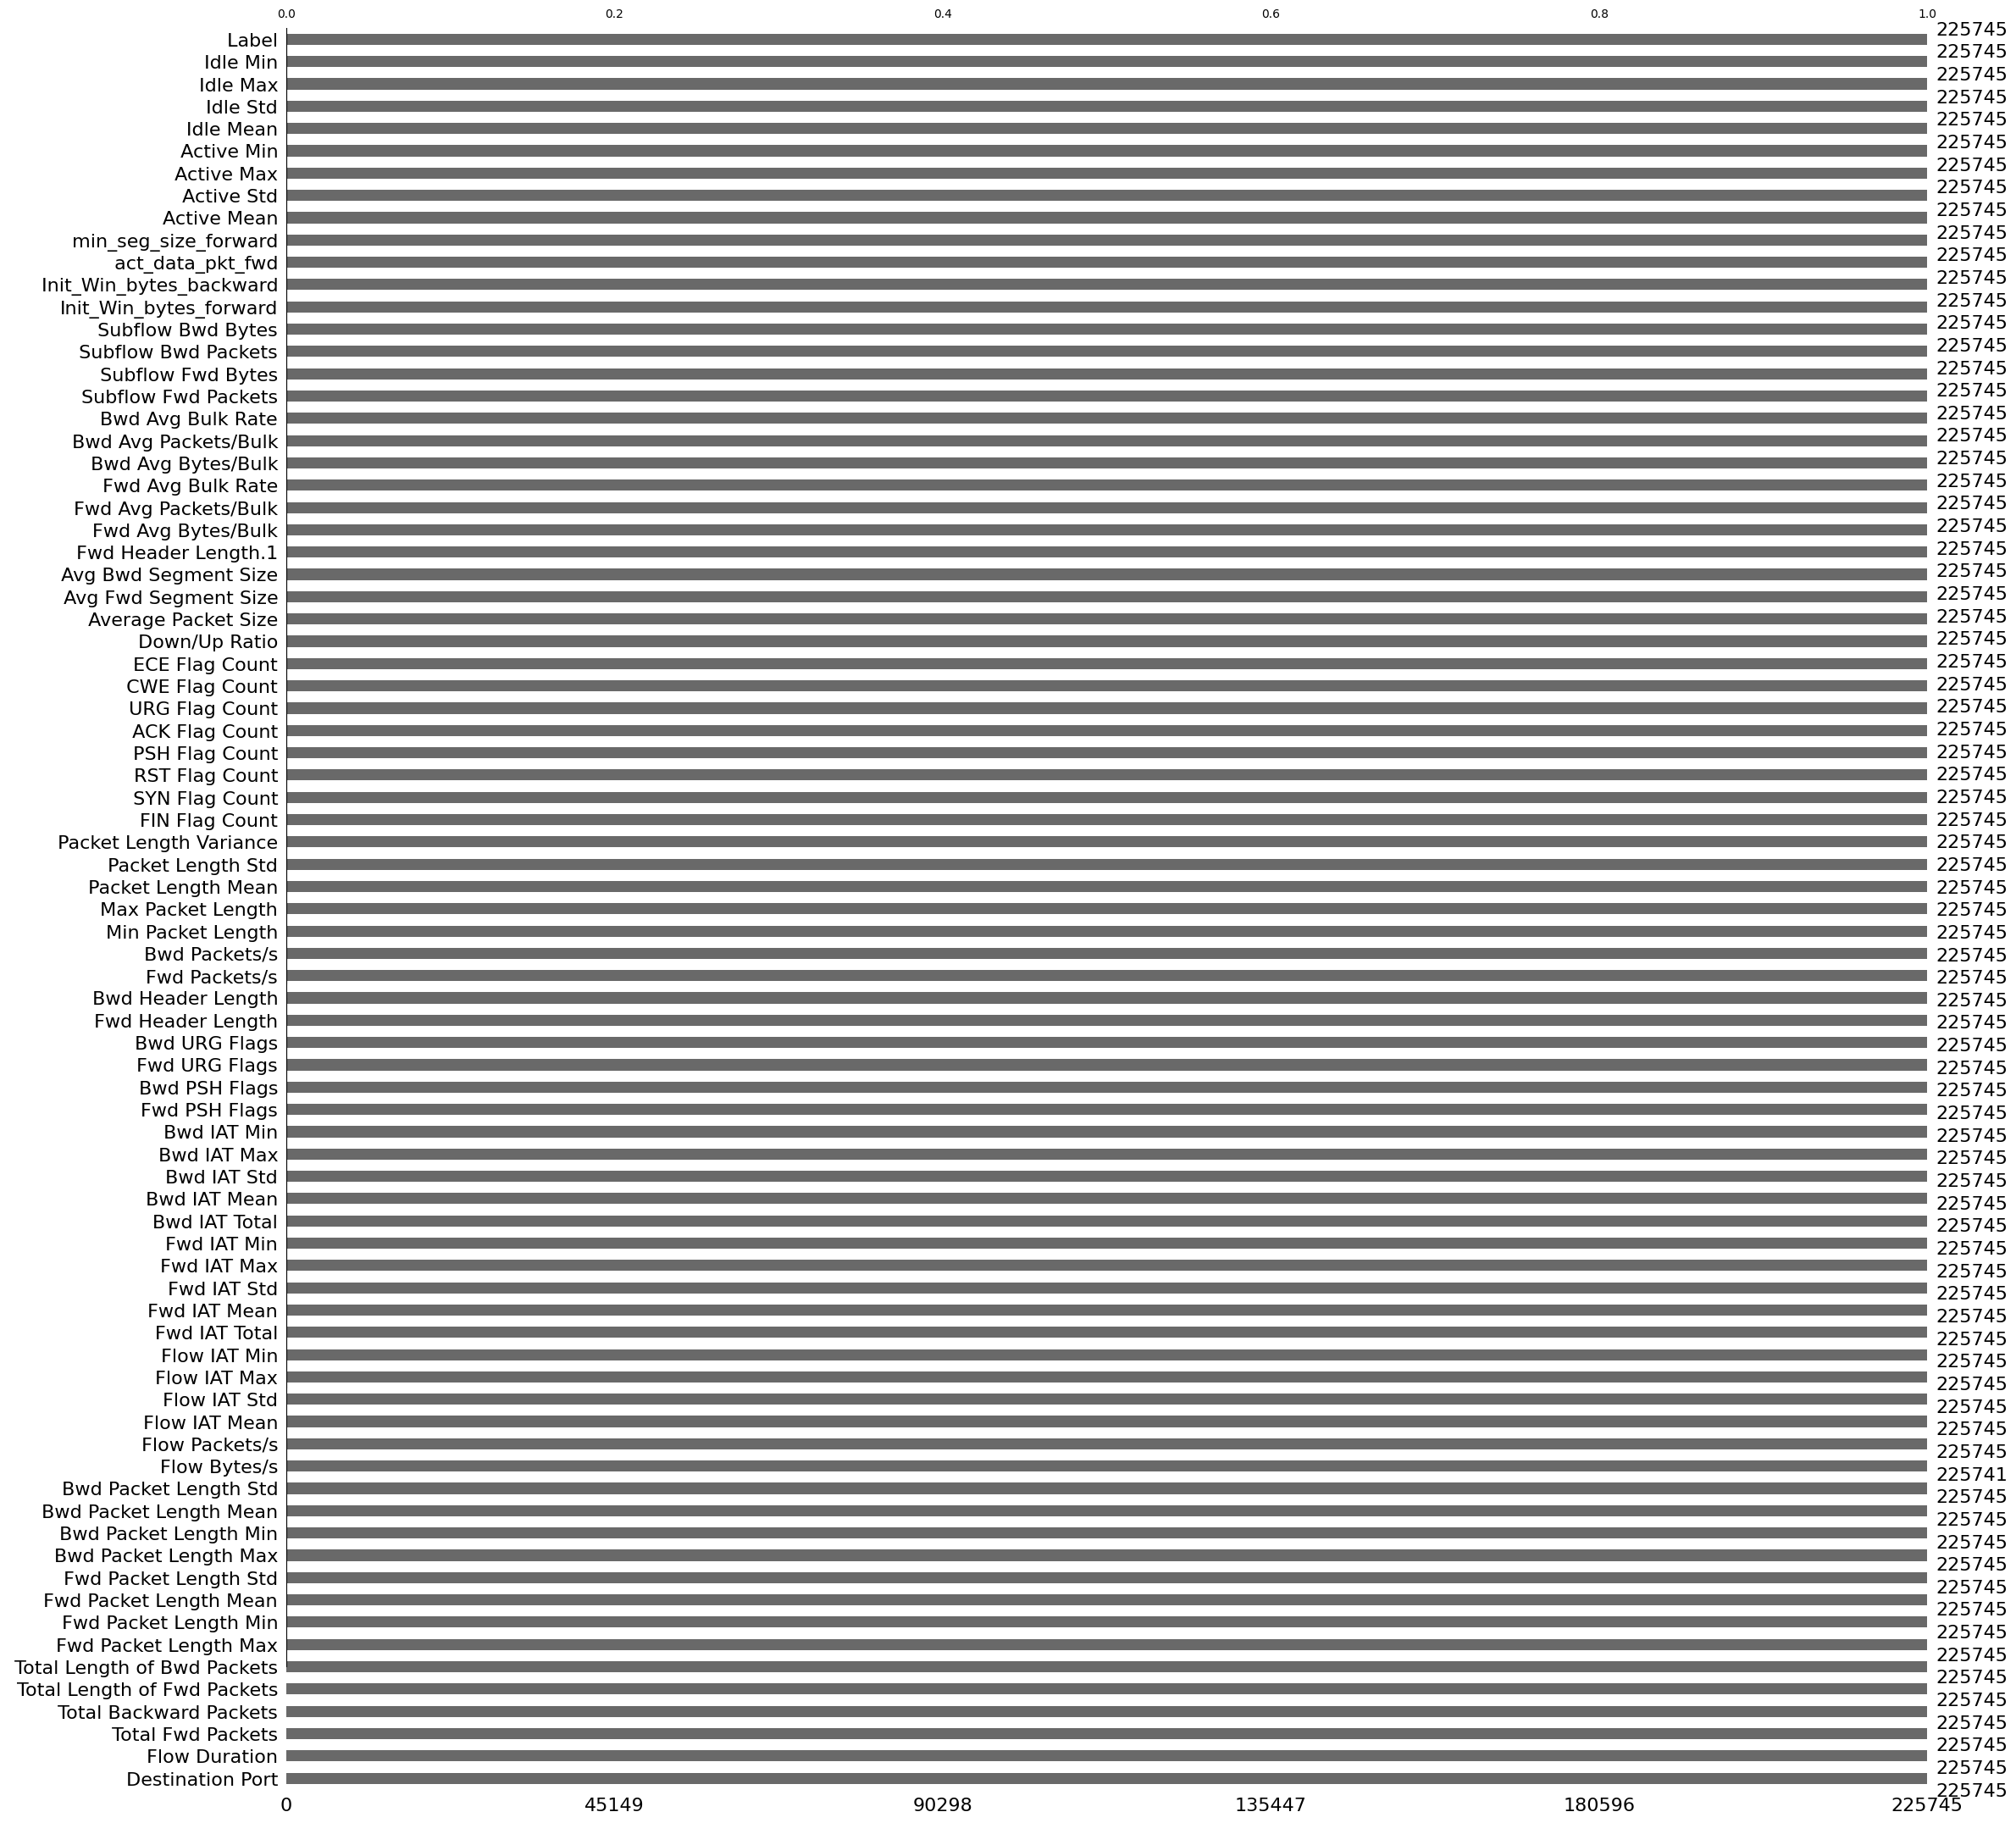

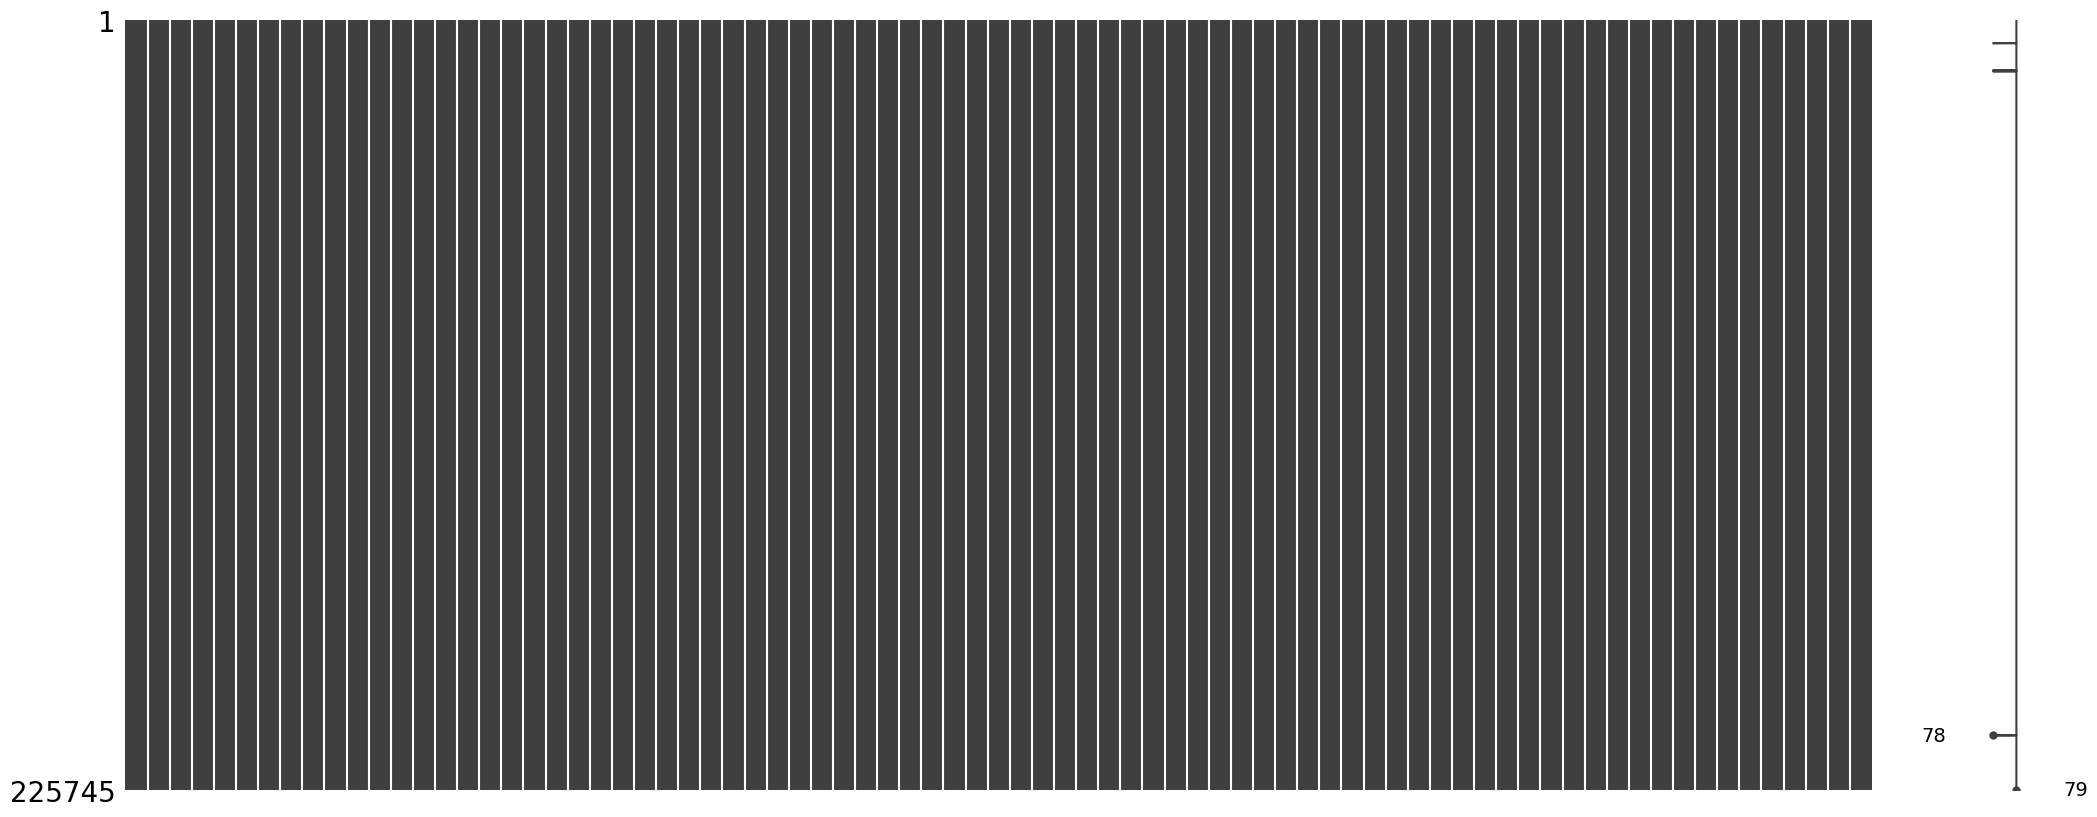

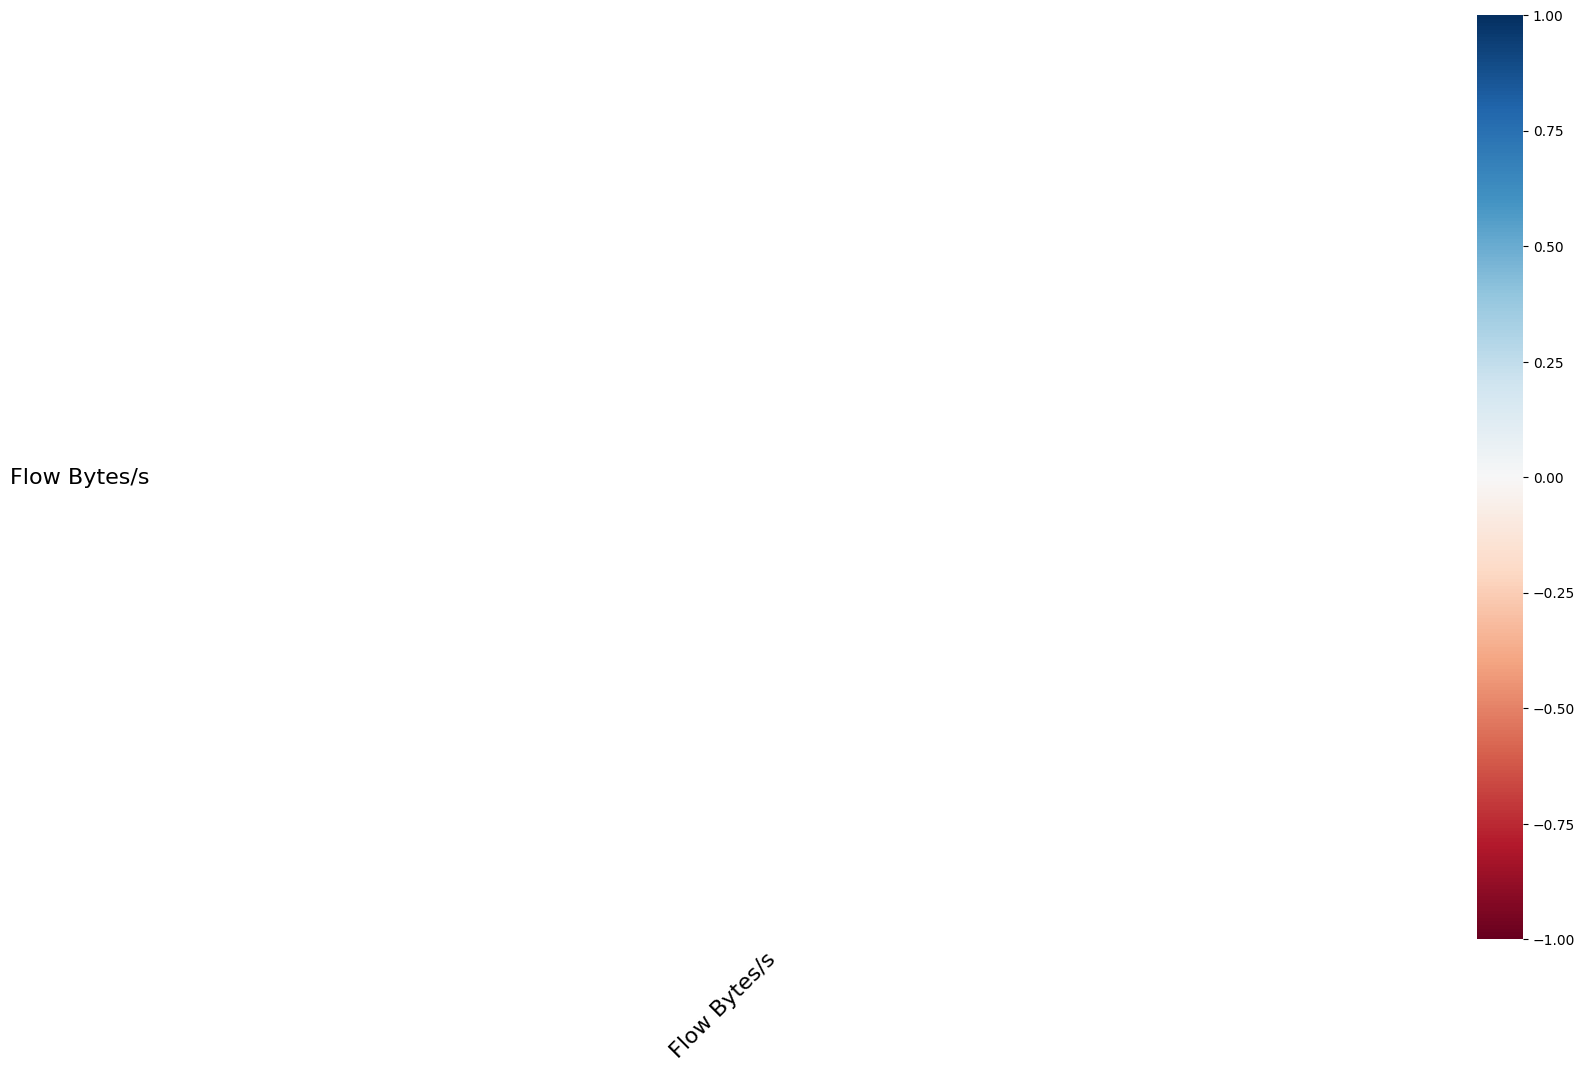

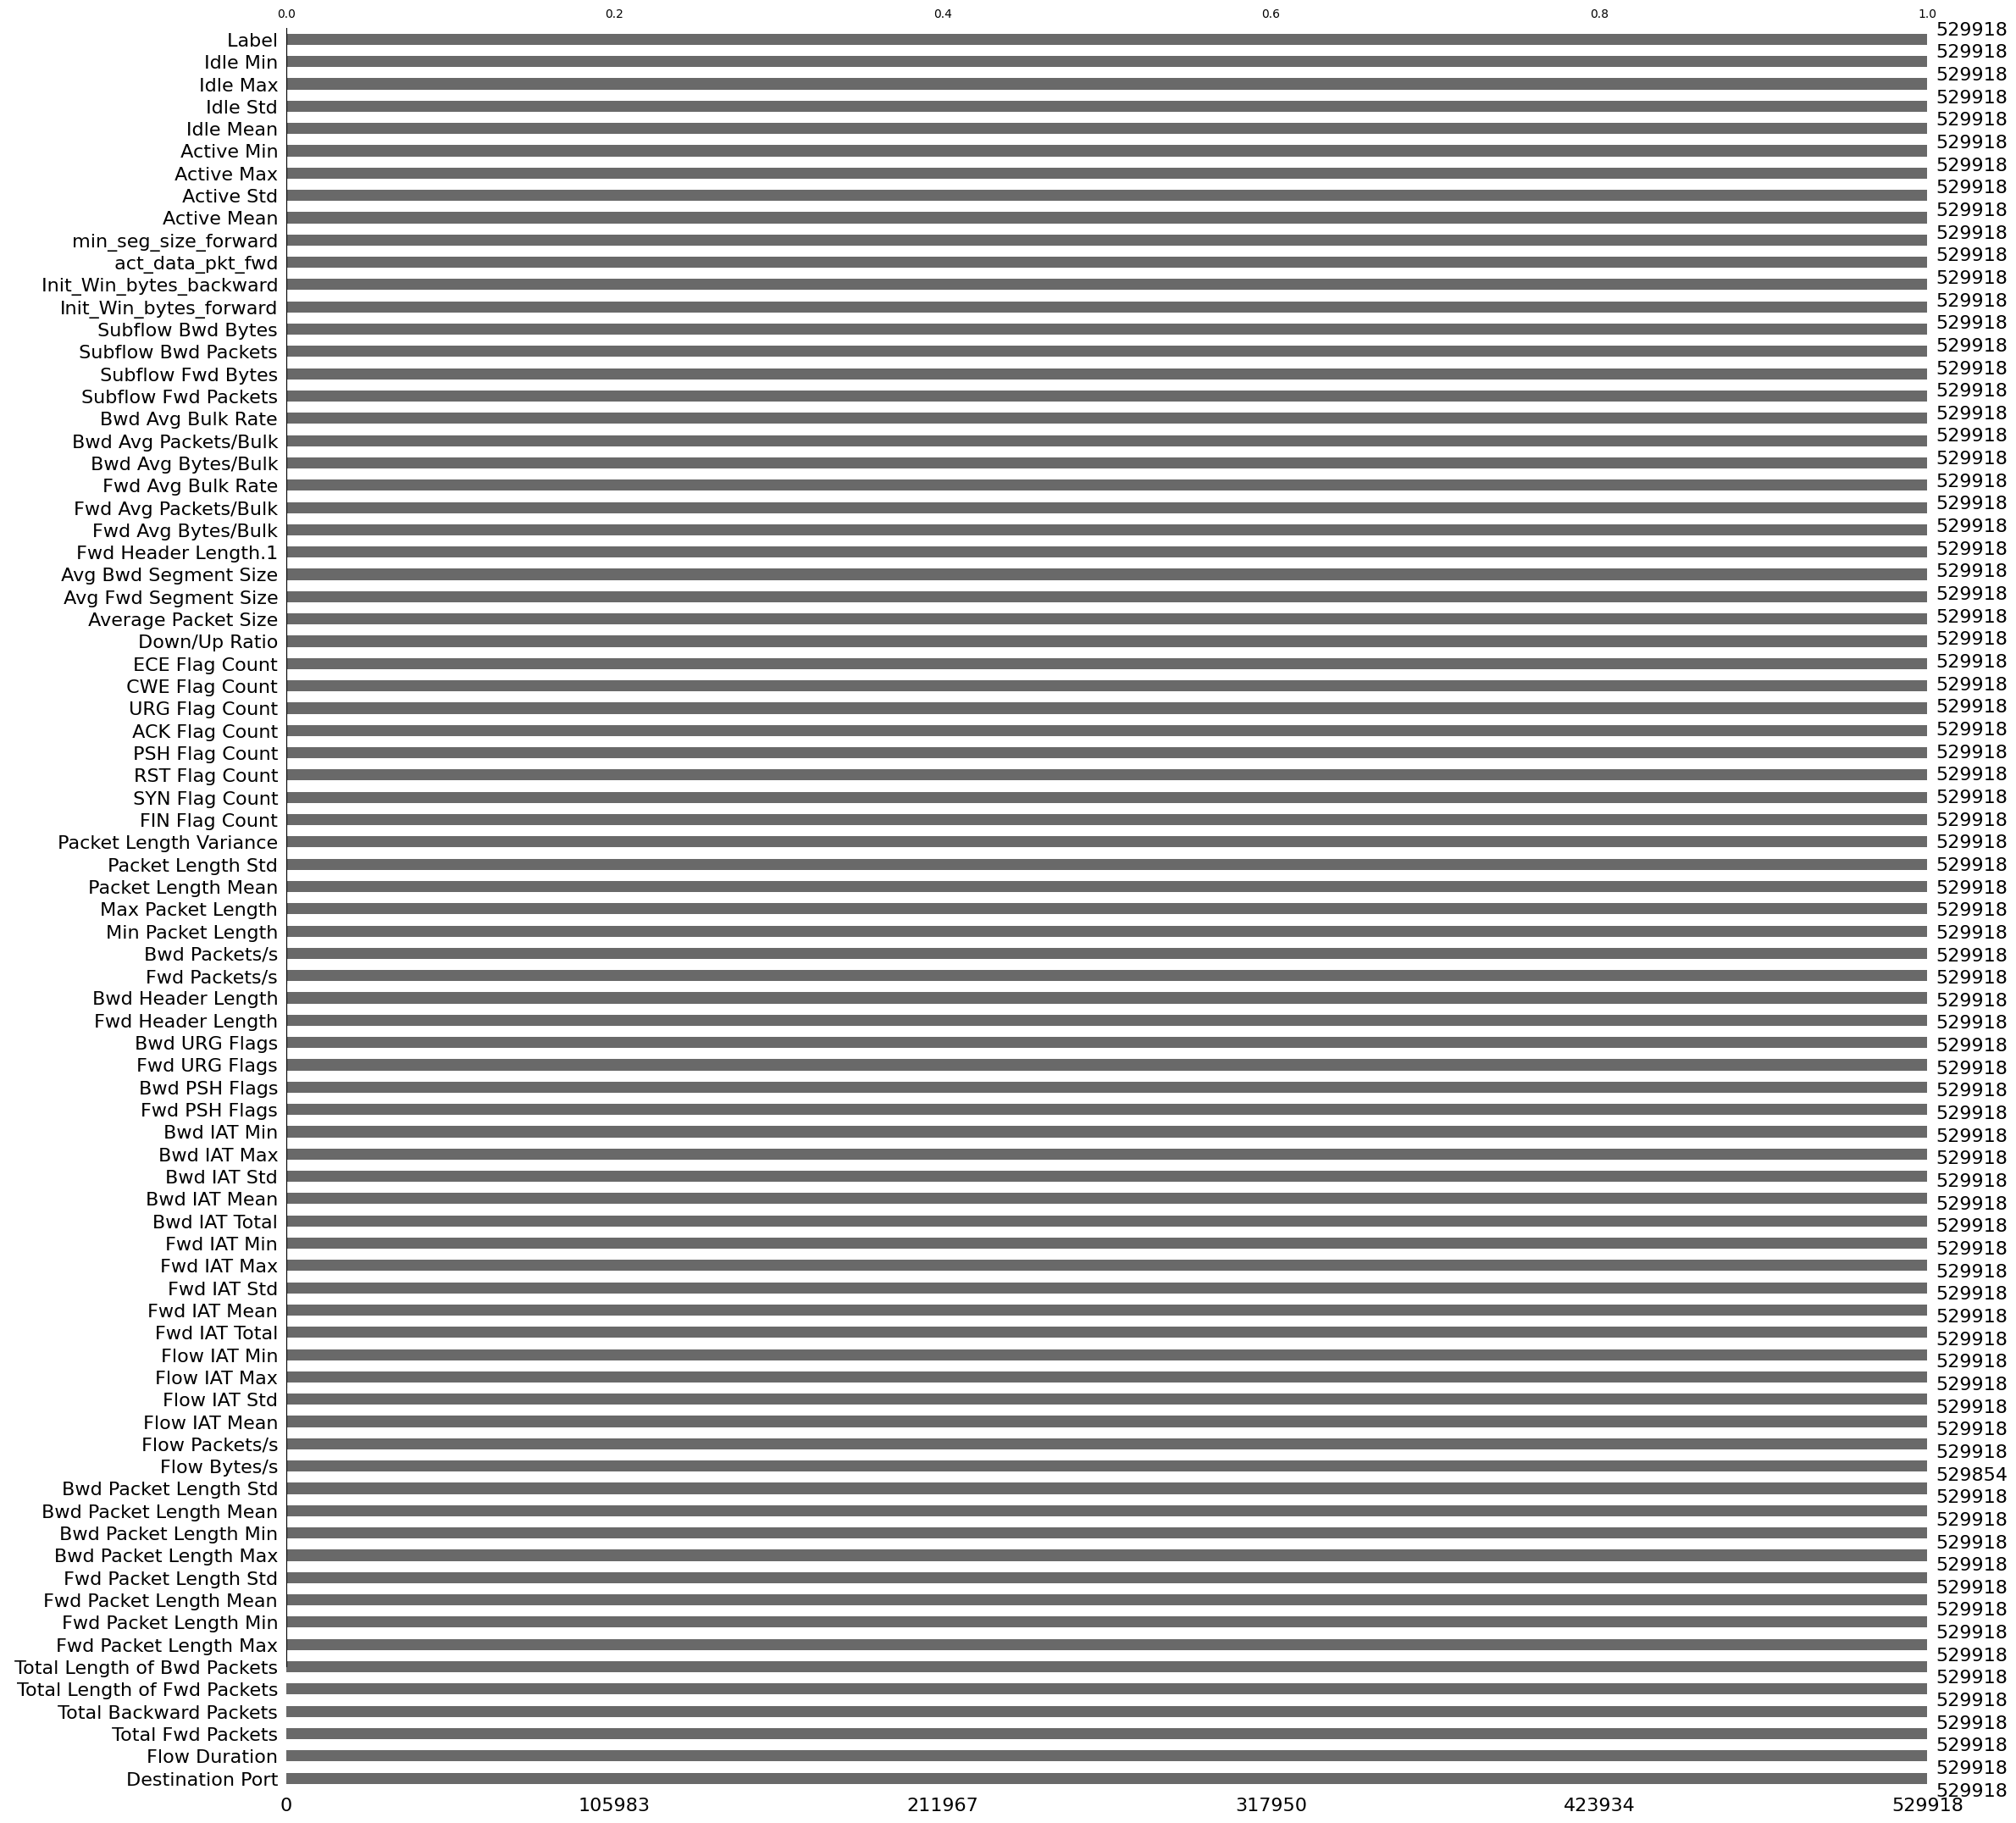

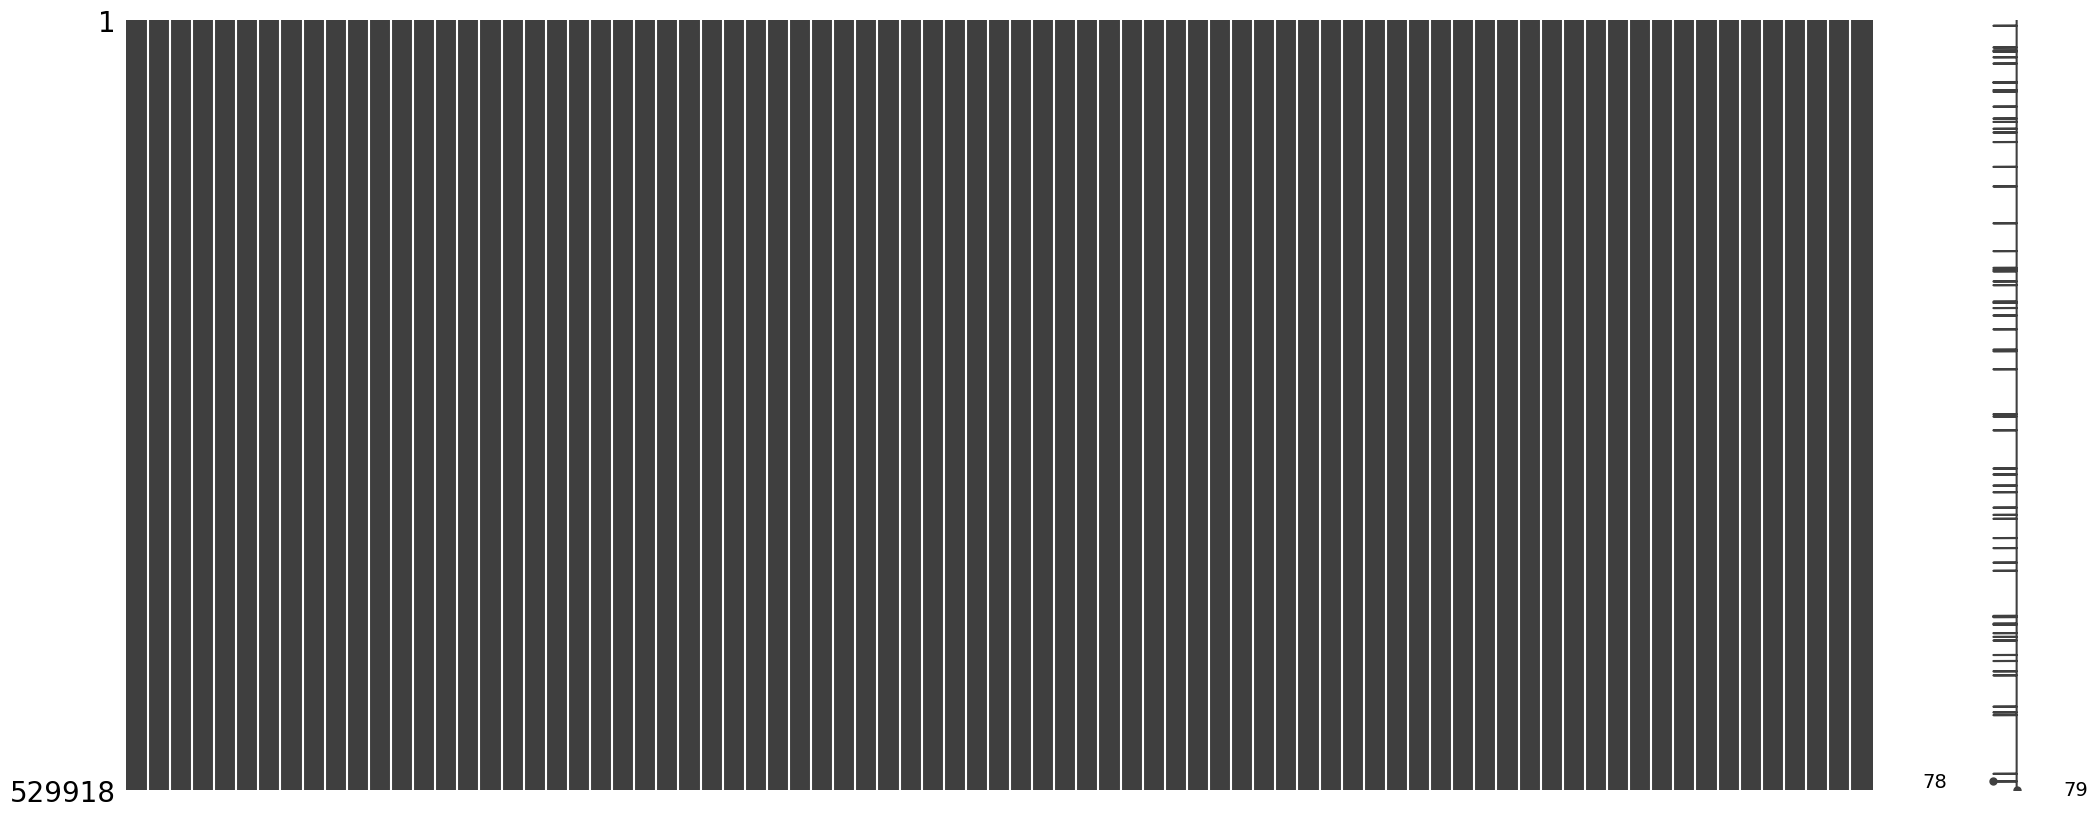

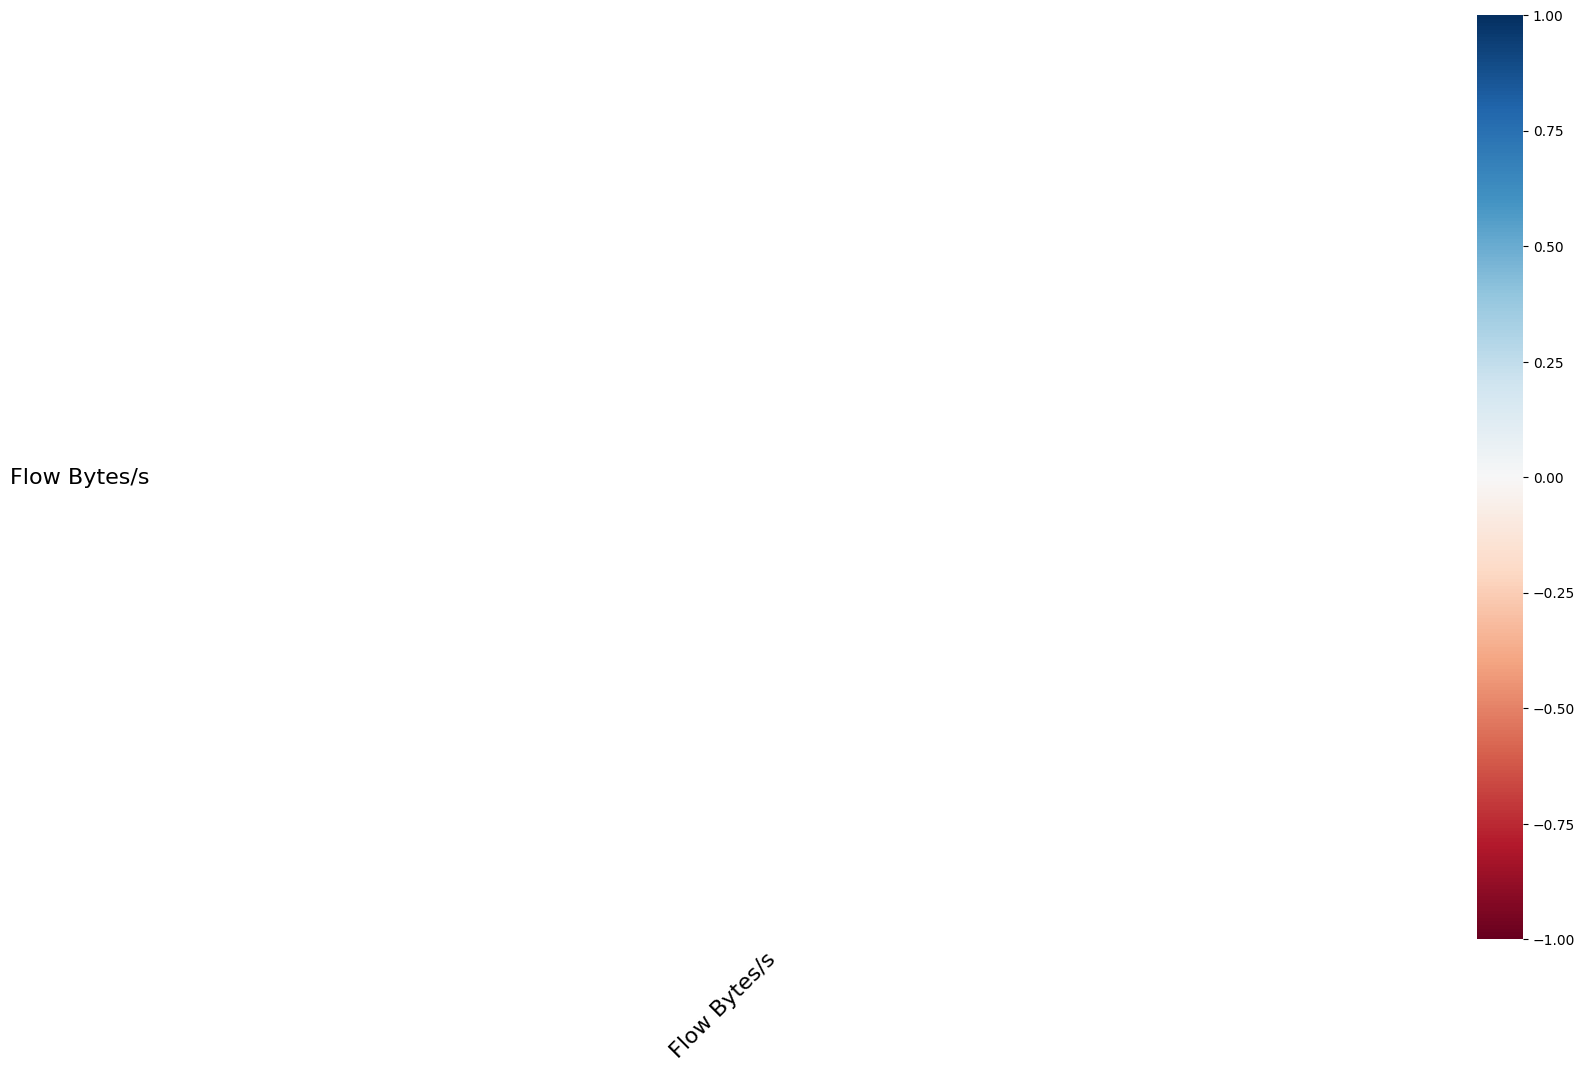

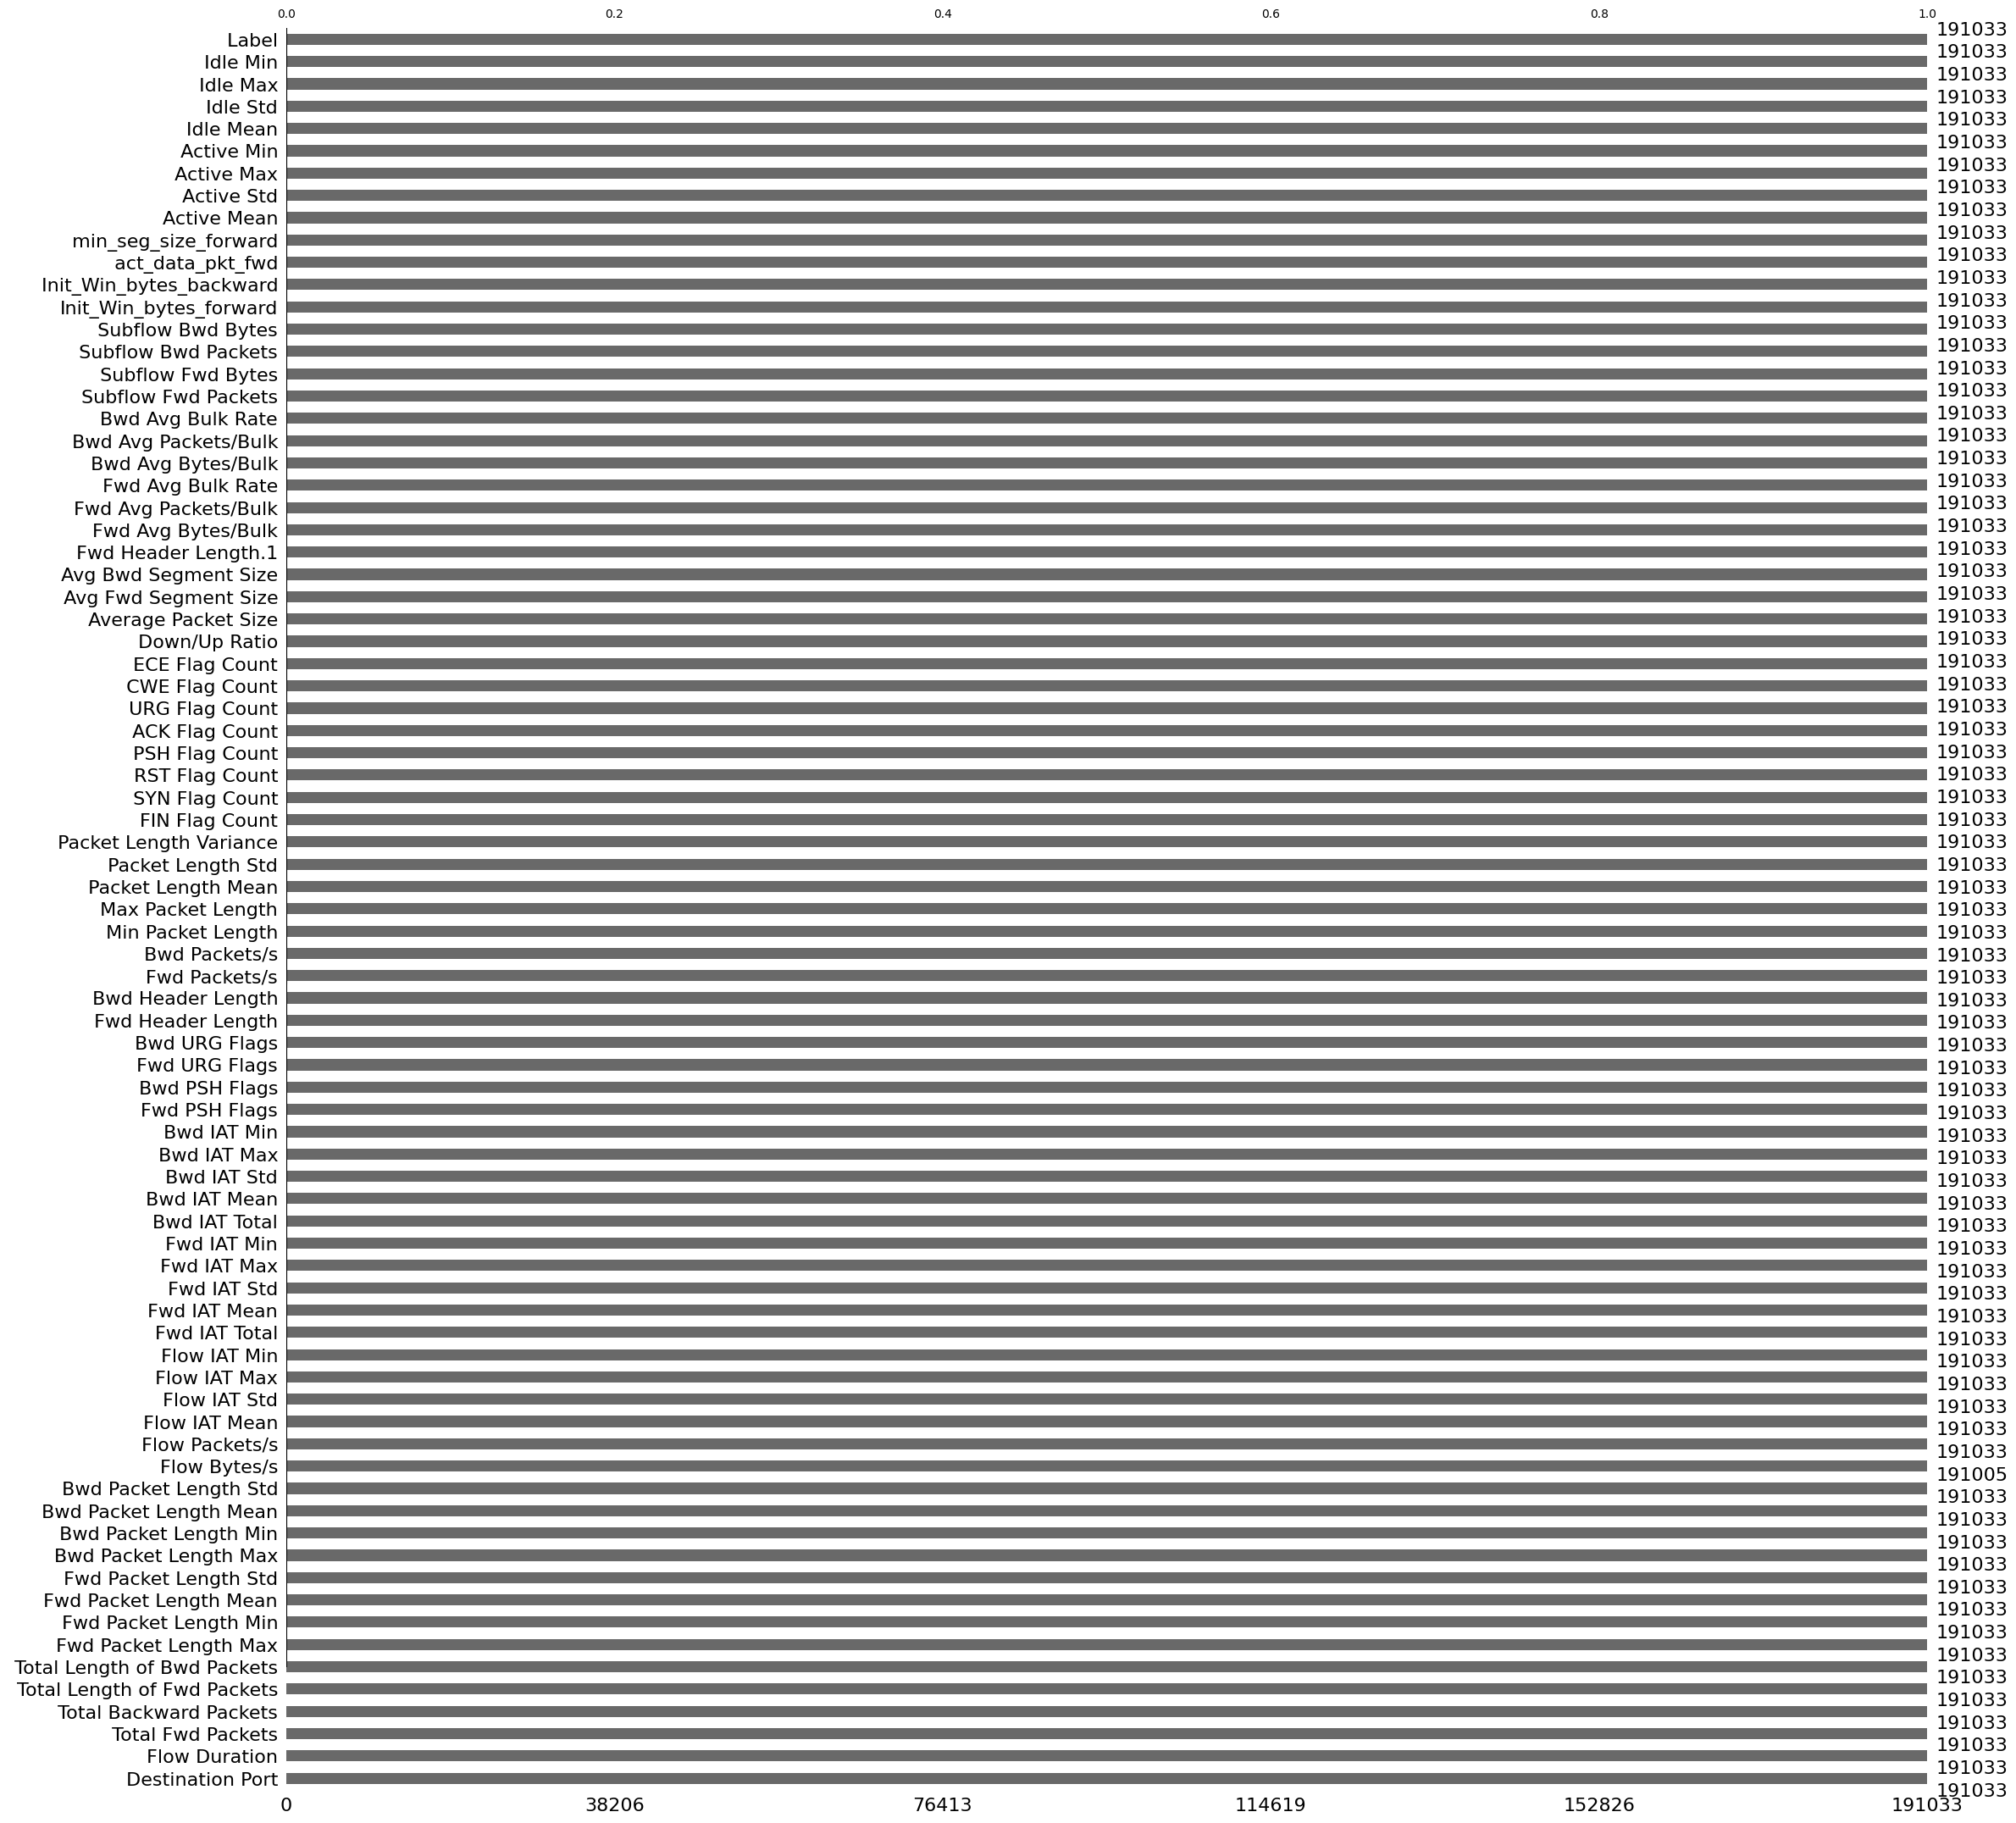

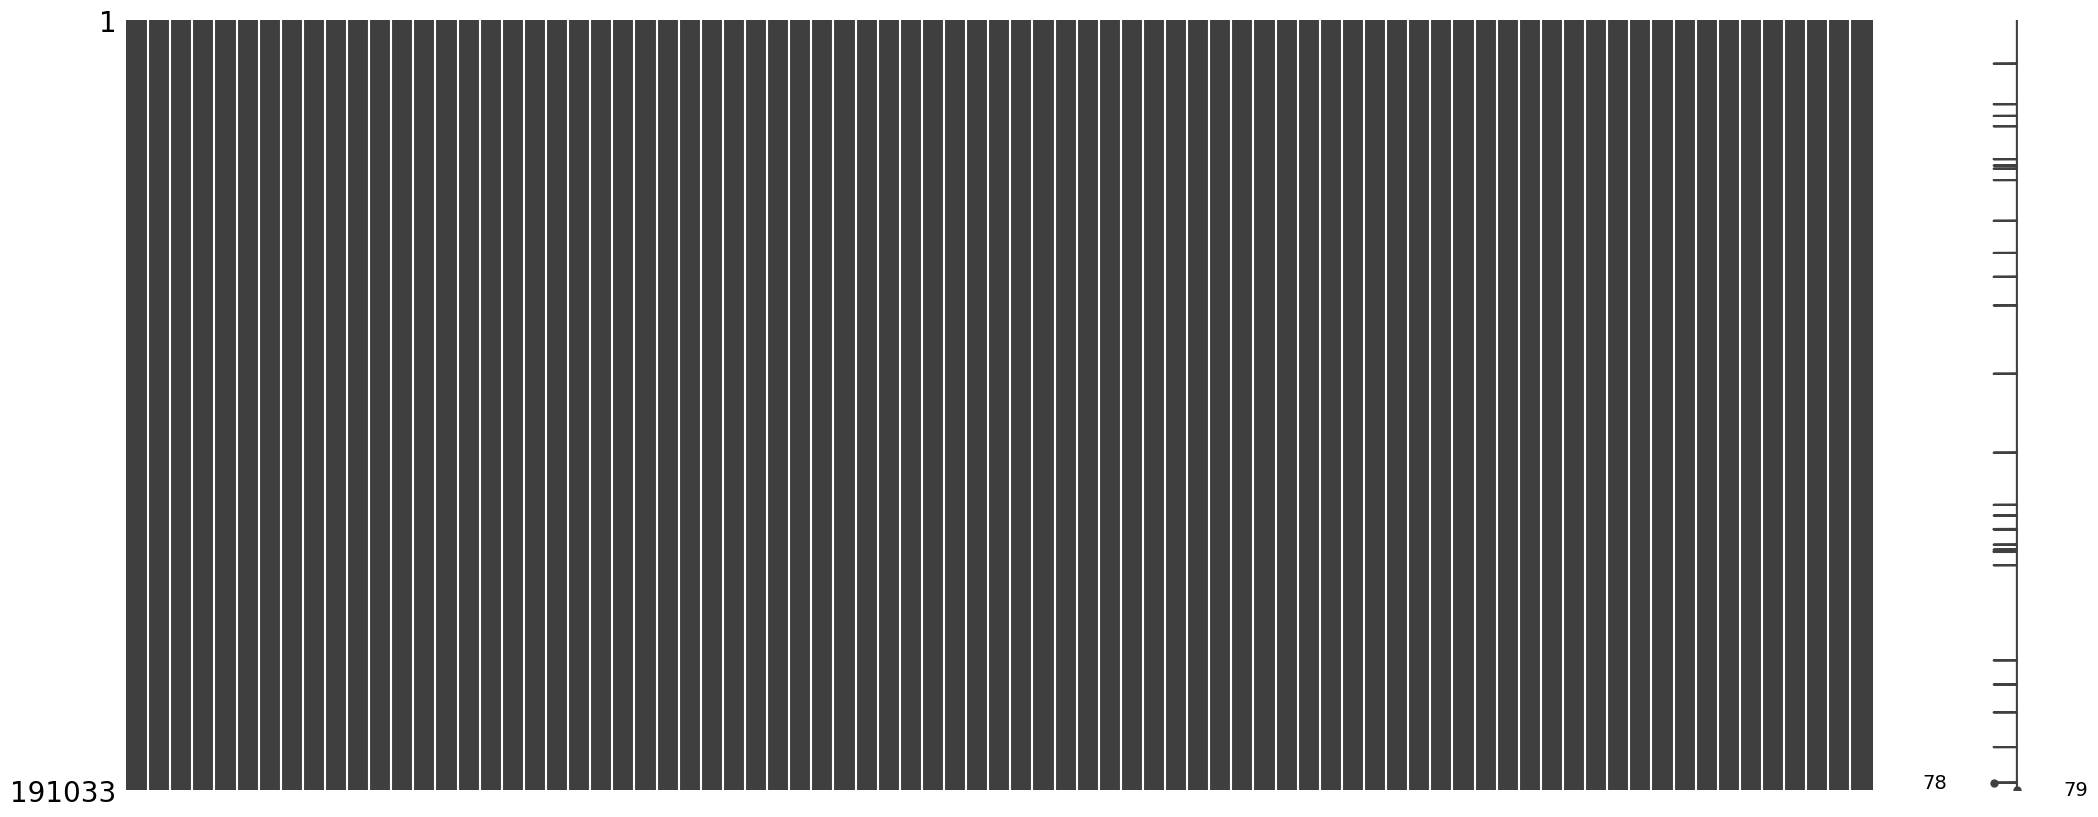

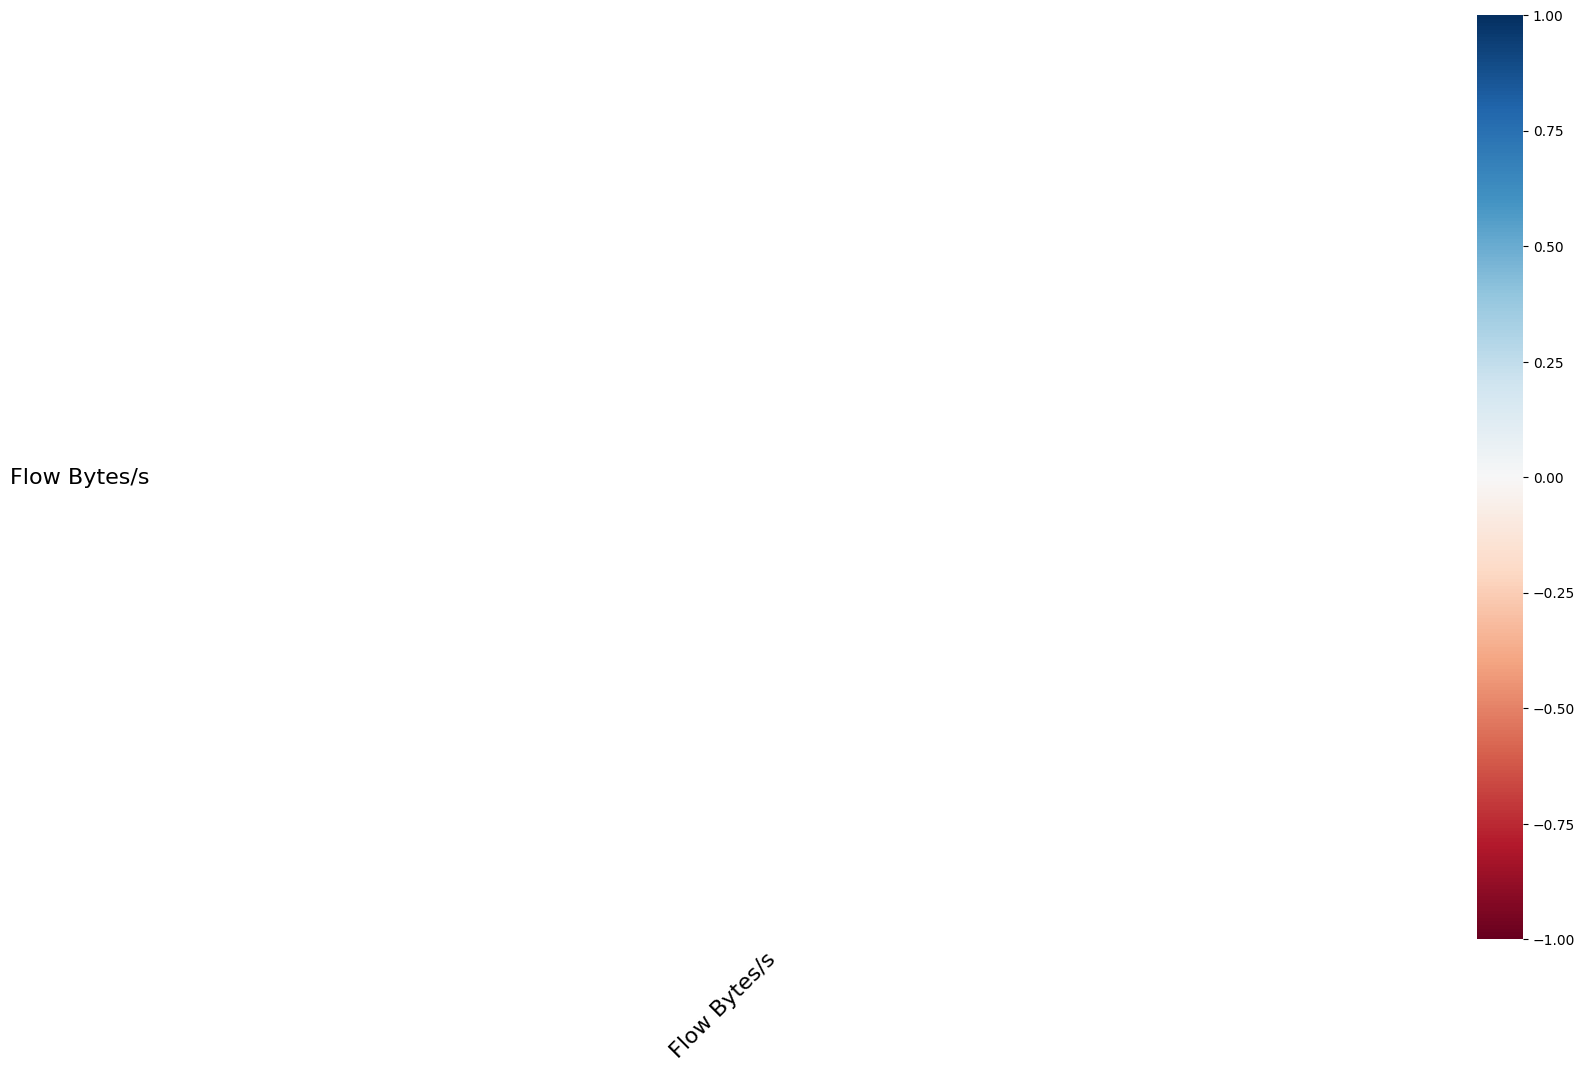

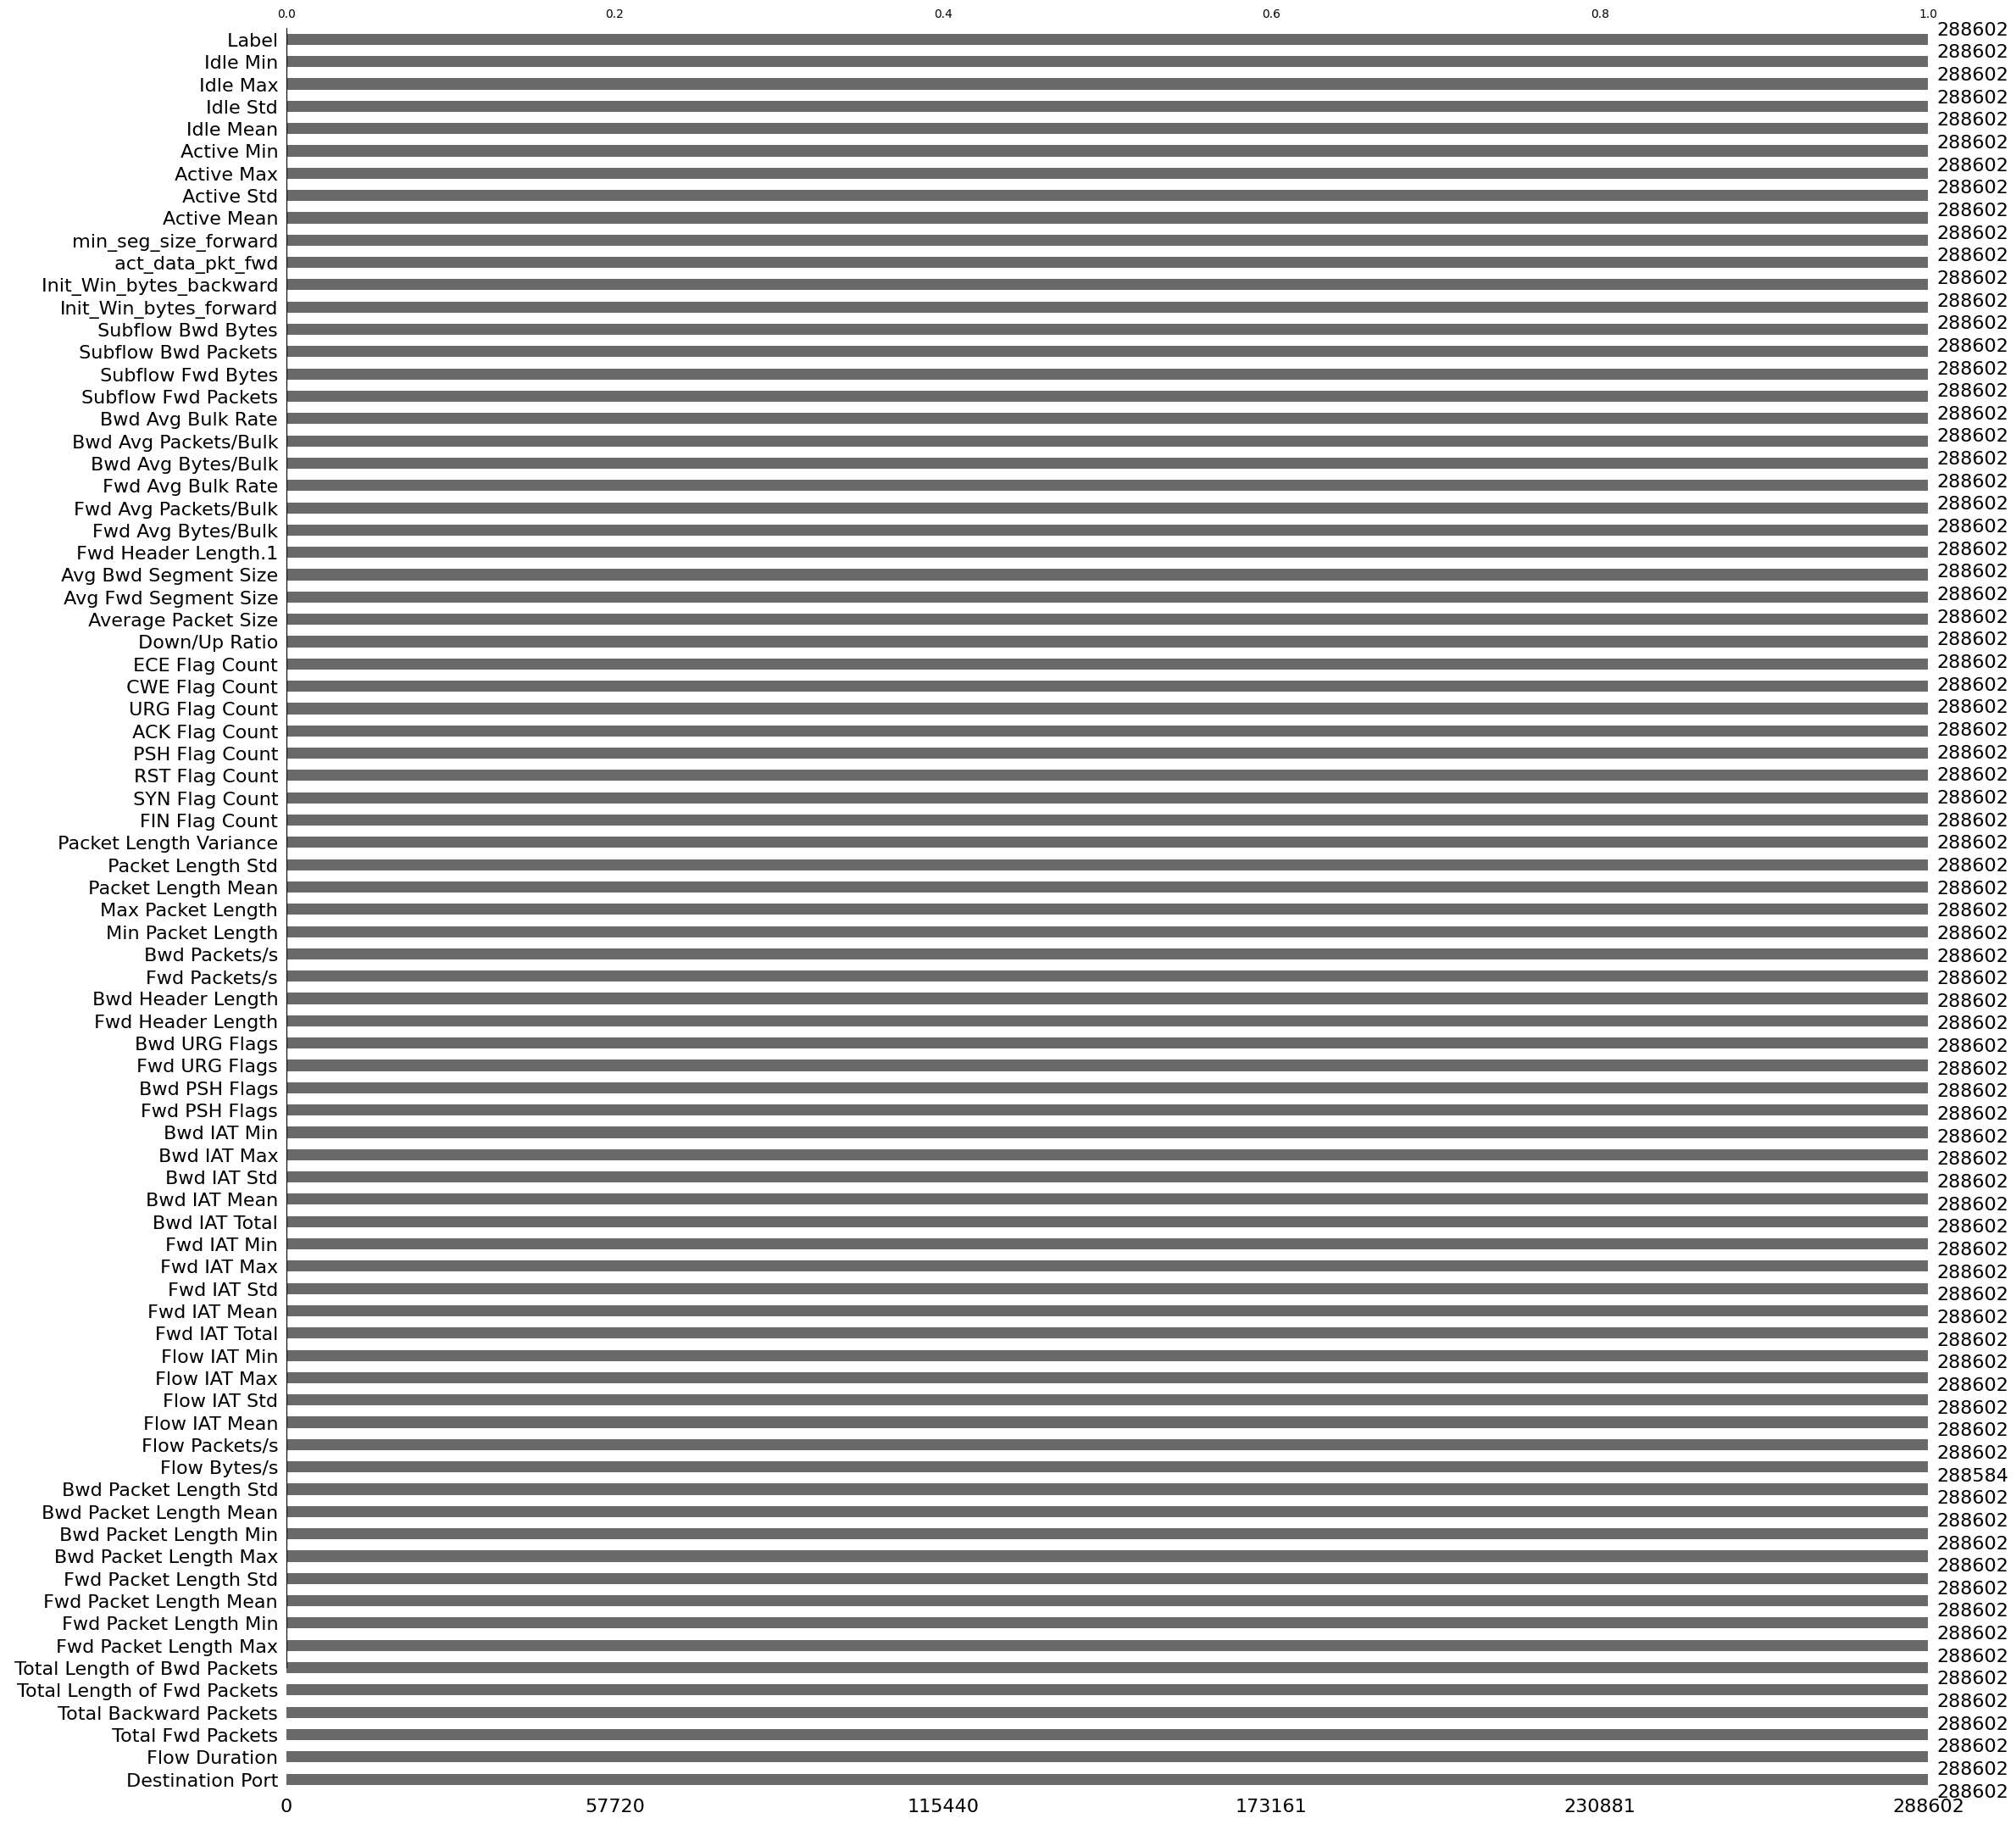

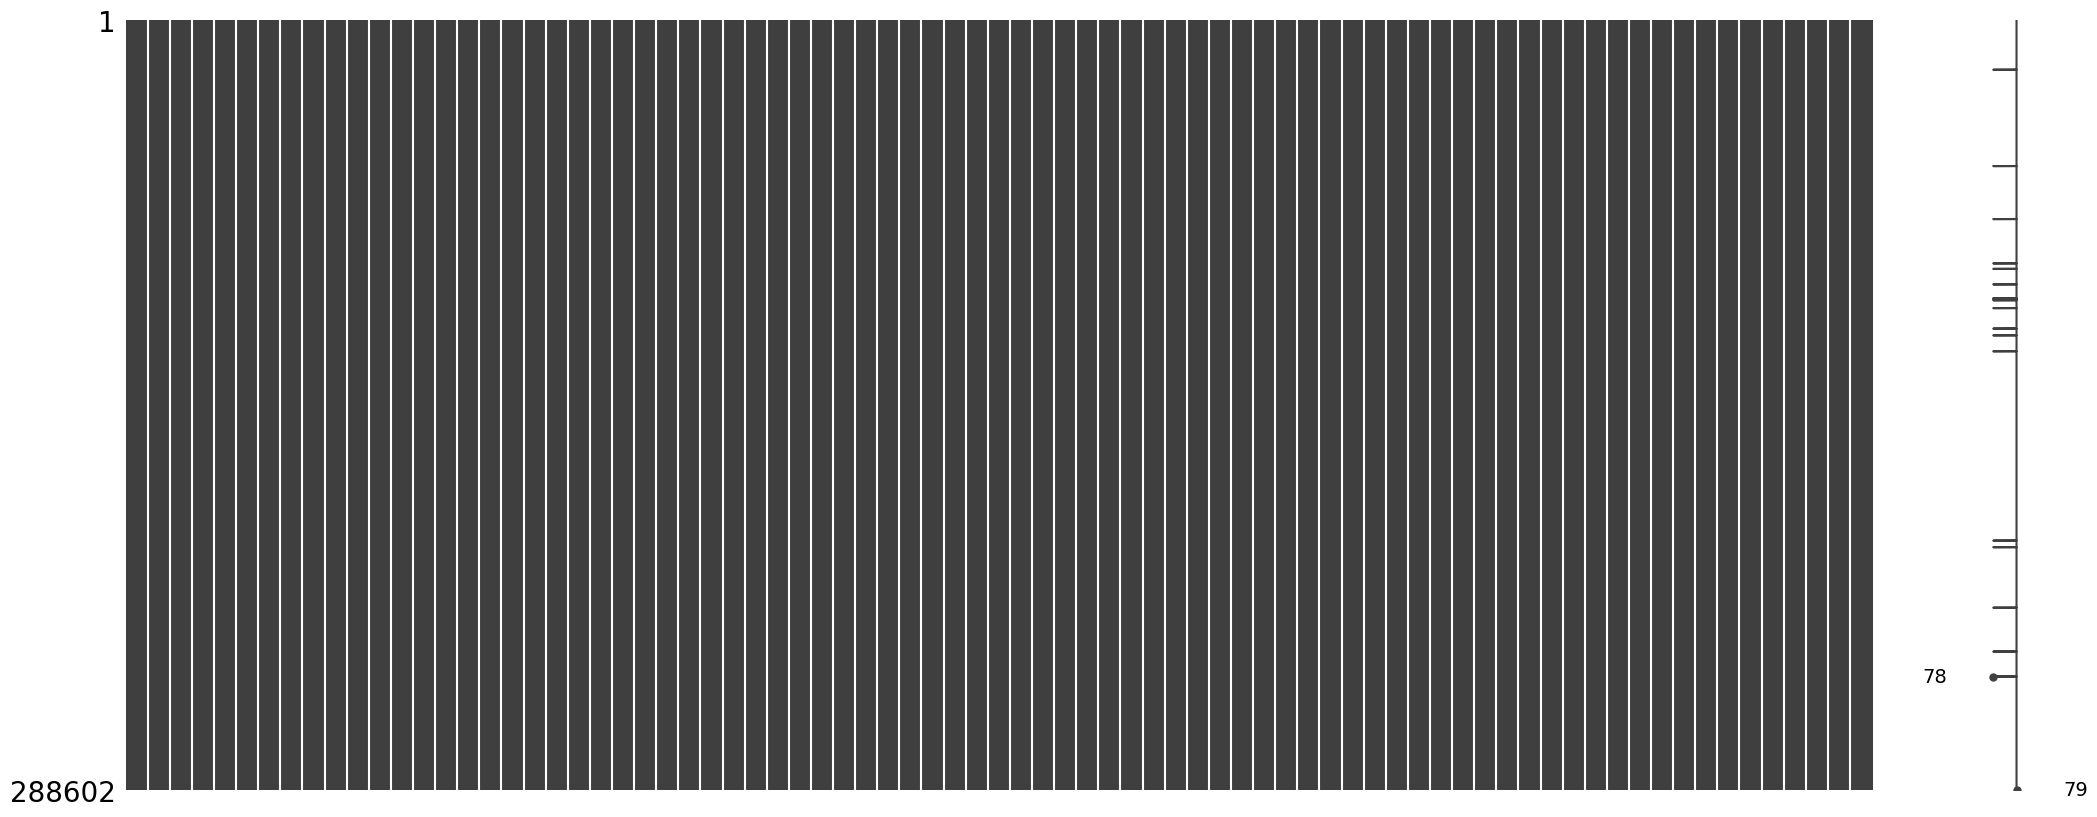

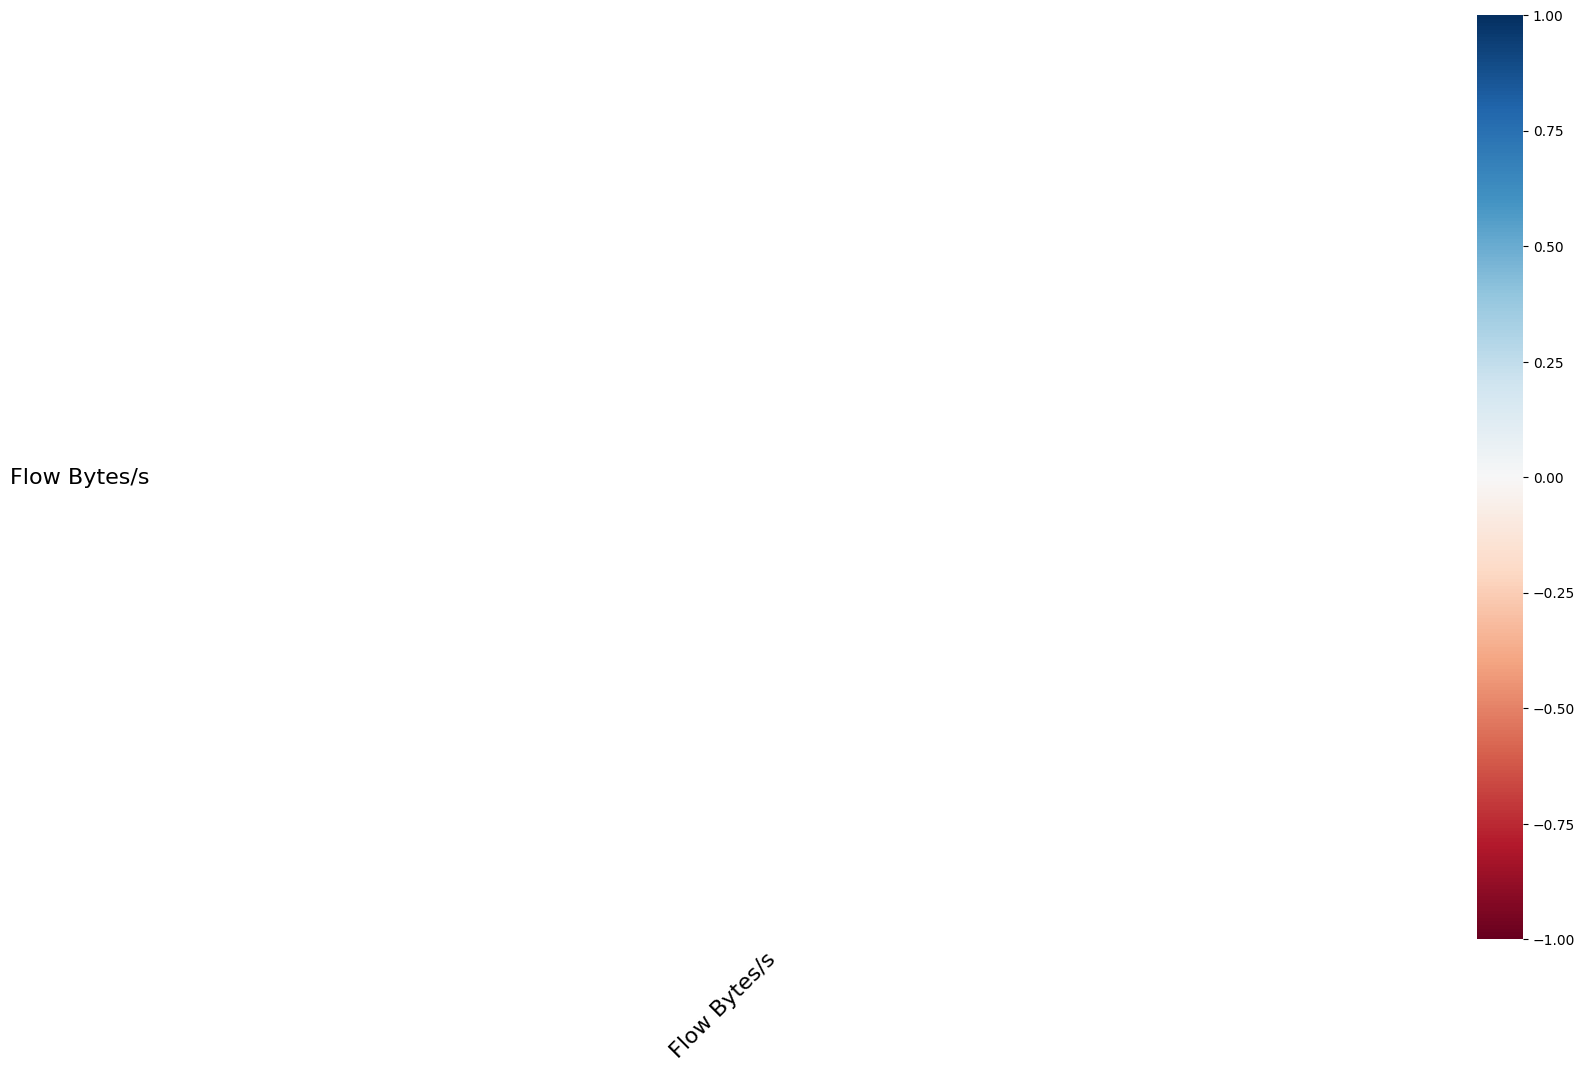

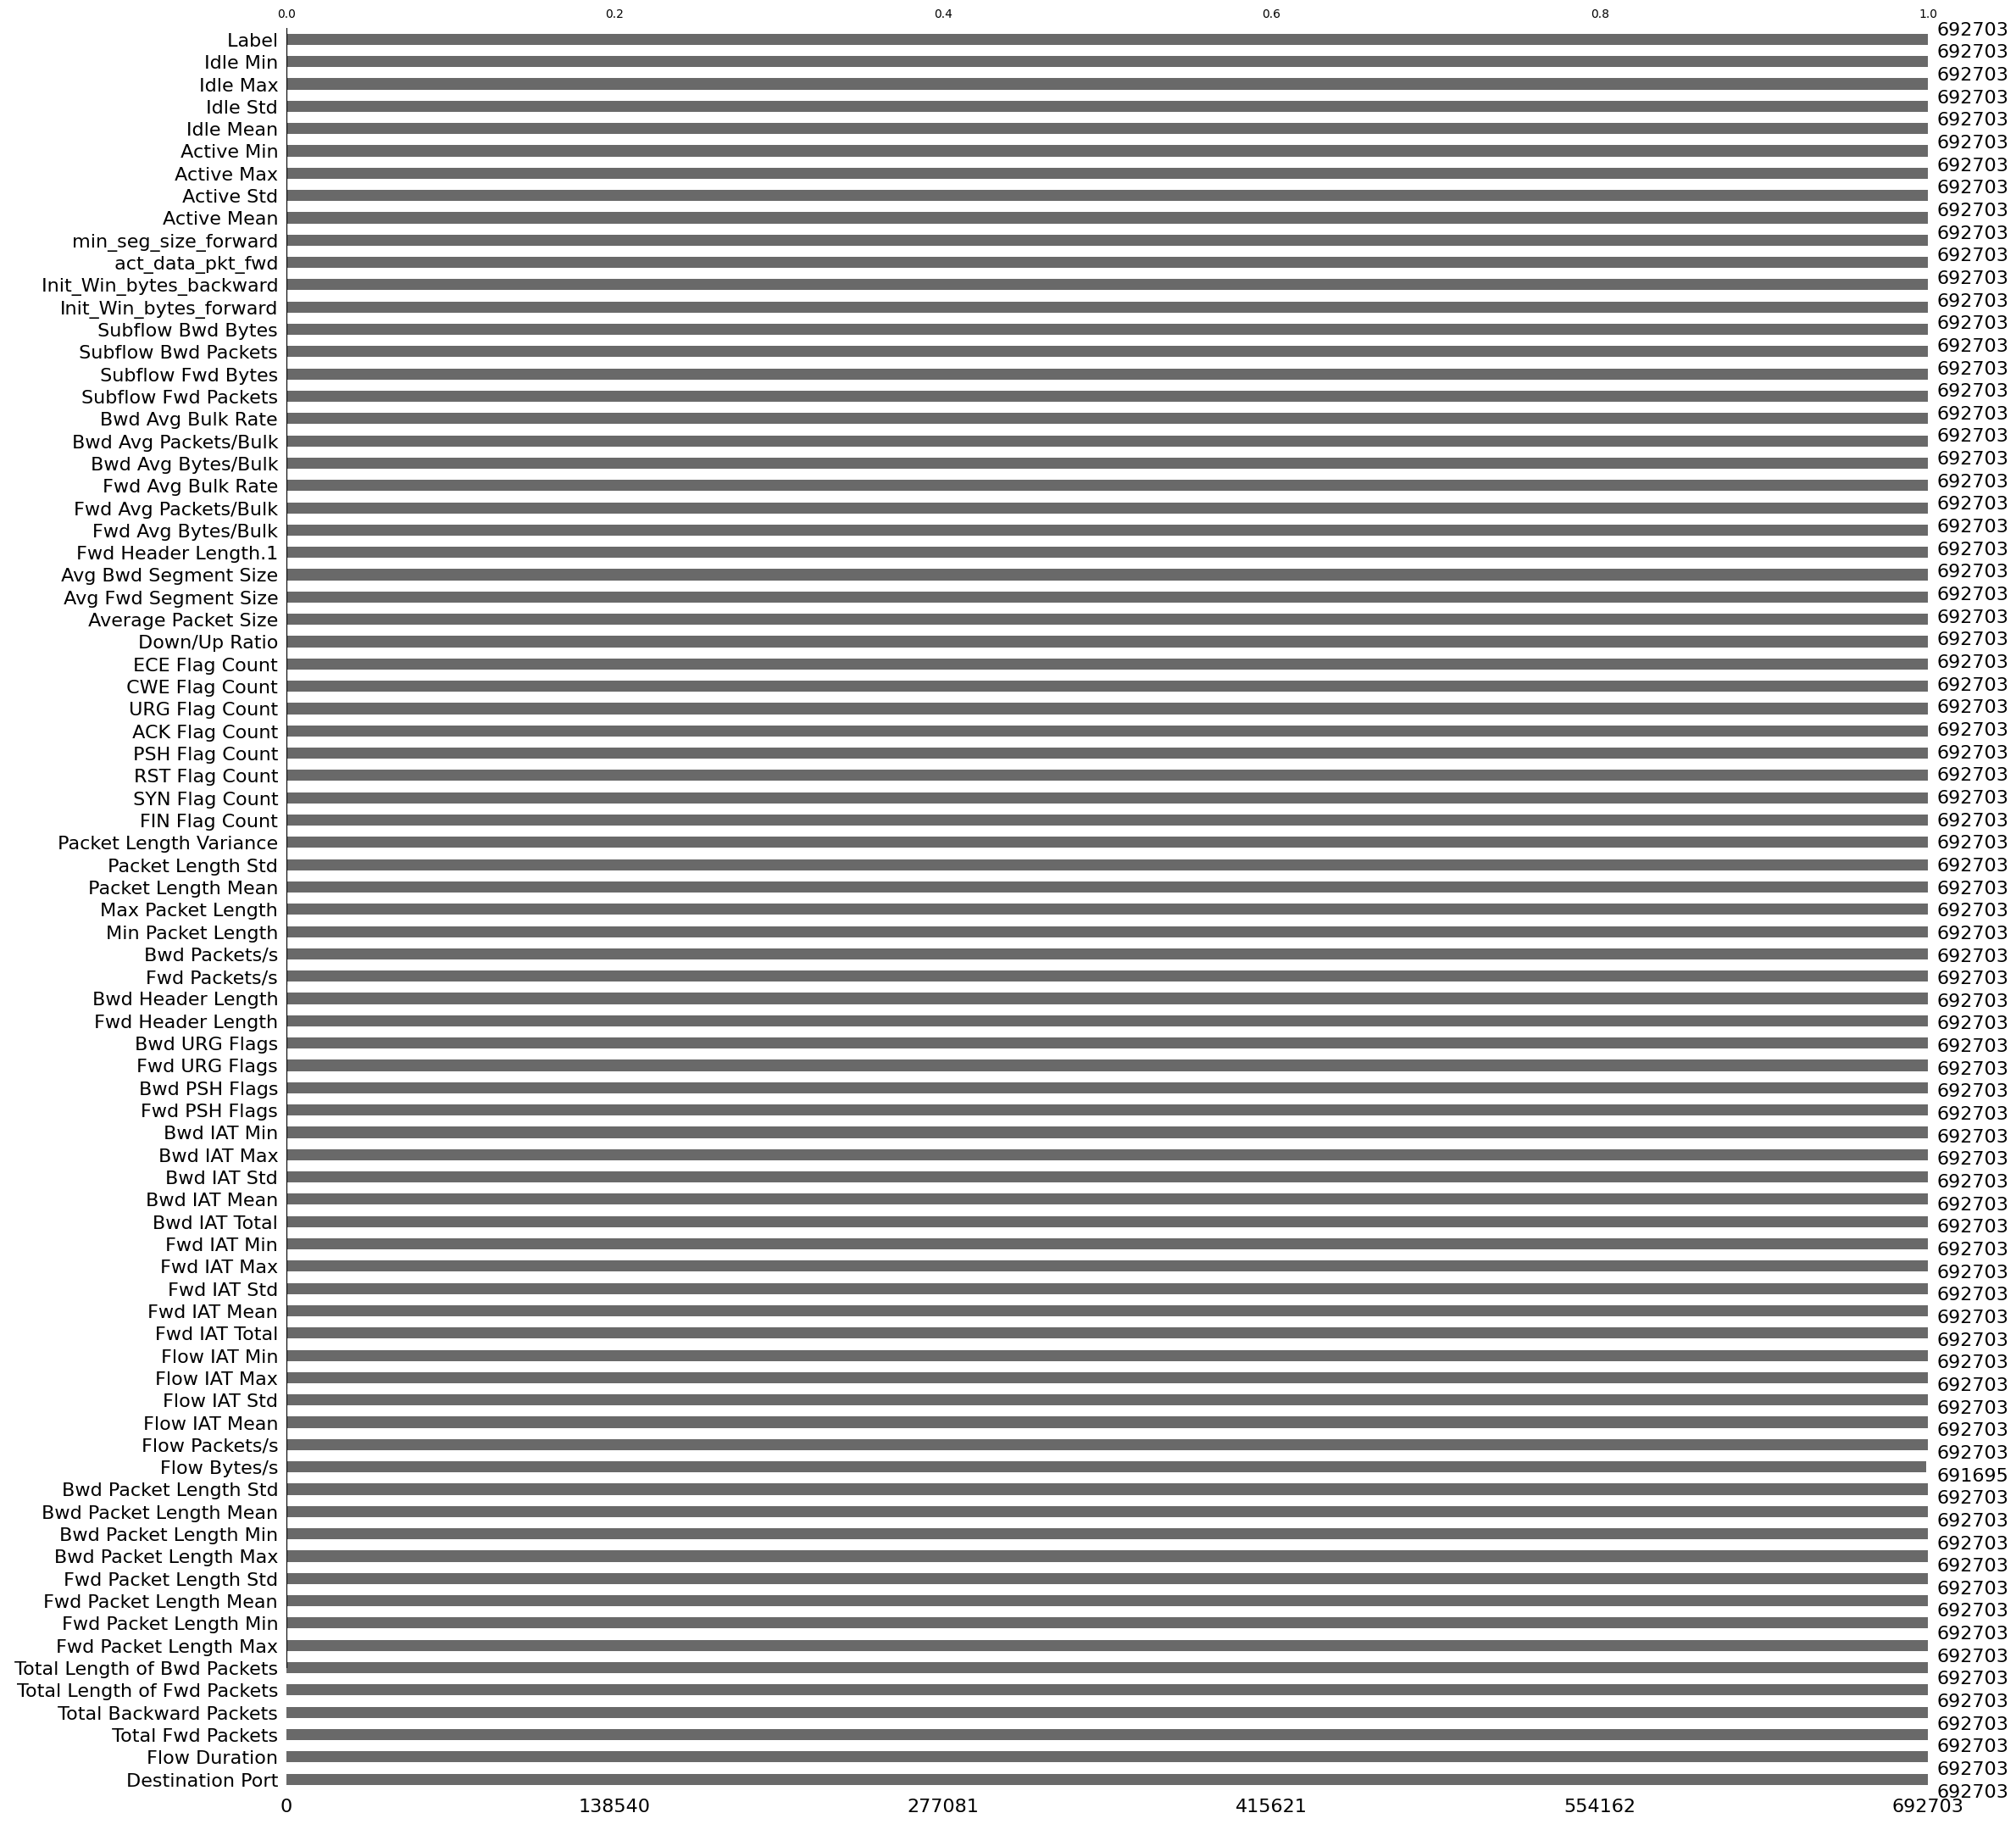

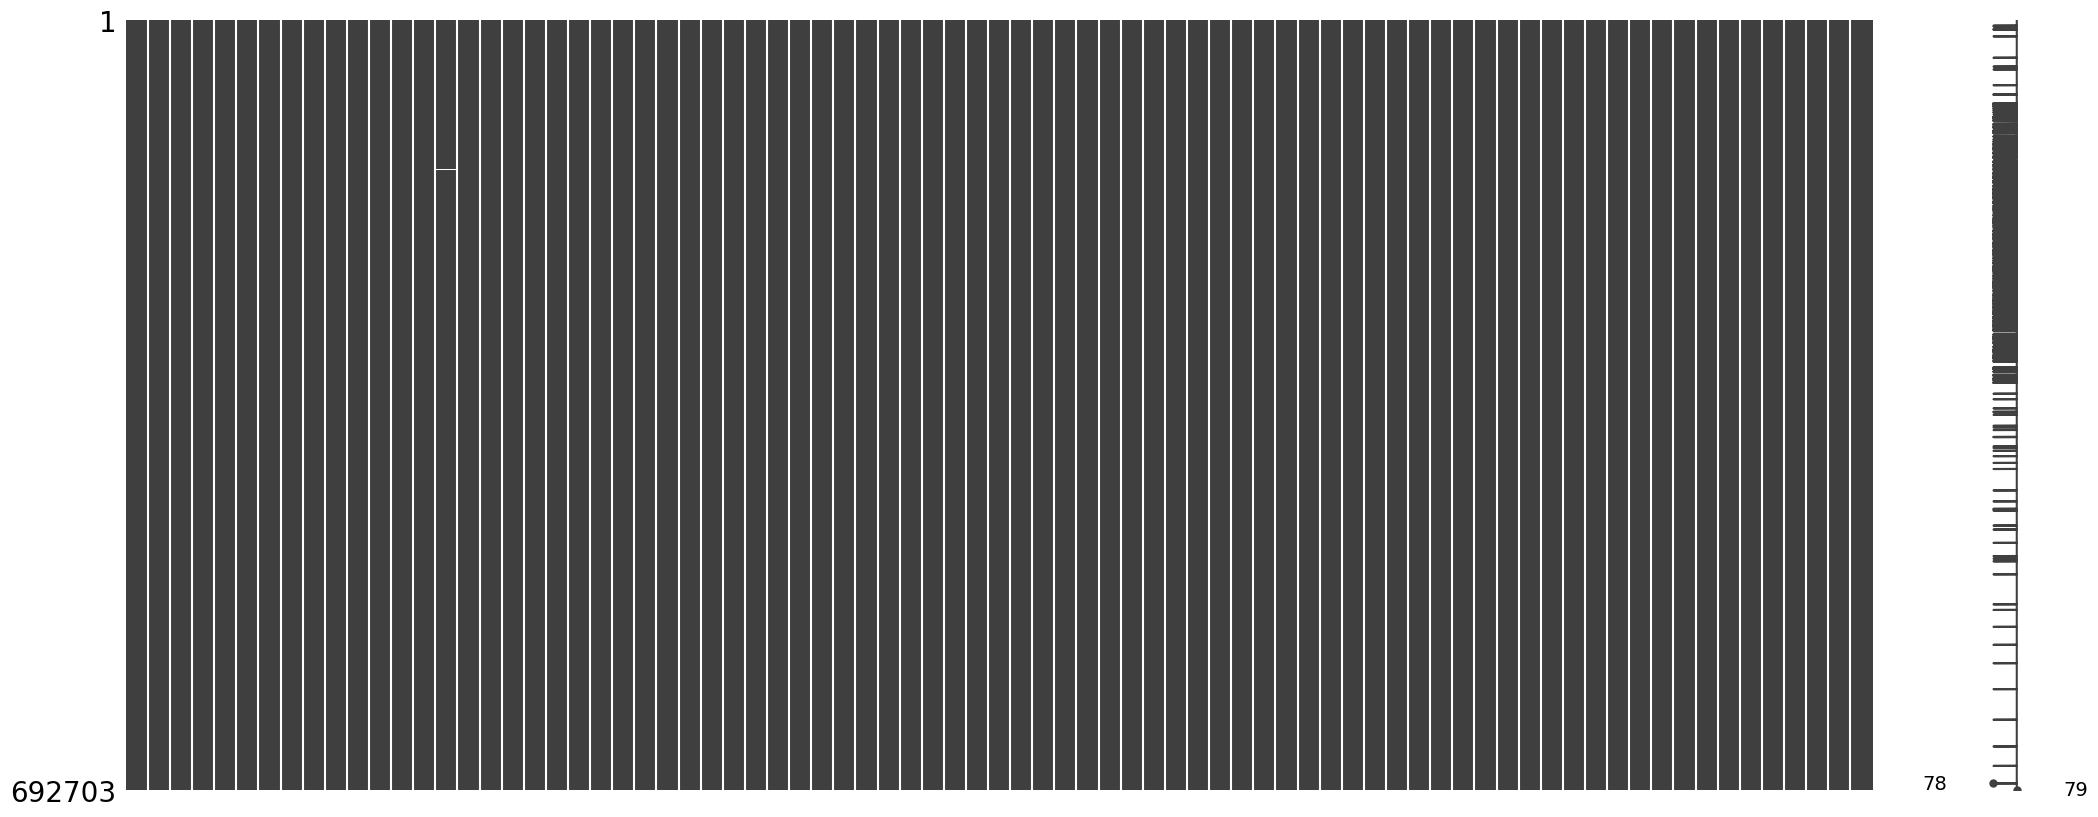

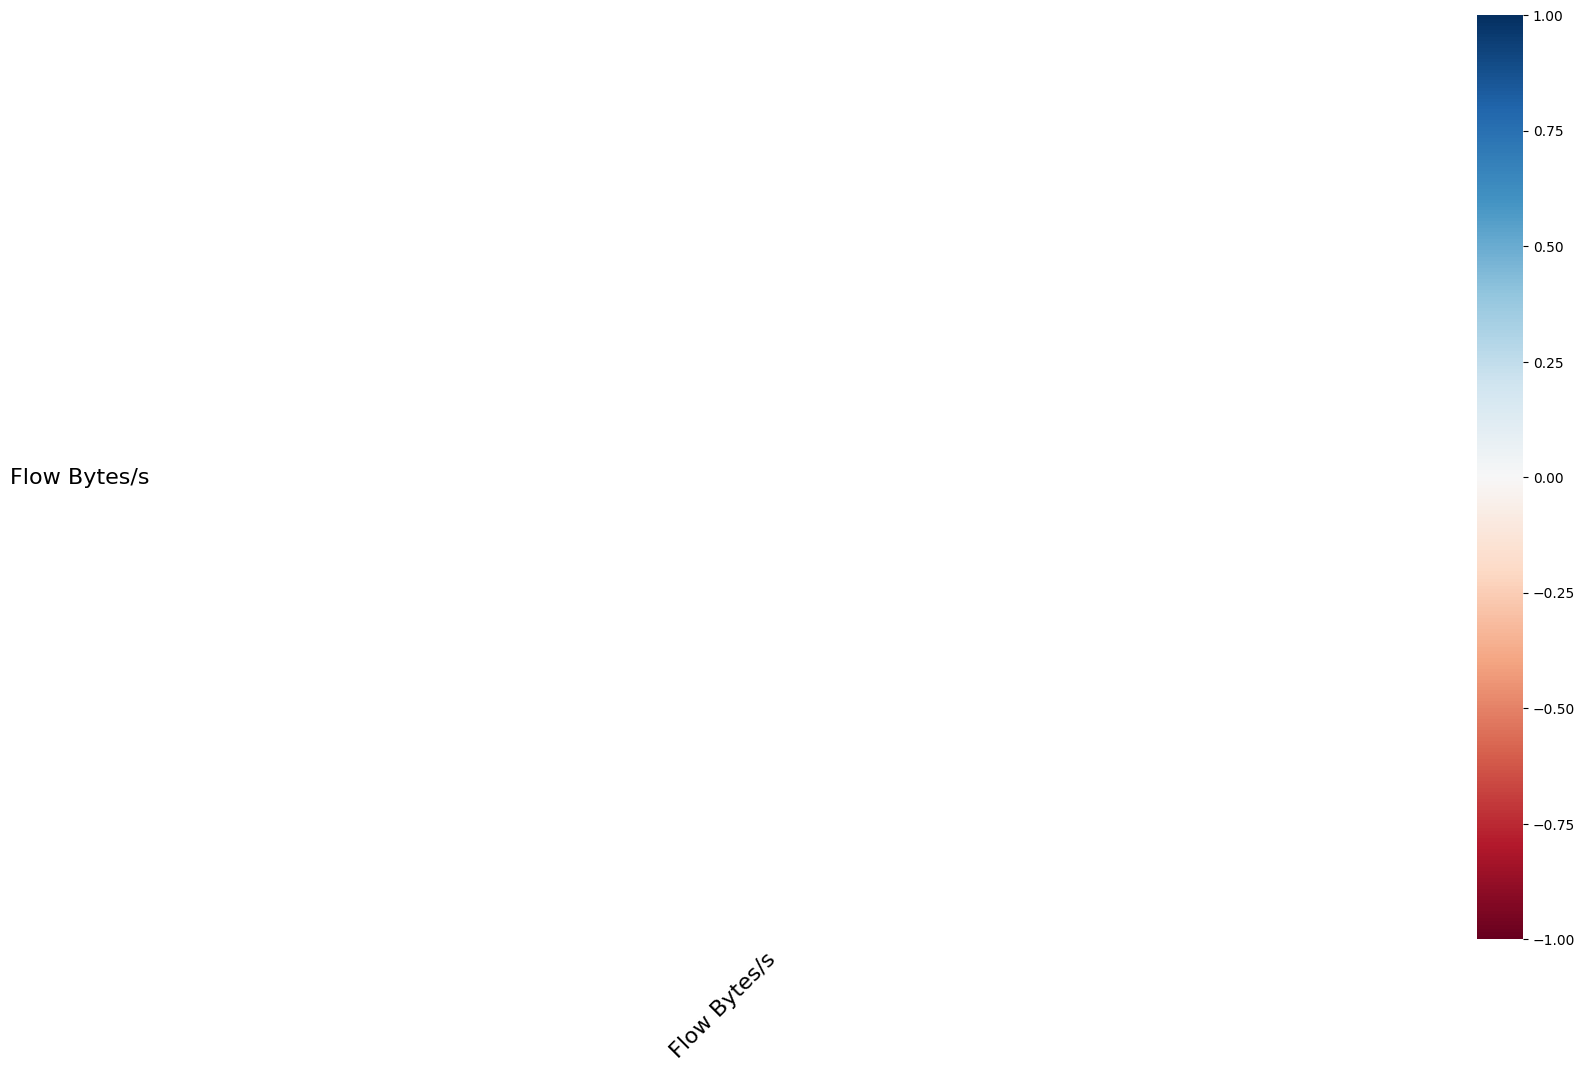

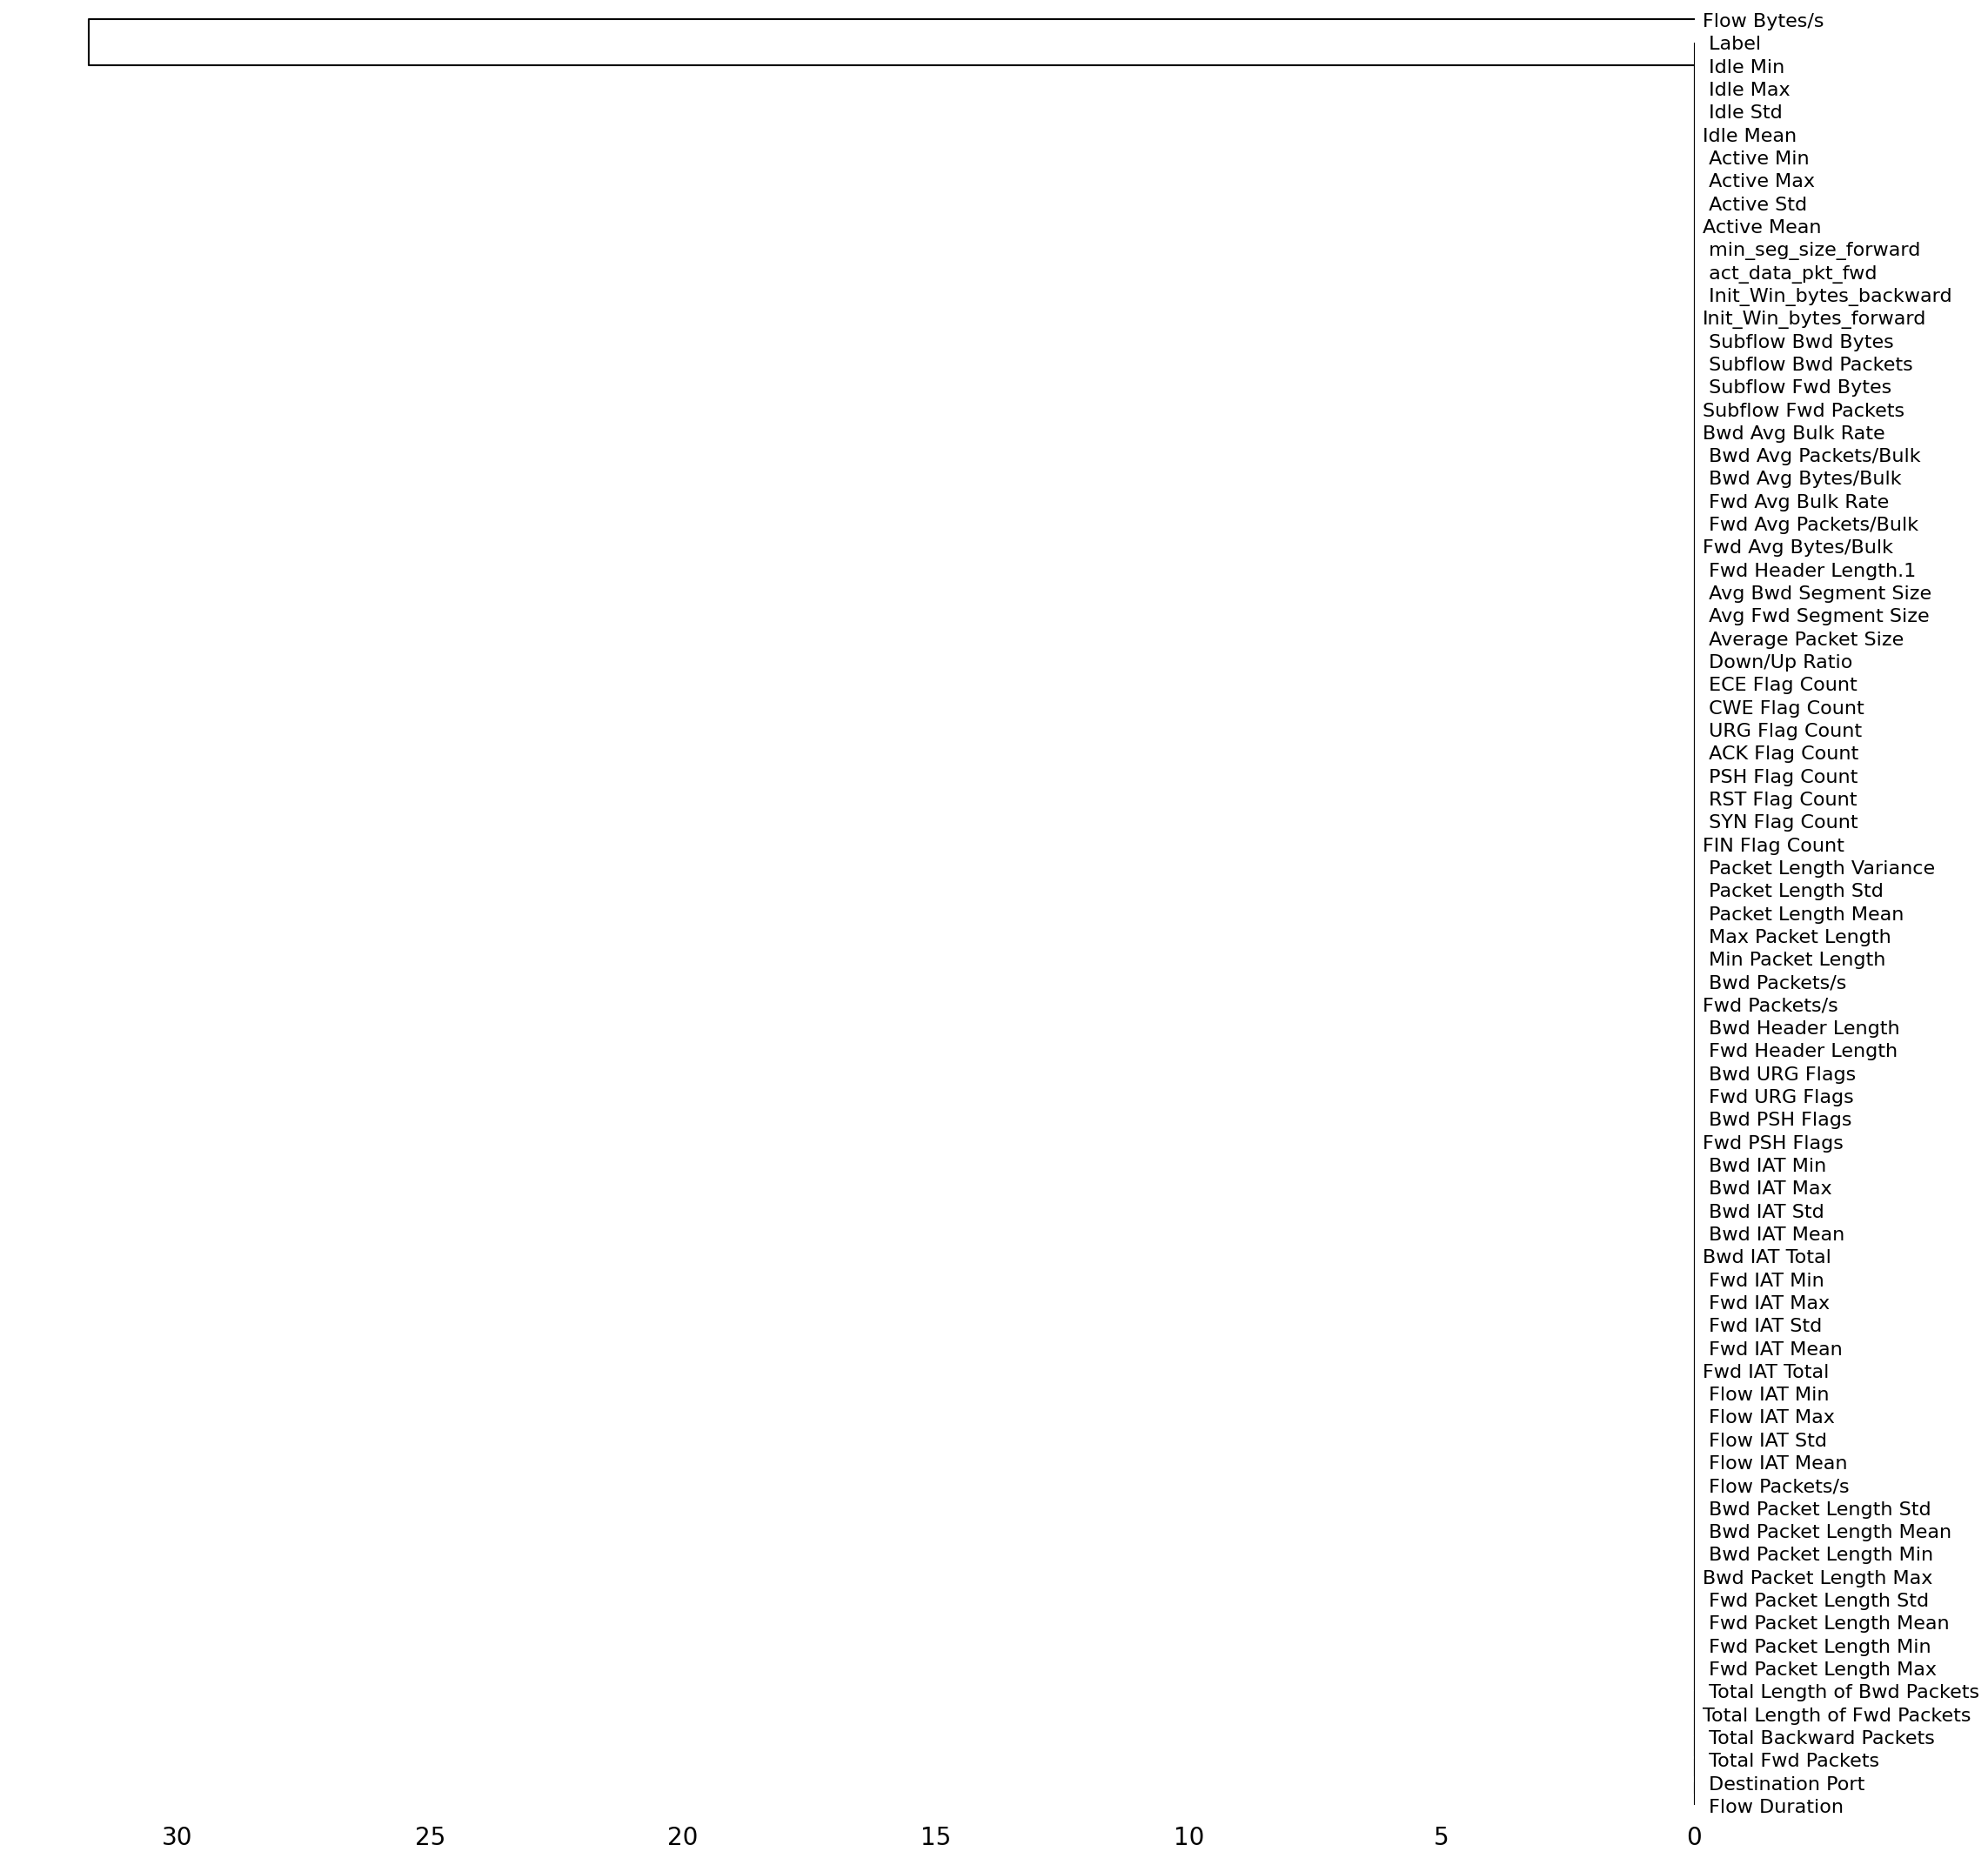

In [20]:
import missingno as msno

for df in data_frames:
    msno.bar(df)
    msno.matrix(df)
    msno.heatmap(df)
    msno.dendrogram(df)



------------------
0
count    2.864670e+05
mean     1.116307e+06
std      2.566649e+07
min     -1.930000e+08
25%      7.931367e+03
50%      1.250000e+05
75%      1.904762e+05
max      2.070000e+09
Name: Flow Bytes/s, dtype: float64


C:\Users\gurle\AppData\Local\Temp\ipykernel_16692\2813677666.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Flow Bytes/s"].replace([np.inf, -np.inf], np.nan, inplace=True)
C:\Users\gurle\AppData\Local\Temp\ipykernel_16692\2813677666.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves

------------------
------------------
0
count    1.703660e+05
mean     1.785807e+06
std      3.010930e+07
min     -2.610000e+08
25%      1.544569e+02
50%      4.826311e+03
75%      2.727273e+05
max      2.070000e+09
Name: Flow Bytes/s, dtype: float64
------------------
------------------
0


C:\Users\gurle\AppData\Local\Temp\ipykernel_16692\2813677666.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Flow Bytes/s"].replace([np.inf, -np.inf], np.nan, inplace=True)
C:\Users\gurle\AppData\Local\Temp\ipykernel_16692\2813677666.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves

count    4.459090e+05
mean     1.381378e+06
std      2.322219e+07
min      0.000000e+00
25%      1.155355e+00
50%      2.475951e+03
75%      2.795609e+04
max      2.070000e+09
Name: Flow Bytes/s, dtype: float64
------------------
------------------
0
count    2.257450e+05
mean     5.853059e+05
std      1.688425e+07
min     -1.200000e+07
25%      1.209100e+01
50%      1.133466e+03
75%      2.156556e+04
max      2.070000e+09
Name: Flow Bytes/s, dtype: float64
------------------
------------------


...

0
count    5.299180e+05
mean     1.611941e+06
std      2.461755e+07
min     -1.200000e+07
25%      1.706606e+02
50%      5.556257e+03
75%      2.352941e+05
max      2.071000e+09
Name: Flow Bytes/s, dtype: float64
------------------
------------------
0


C:\Users\gurle\AppData\Local\Temp\ipykernel_16692\2813677666.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Flow Bytes/s"].replace([np.inf, -np.inf], np.nan, inplace=True)
C:\Users\gurle\AppData\Local\Temp\ipykernel_16692\2813677666.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves

count    1.910330e+05
mean     1.769952e+06
std      2.463267e+07
min     -1.200000e+07
25%      3.060418e+02
50%      5.712359e+03
75%      3.681917e+05
max      2.070000e+09
Name: Flow Bytes/s, dtype: float64
------------------
------------------
0
count    2.886020e+05
mean     1.587658e+06
std      2.704478e+07
min     -1.200000e+07
25%      8.465443e+02
50%      1.930404e+04
75%      3.370787e+05
max      2.070000e+09
Name: Flow Bytes/s, dtype: float64
------------------
------------------


C:\Users\gurle\AppData\Local\Temp\ipykernel_16692\2813677666.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Flow Bytes/s"].replace([np.inf, -np.inf], np.nan, inplace=True)
C:\Users\gurle\AppData\Local\Temp\ipykernel_16692\2813677666.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves

0
count    6.927030e+05
mean     1.726296e+06
std      2.958799e+07
min     -1.200000e+07
25%      1.029546e+02
50%      5.155100e+02
75%      1.841752e+04
max      2.070000e+09
Name: Flow Bytes/s, dtype: float64
------------------


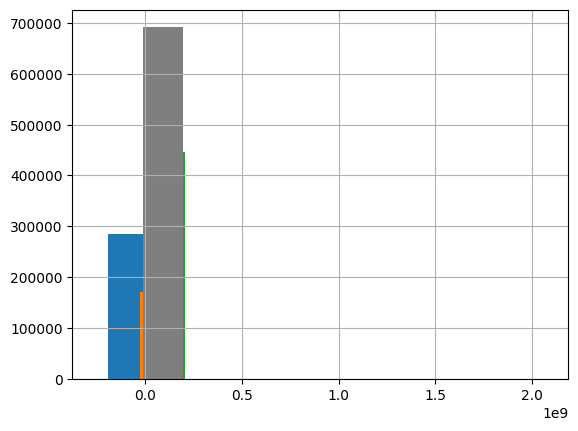

In [54]:
for df in data_frames:
    print('------------------')
    # print(df["Flow Bytes/s"].describe())  # Summary statistics
    # print(df["Flow Bytes/s"].isna().sum())  # Count missing values
    # print(df[df["Flow Bytes/s"] == np.inf])  # Check for positive infinity
    # print(df[df["Flow Bytes/s"] == -np.inf])  # No negatives found
    # print(df[df["Flow Bytes/s"] < -1e6])  # Check for extreme negative values
    
    df["Flow Bytes/s"].replace([np.inf, -np.inf], np.nan, inplace=True)
    # print(df["Flow Bytes/s"].isna().sum()) 
    # print(df["Flow Bytes/s"].describe()) 
   
    df["Flow Bytes/s"].fillna(df["Flow Bytes/s"].median(), inplace=True)
    print(df["Flow Bytes/s"].isna().sum())  # Count missing values
    print(df["Flow Bytes/s"].describe()) 

    df["Flow Bytes/s"].hist()
    print('------------------')
    


## 4. Data Distribution Analysis

In [21]:
# Function to plot distribution
def plot_distribution(df, column):
    plt.figure(figsize=(10, 6))
    sns.histplot(data=df, x=column, kde=True)
    plt.title(f'Distribution of {column}')
    plt.show()
    

## 5. Correlation Analysis

In [22]:
%pip install os

Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement os (from versions: none)
ERROR: No matching distribution found for os

[notice] A new release of pip is available: 24.0 -> 25.0
[notice] To update, run: python.exe -m pip install --upgrade pip


In [23]:
import os 
# Correlation matrix
def plot_correlation_matrix(df, threshold=0.9, save_path='correlation_matrix.png', log_path='./log/correlation_log.txt'):
    numeric_df = df.select_dtypes(include=['number'])  # Keep only numeric columns
    corr_matrix = numeric_df.corr()  # Compute correlation

    plt.figure(figsize=(12, 8))
    sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0, linewidths=0.5)

    plt.title('Correlation Matrix')
    plt.savefig(save_path)  #
    plt.close() 

    # Identify highly correlated features
    high_corr = (corr_matrix.abs() > threshold) & (corr_matrix.abs() < 1.0)
    correlated_pairs = [(corr_matrix.index[i], corr_matrix.columns[j], corr_matrix.iloc[i, j]) 
                        for i in range(len(corr_matrix)) 
                        for j in range(i + 1, len(corr_matrix)) 
                        if high_corr.iloc[i, j]]

    os.makedirs(os.path.dirname(log_path), exist_ok=True)
    # Log highly correlated feature pairs to a text file
    with open(log_path, 'w', encoding='utf-8') as log_file:
        log_file.write(f"Highly correlated features (|correlation| > {threshold:.1f}):\n")
        for col1, col2, corr_value in correlated_pairs:
            log_file.write(f"{col1} ↔ {col2}: {corr_value:.2f}\n")

    print(f"Correlation matrix saved as '{save_path}' and logs saved as '{log_path}'.")

## 6. Feature Analysis

In [24]:
# Function for box plots
def plot_boxplot(df, column):
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=df, y=column)
    plt.title(f'Box Plot of {column}')
    plt.show()

In [25]:
# plot_boxplot(df, df.columns.name)
print(df.columns)

Index([' Destination Port', ' Flow Duration', ' Total Fwd Packets',
       ' Total Backward Packets', 'Total Length of Fwd Packets',
       ' Total Length of Bwd Packets', ' Fwd Packet Length Max',
       ' Fwd Packet Length Min', ' Fwd Packet Length Mean',
       ' Fwd Packet Length Std', 'Bwd Packet Length Max',
       ' Bwd Packet Length Min', ' Bwd Packet Length Mean',
       ' Bwd Packet Length Std', 'Flow Bytes/s', ' Flow Packets/s',
       ' Flow IAT Mean', ' Flow IAT Std', ' Flow IAT Max', ' Flow IAT Min',
       'Fwd IAT Total', ' Fwd IAT Mean', ' Fwd IAT Std', ' Fwd IAT Max',
       ' Fwd IAT Min', 'Bwd IAT Total', ' Bwd IAT Mean', ' Bwd IAT Std',
       ' Bwd IAT Max', ' Bwd IAT Min', 'Fwd PSH Flags', ' Bwd PSH Flags',
       ' Fwd URG Flags', ' Bwd URG Flags', ' Fwd Header Length',
       ' Bwd Header Length', 'Fwd Packets/s', ' Bwd Packets/s',
       ' Min Packet Length', ' Max Packet Length', ' Packet Length Mean',
       ' Packet Length Std', ' Packet Length Variance', '

In [56]:
# for df in data_frames:
#     plot_correlation_matrix(df)
    # for column in df.columns:
    #     plot_boxplot(df, column)
    #     plot_distribution(df, column)
for idx, df in enumerate(data_frames):
    plot_correlation_matrix(df, threshold=0.9, 
                            save_path=f'../log/correlation_matrix_{idx}.png', 
                            log_path=f'../log/correlation_log_{idx}.txt')

Correlation matrix saved as '../log/correlation_matrix_0.png' and logs saved as '../log/correlation_log_0.txt'.
Correlation matrix saved as '../log/correlation_matrix_1.png' and logs saved as '../log/correlation_log_1.txt'.
Correlation matrix saved as '../log/correlation_matrix_2.png' and logs saved as '../log/correlation_log_2.txt'.
Correlation matrix saved as '../log/correlation_matrix_3.png' and logs saved as '../log/correlation_log_3.txt'.
Correlation matrix saved as '../log/correlation_matrix_4.png' and logs saved as '../log/correlation_log_4.txt'.
Correlation matrix saved as '../log/correlation_matrix_5.png' and logs saved as '../log/correlation_log_5.txt'.
Correlation matrix saved as '../log/correlation_matrix_6.png' and logs saved as '../log/correlation_log_6.txt'.
Correlation matrix saved as '../log/correlation_matrix_7.png' and logs saved as '../log/correlation_log_7.txt'.


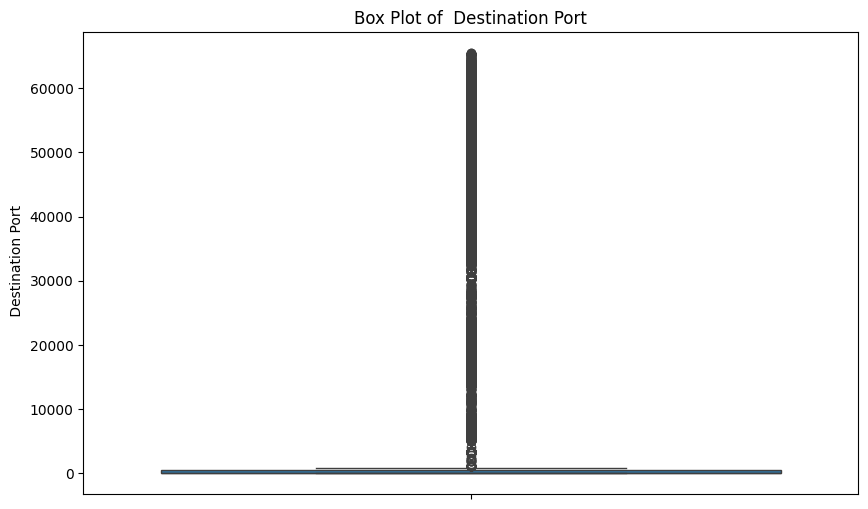

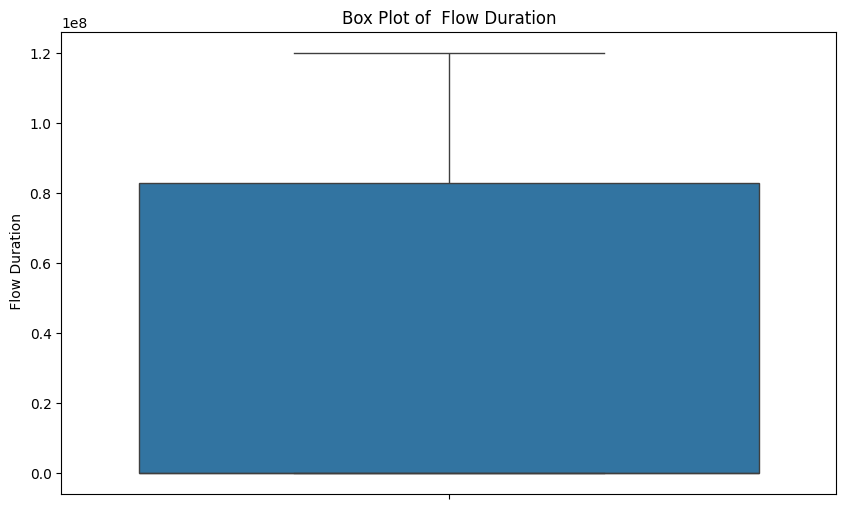

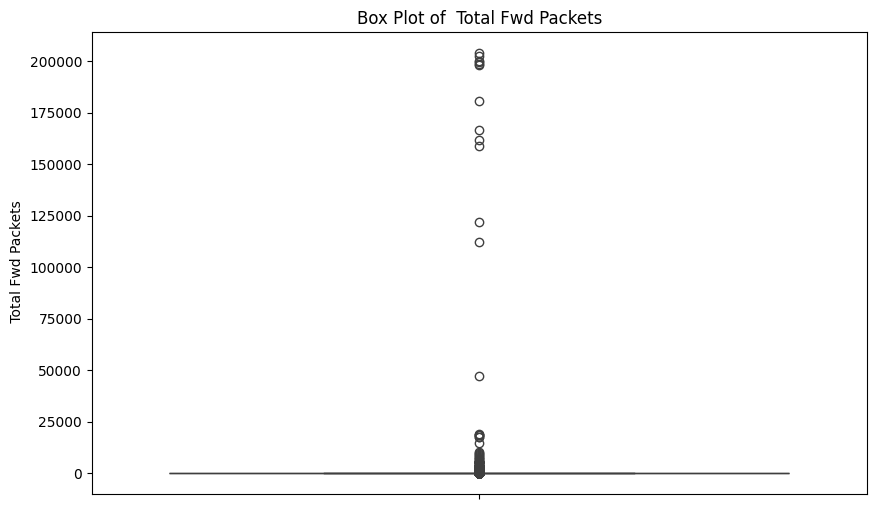

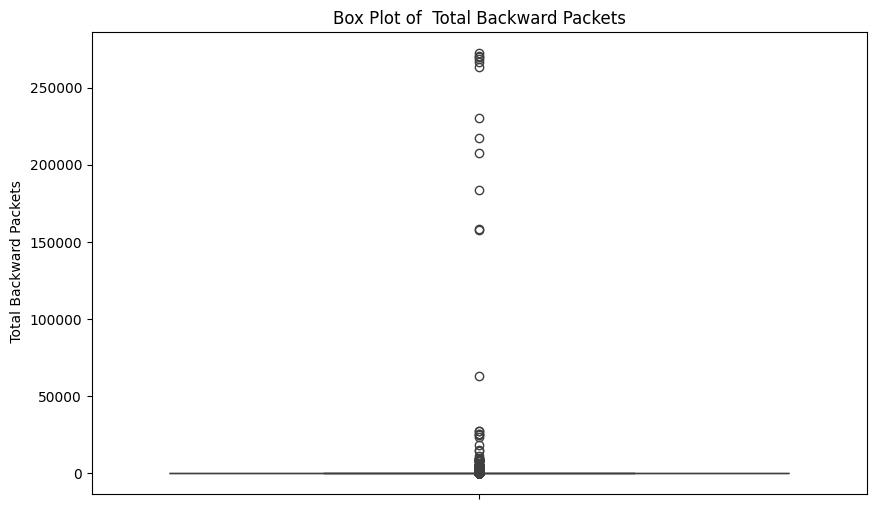

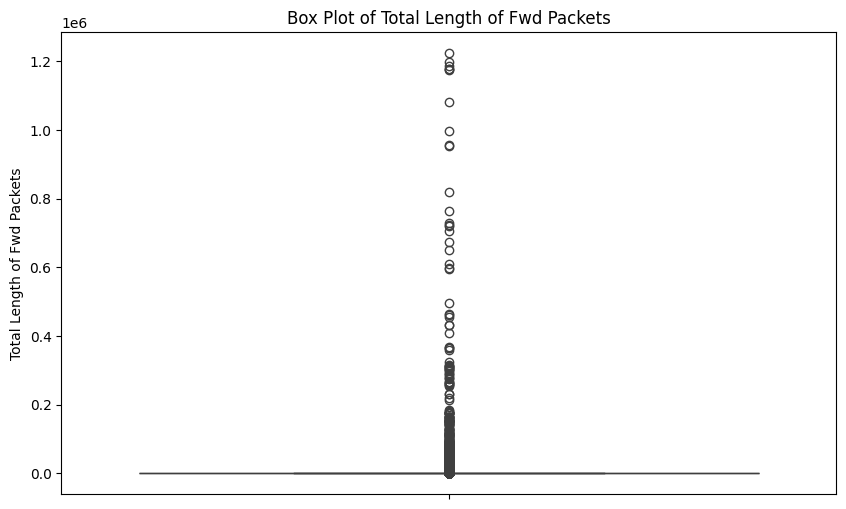

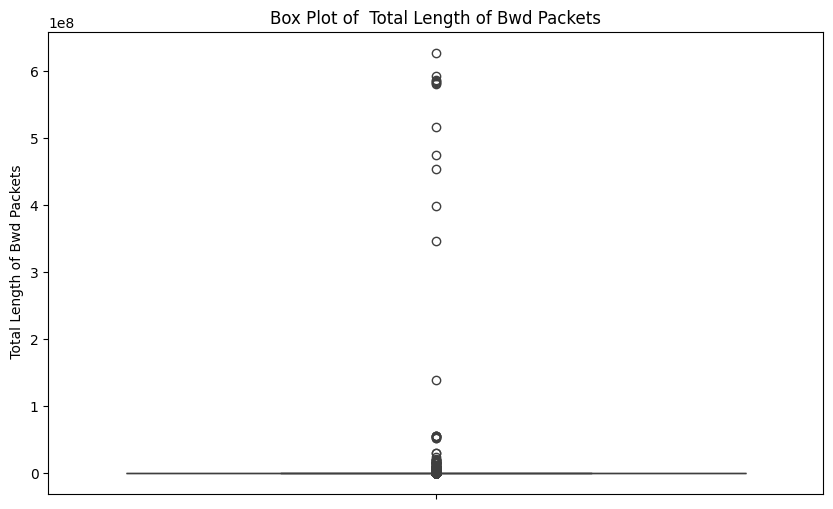

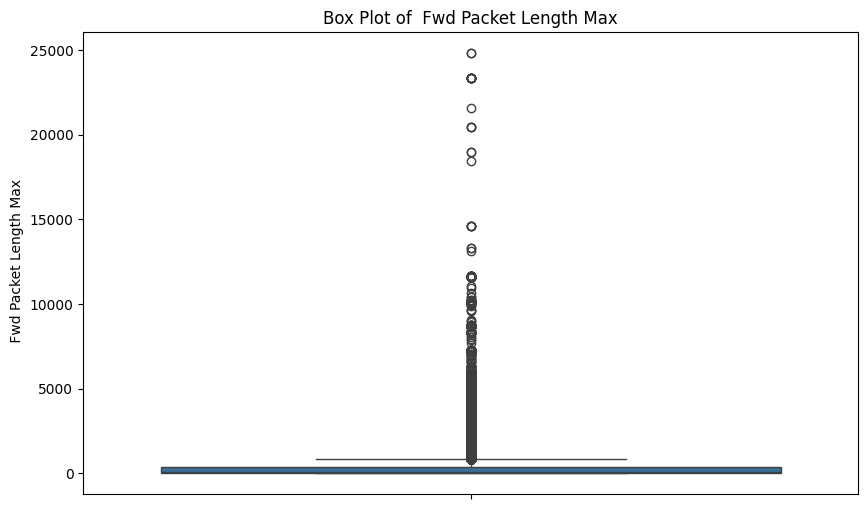

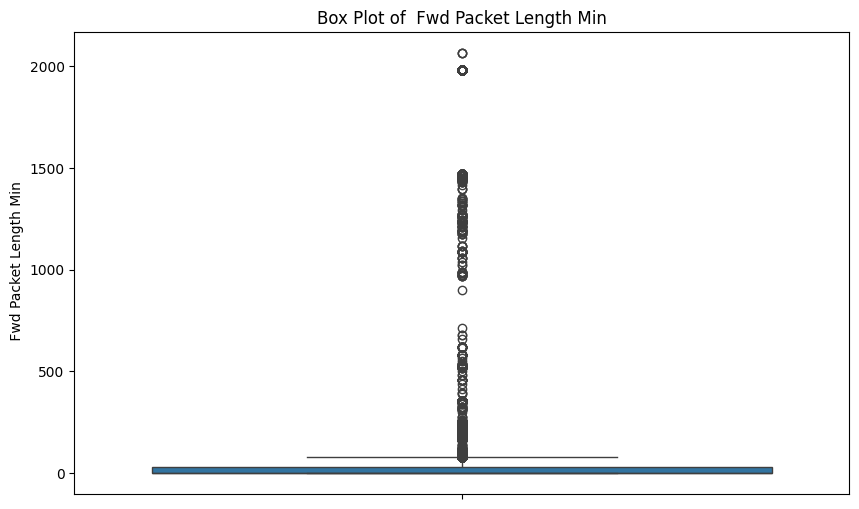

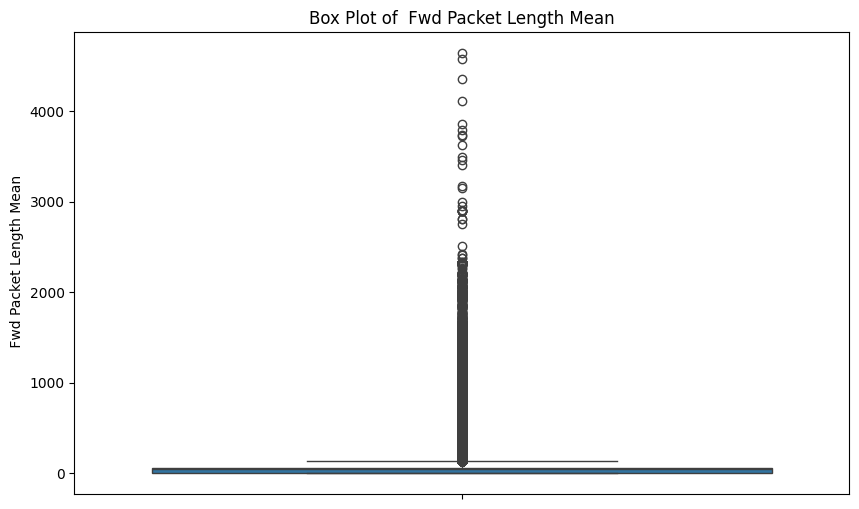

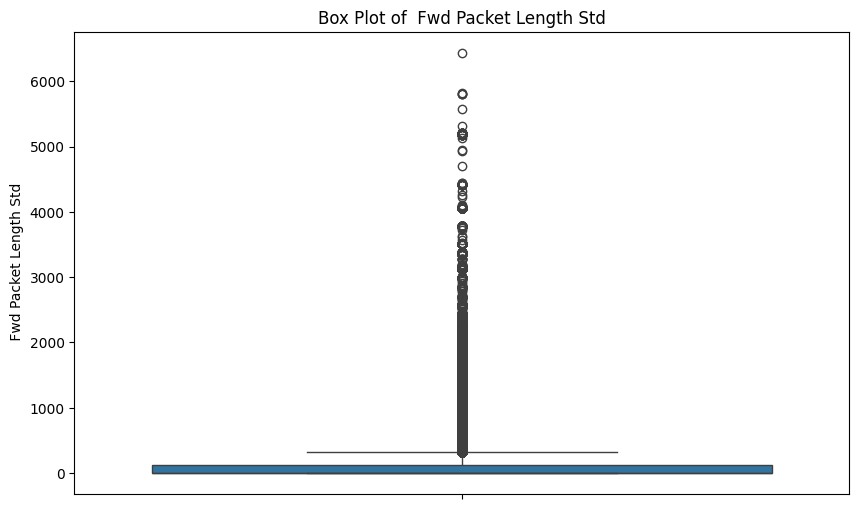

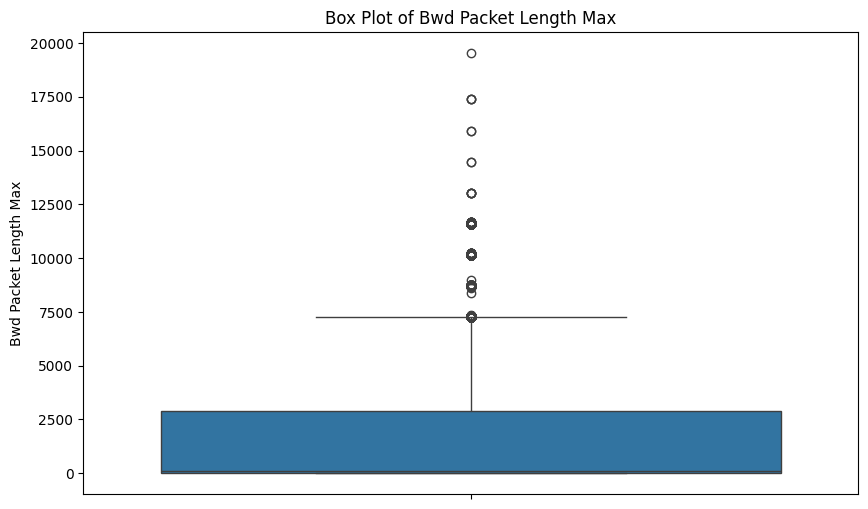

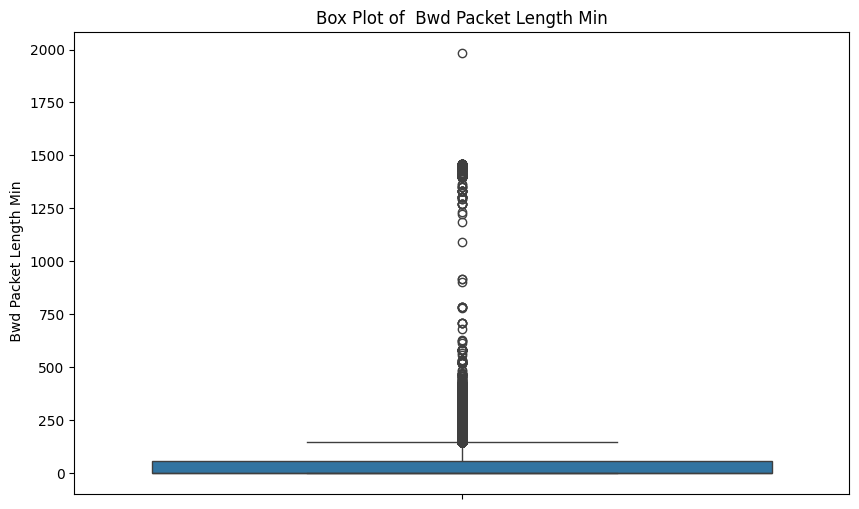

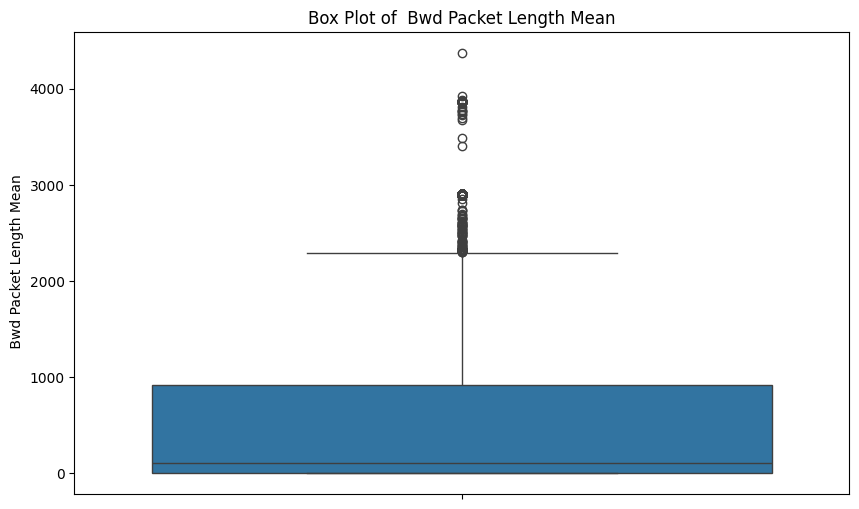

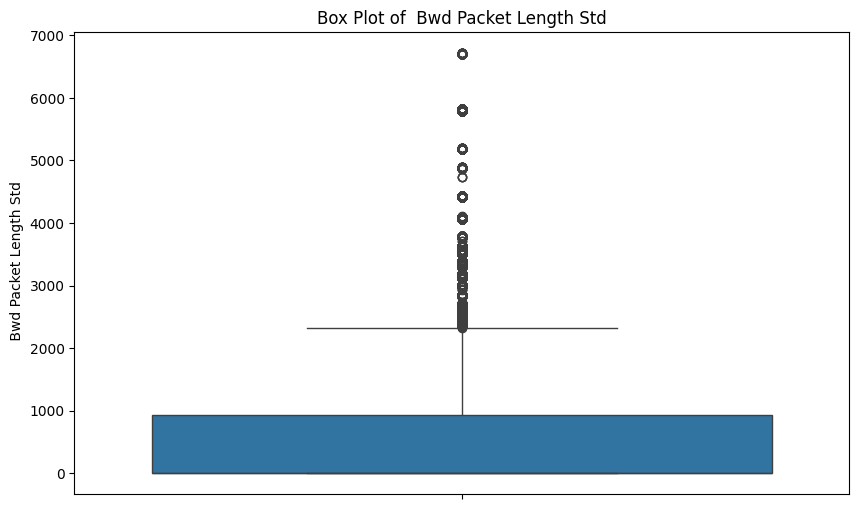

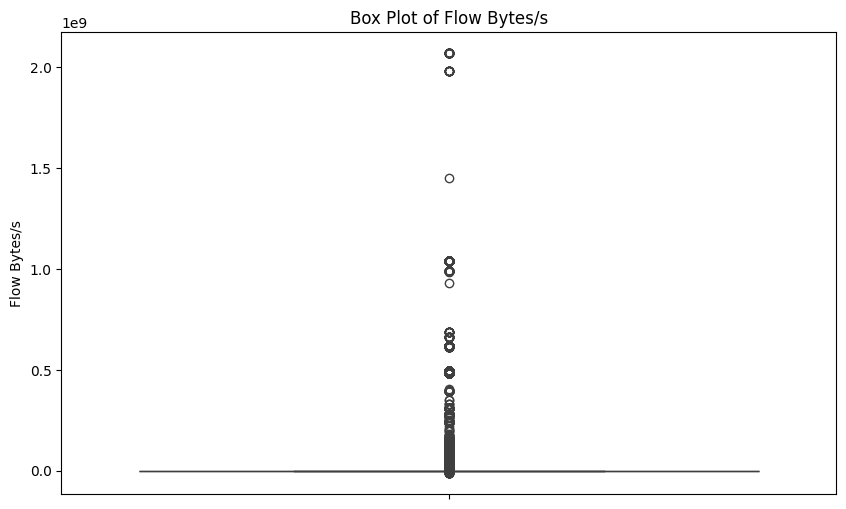

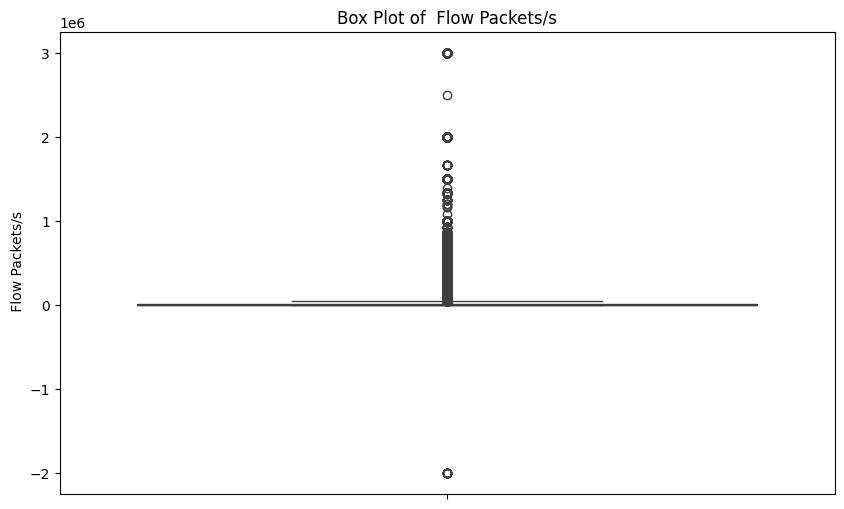

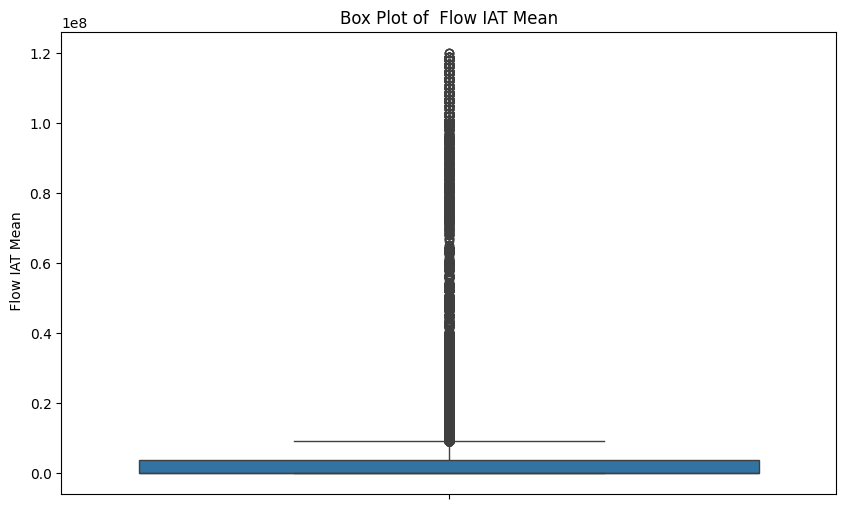

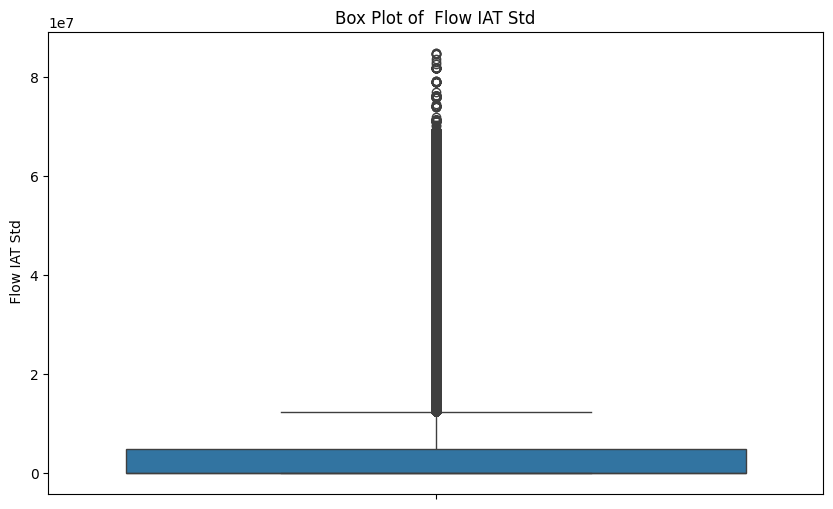

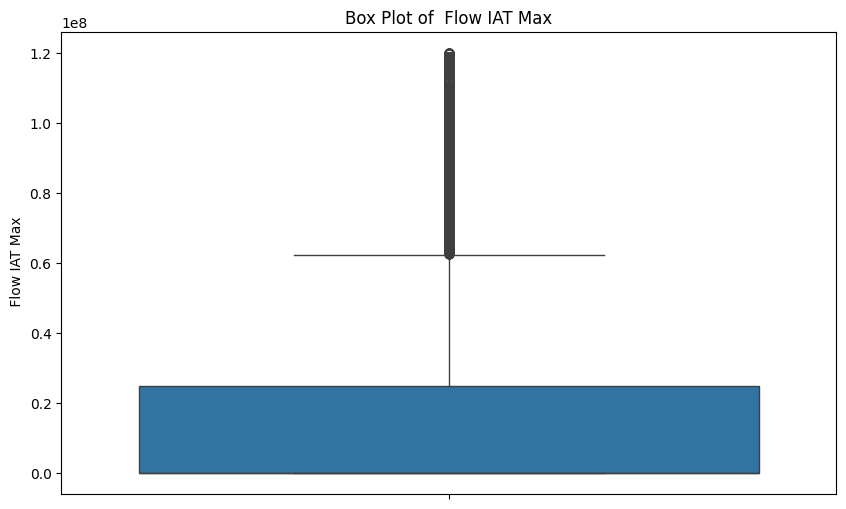

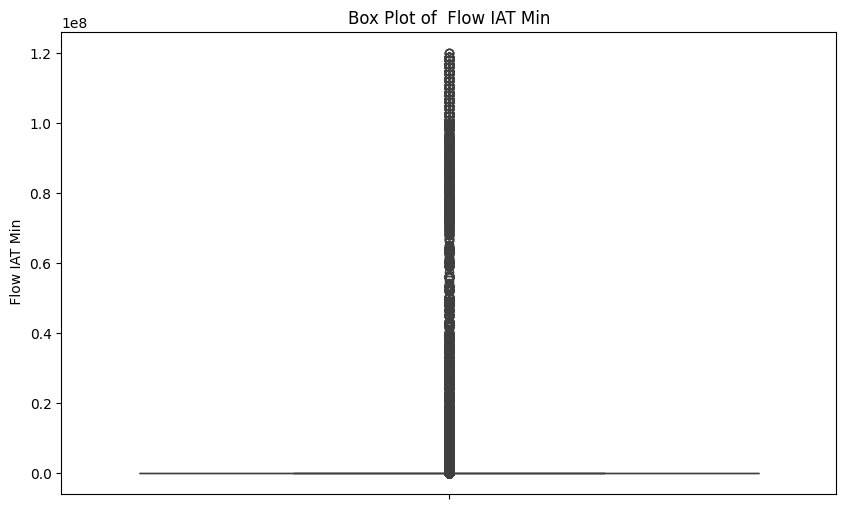

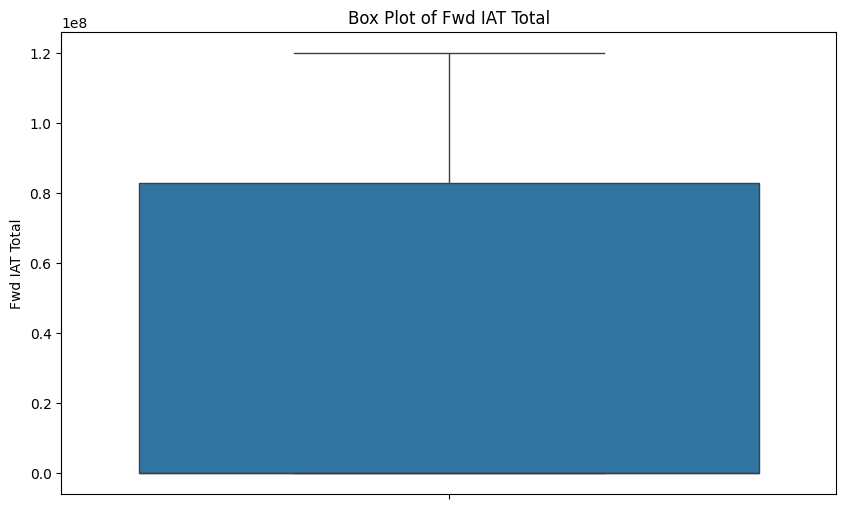

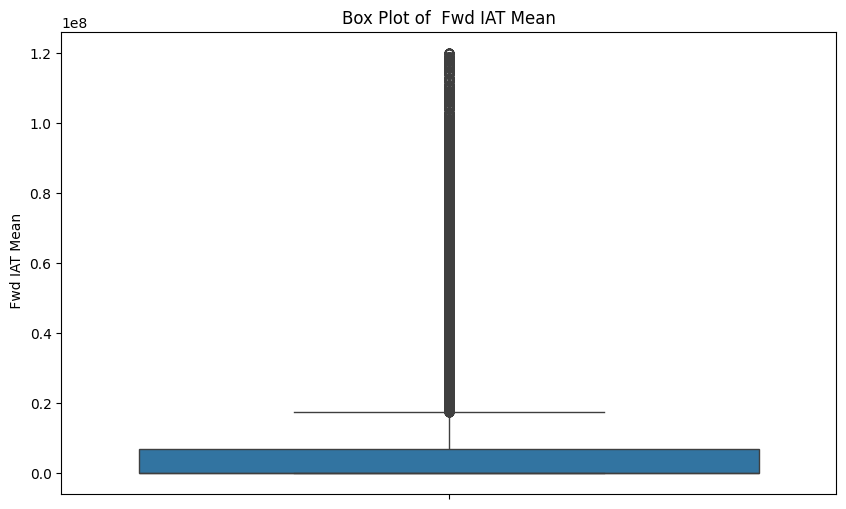

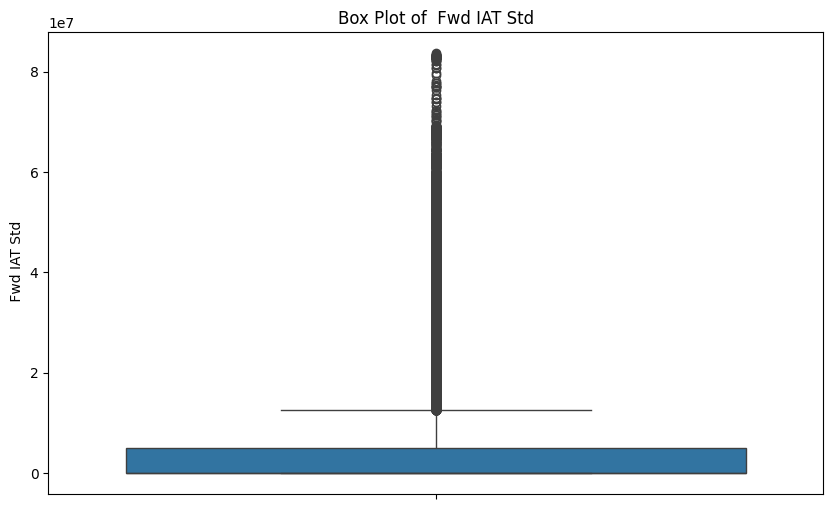

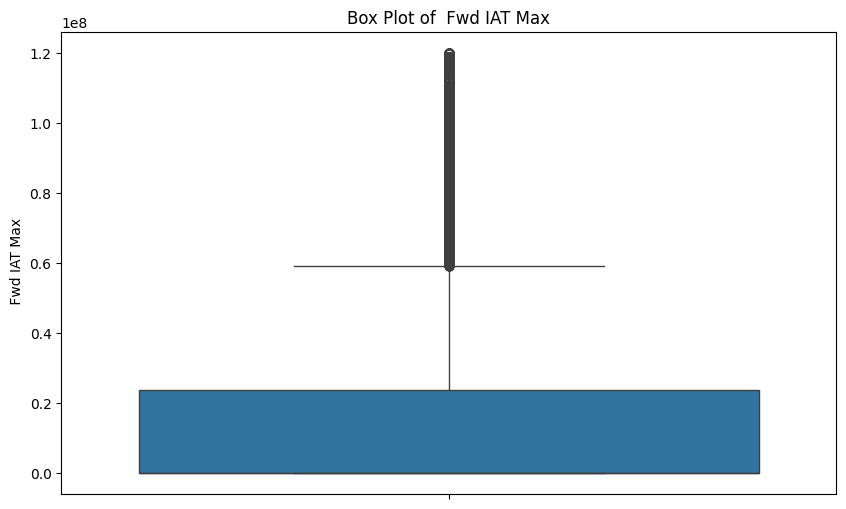

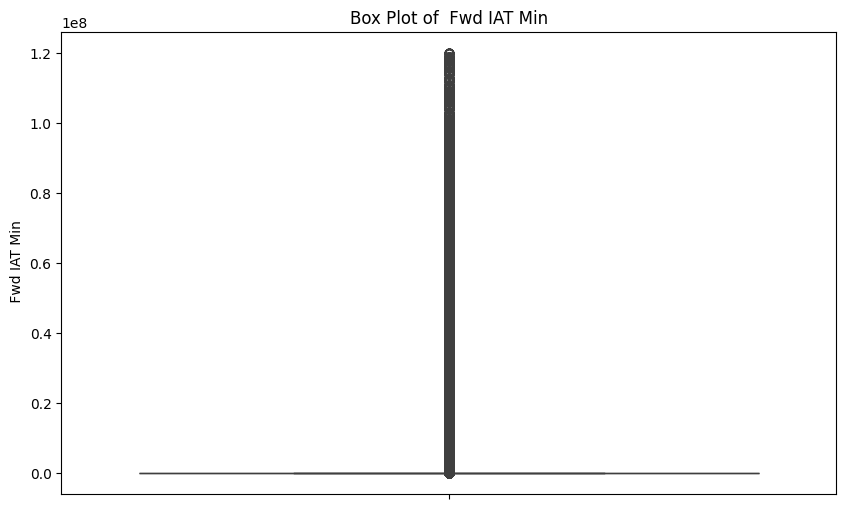

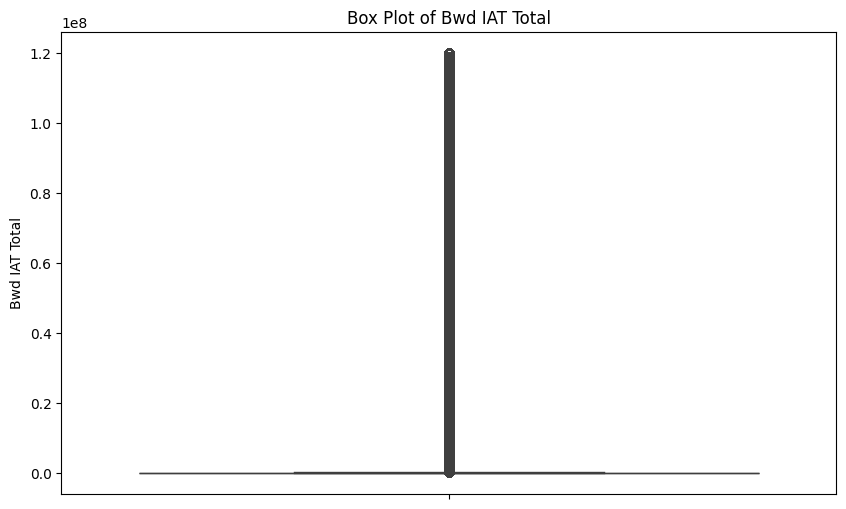

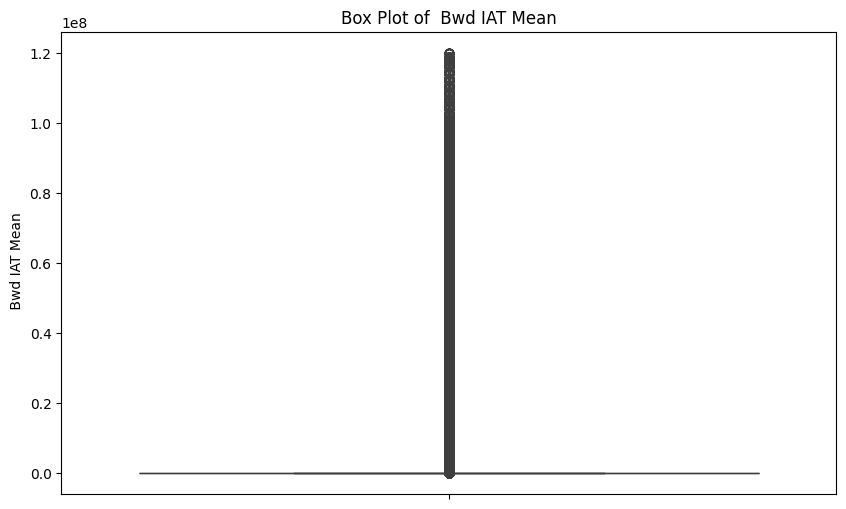

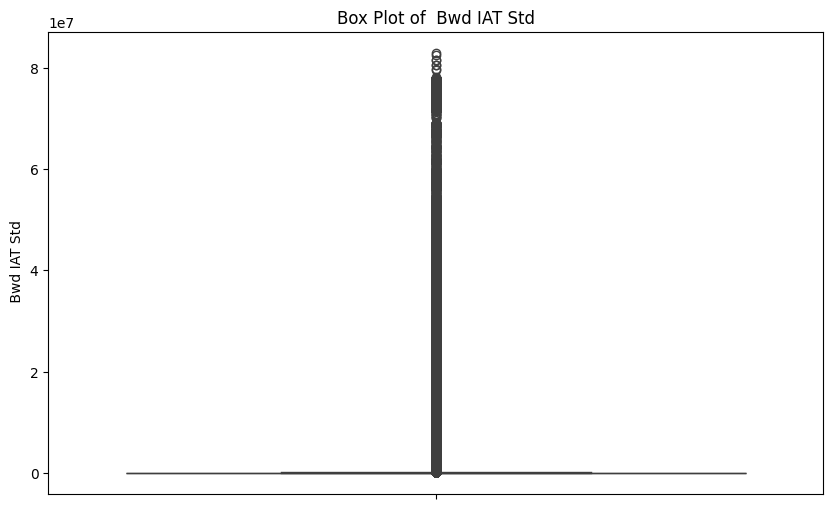

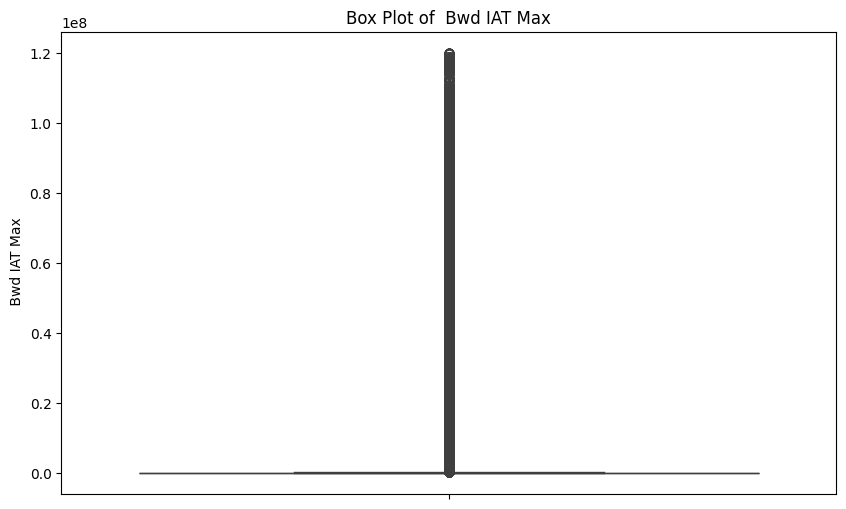

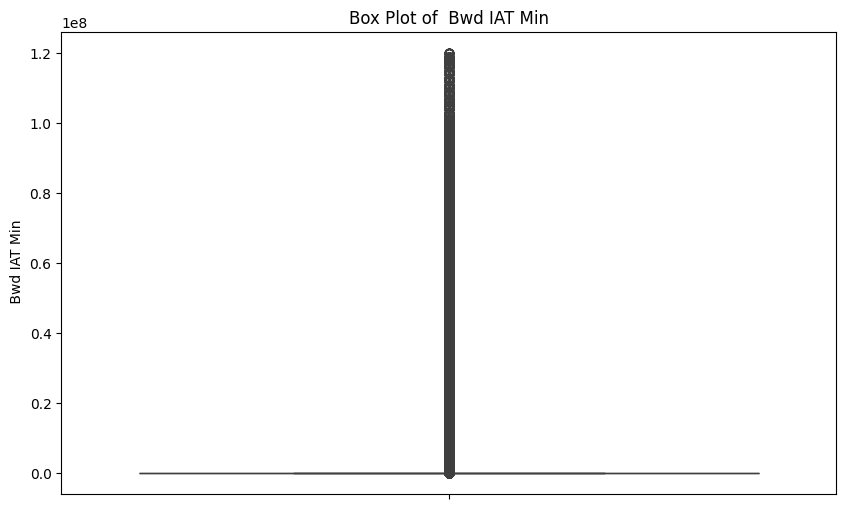

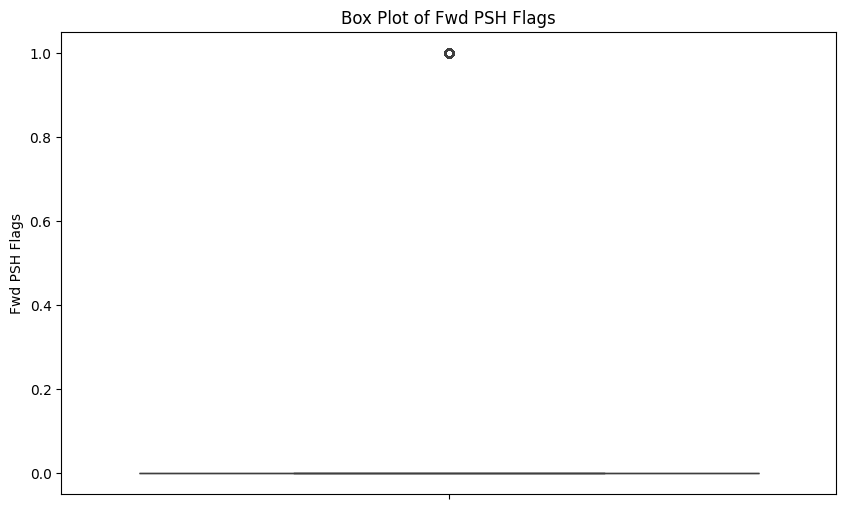

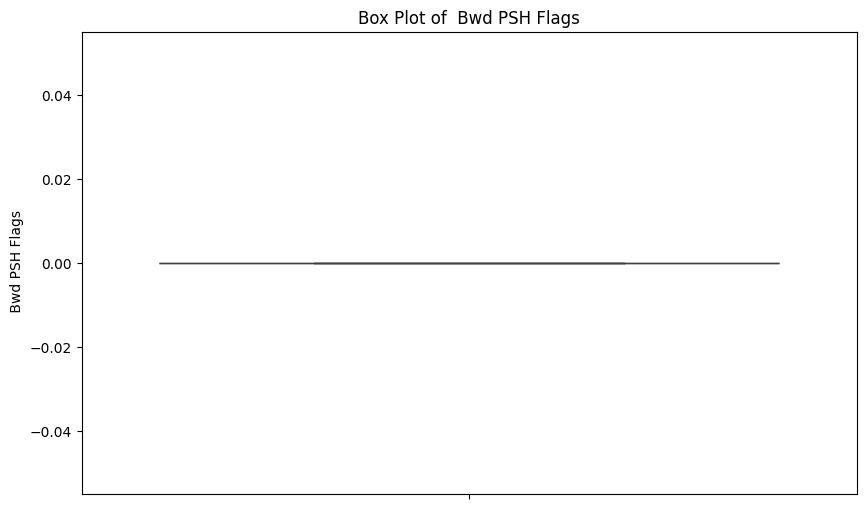

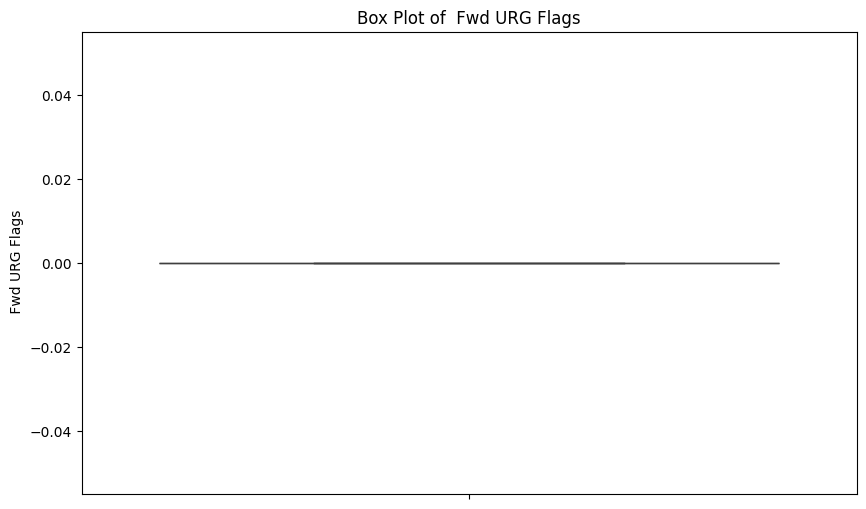

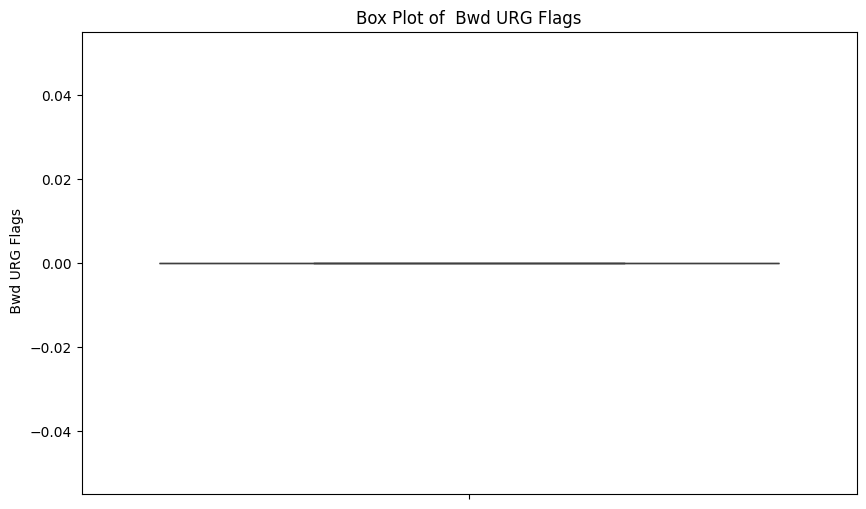

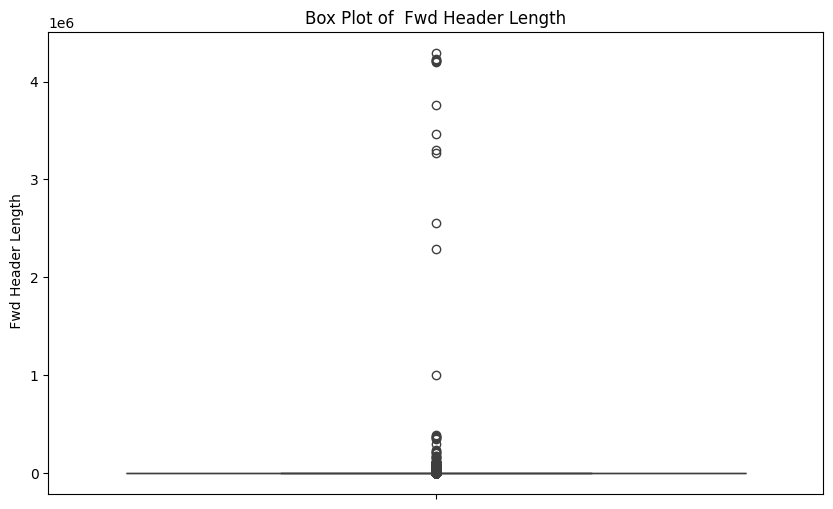

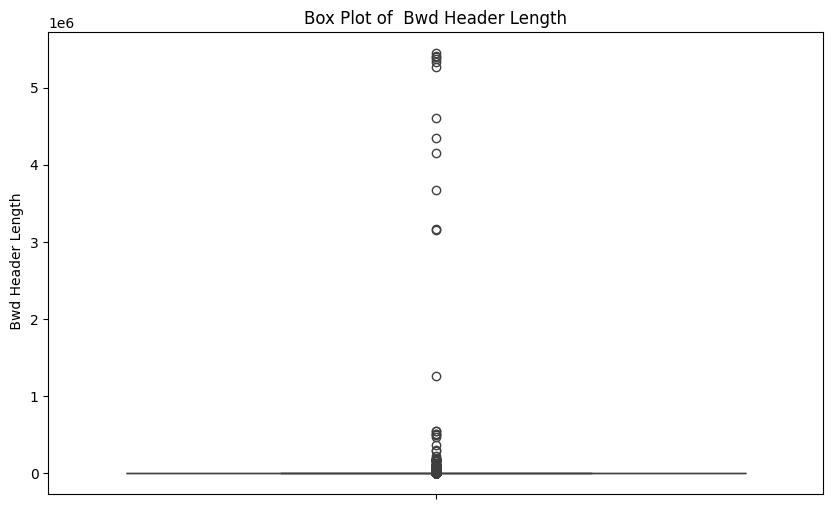

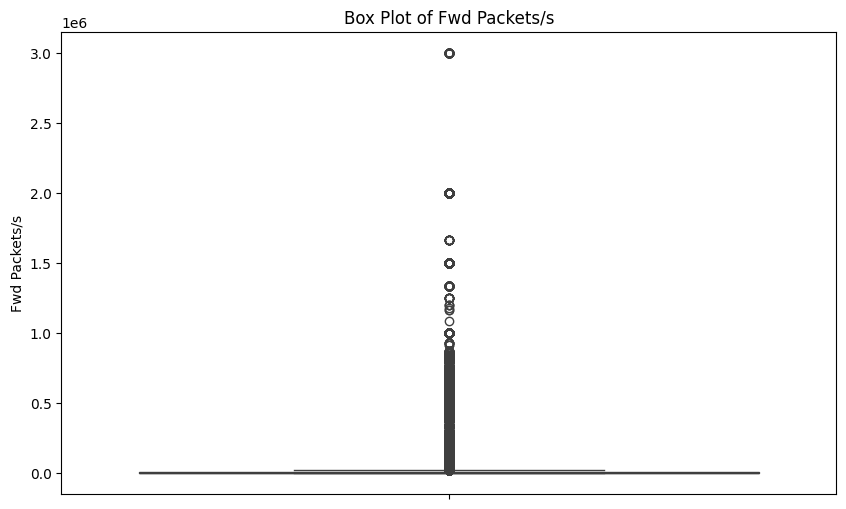

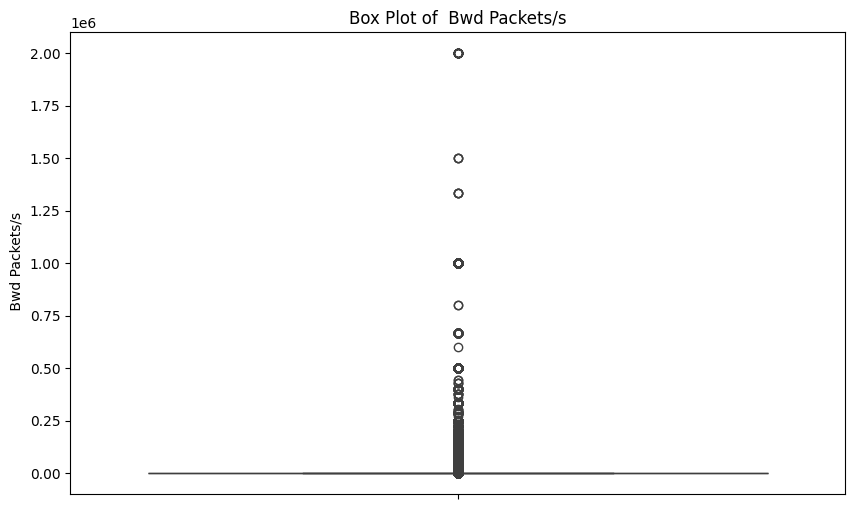

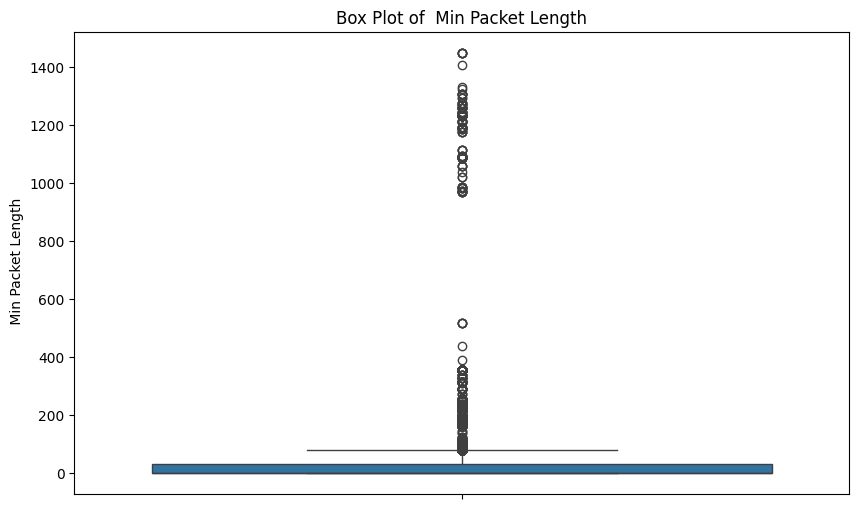

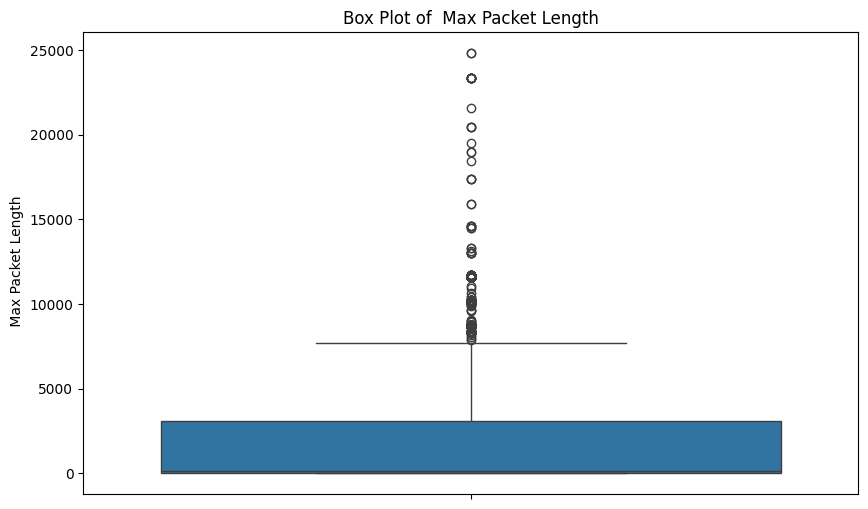

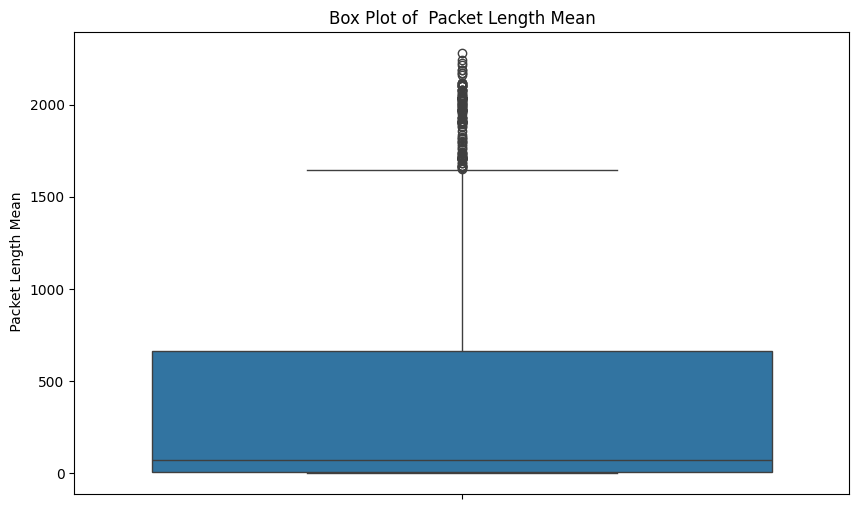

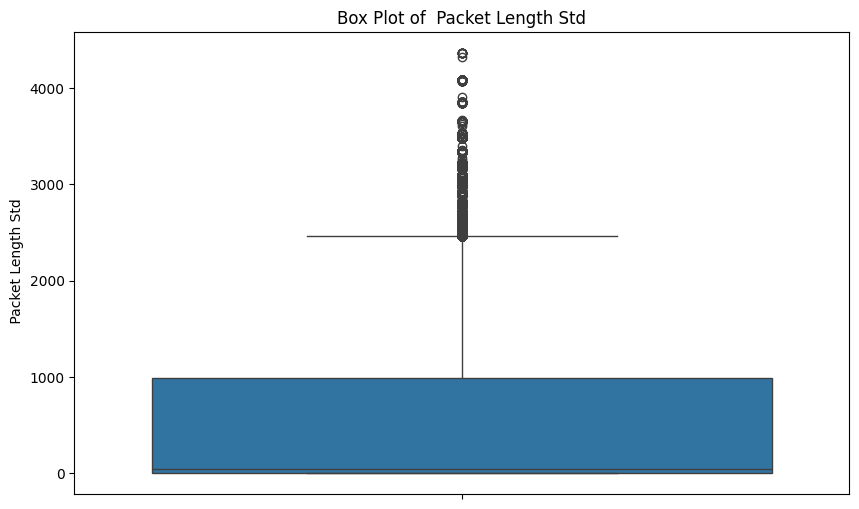

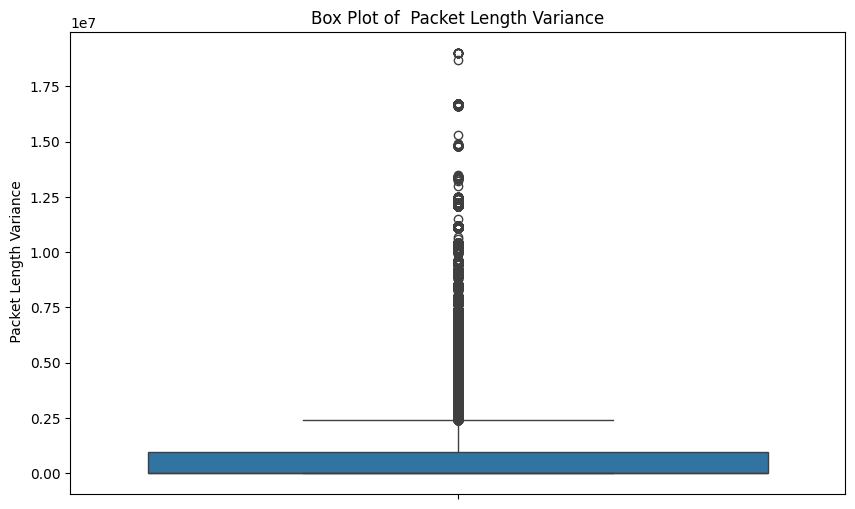

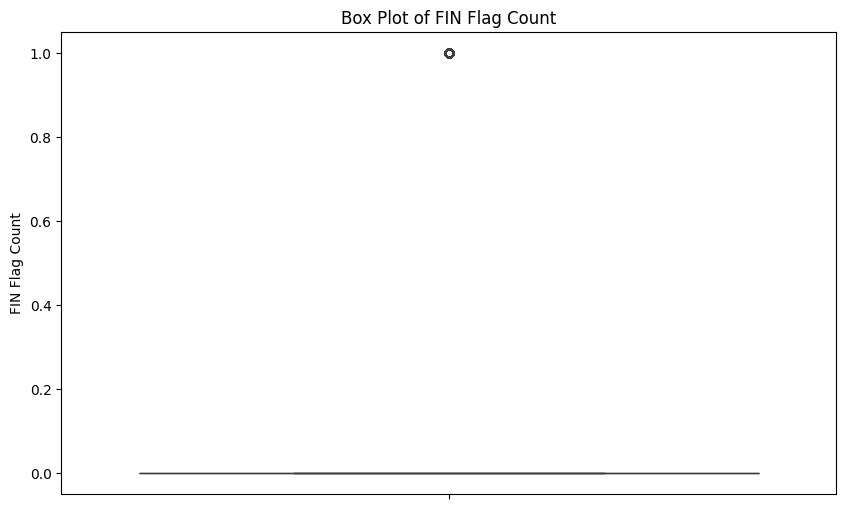

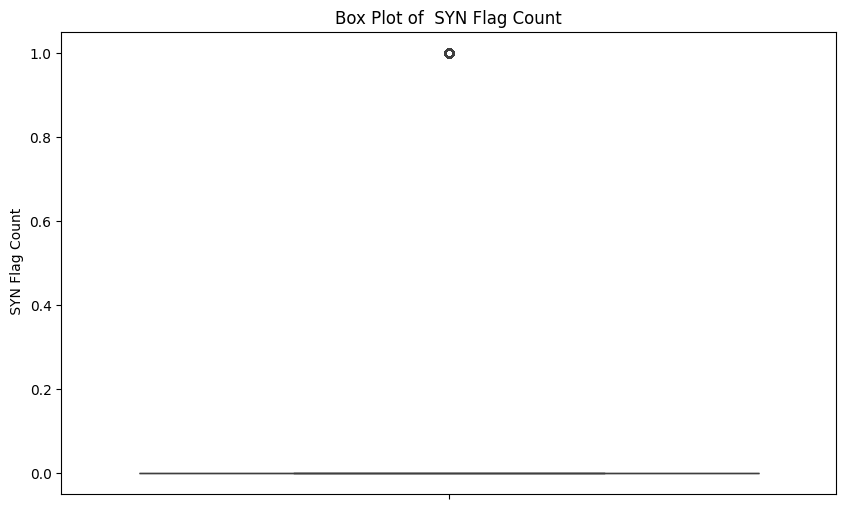

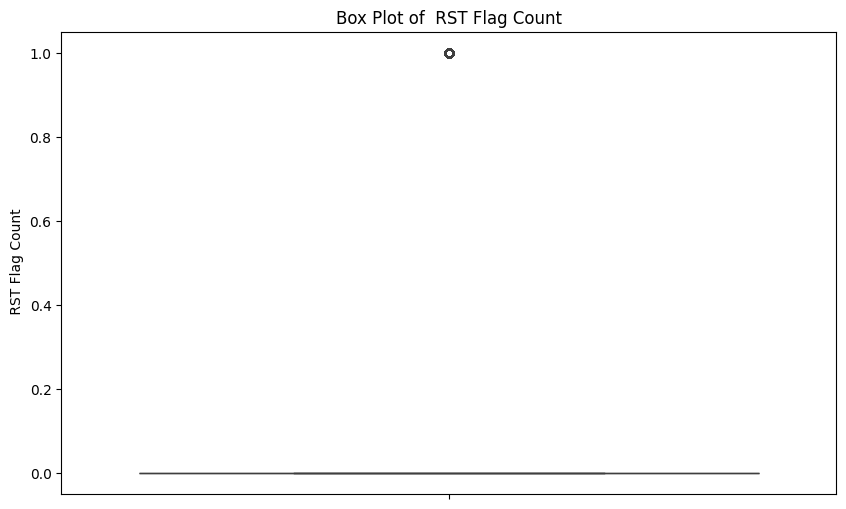

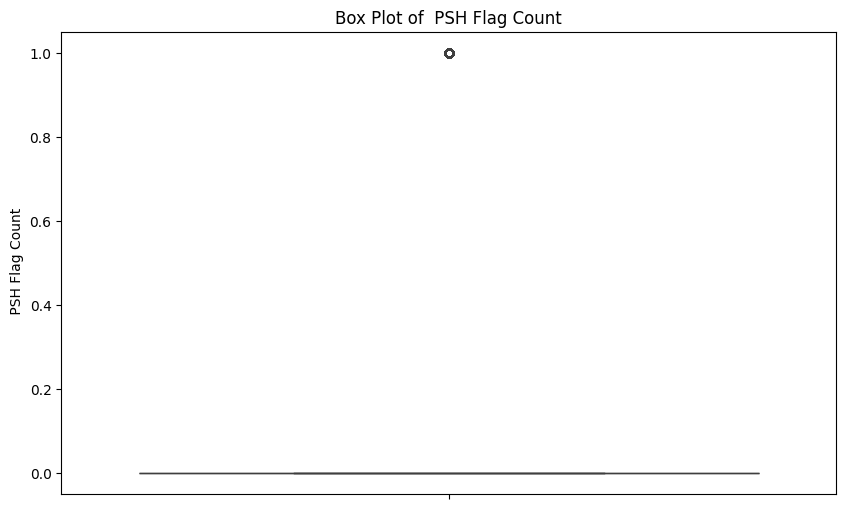

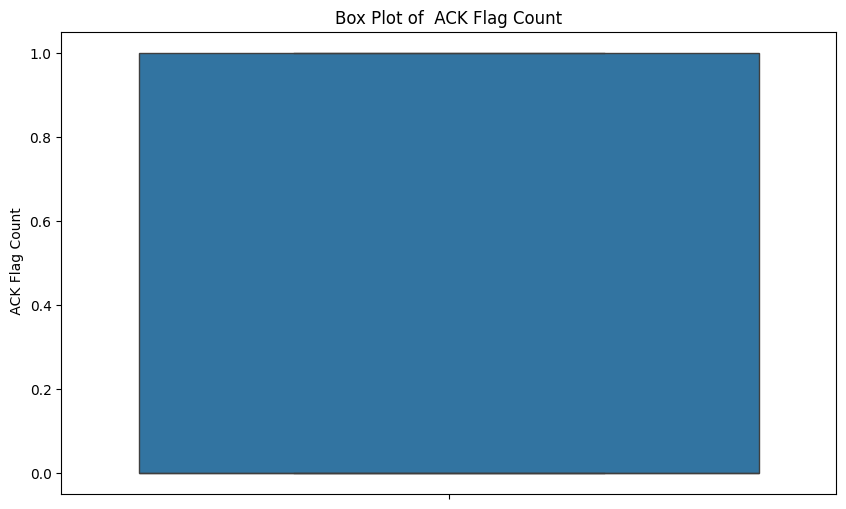

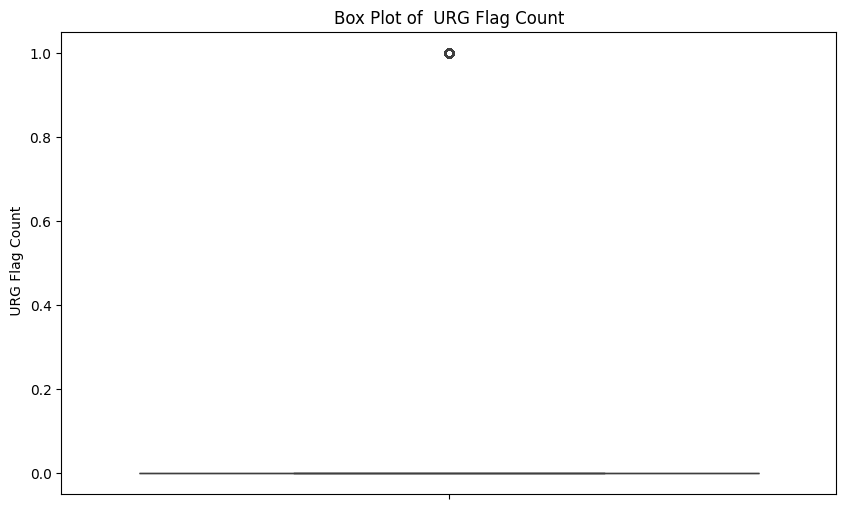

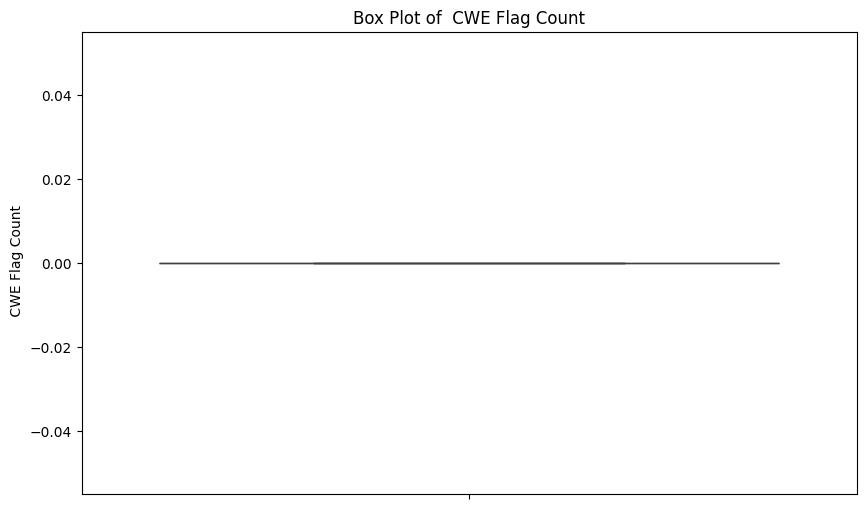

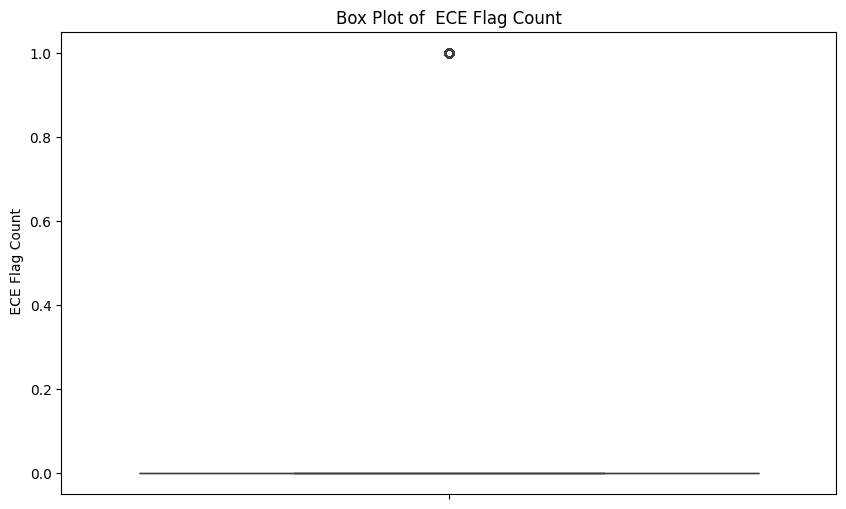

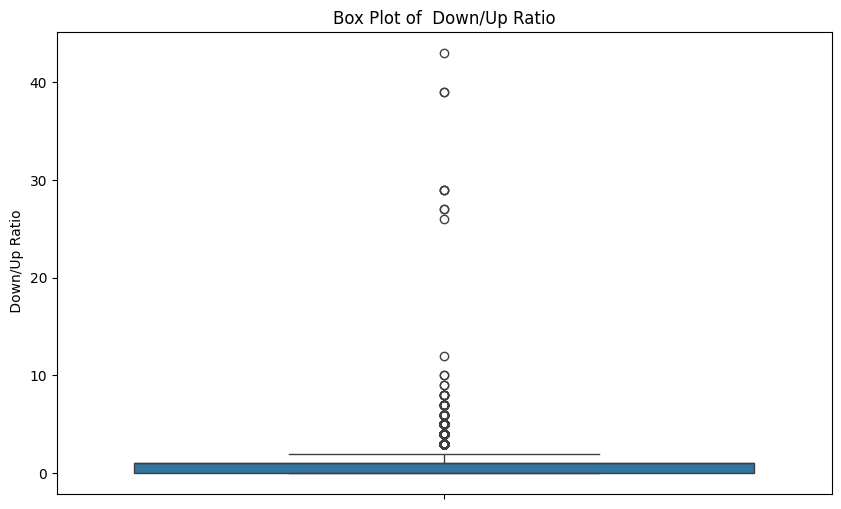

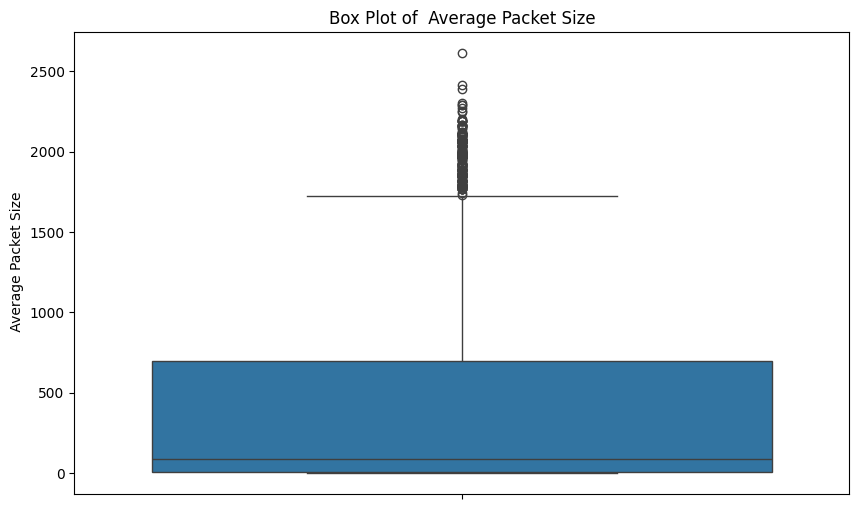

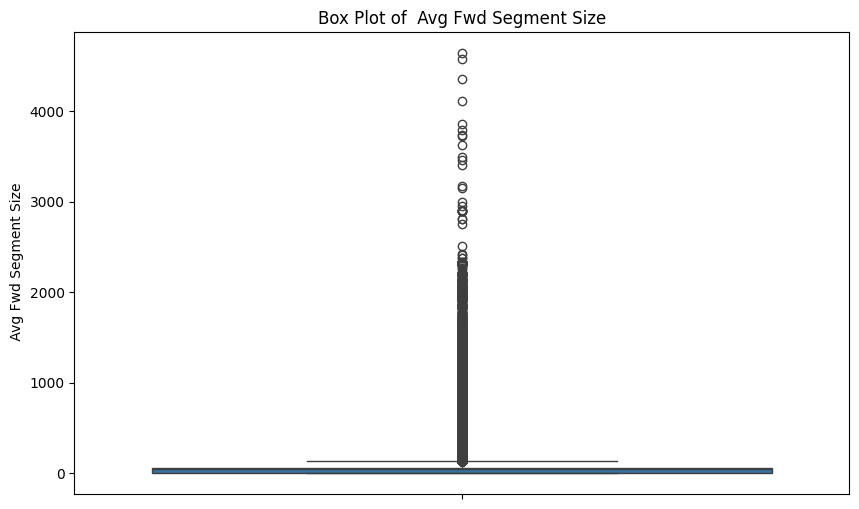

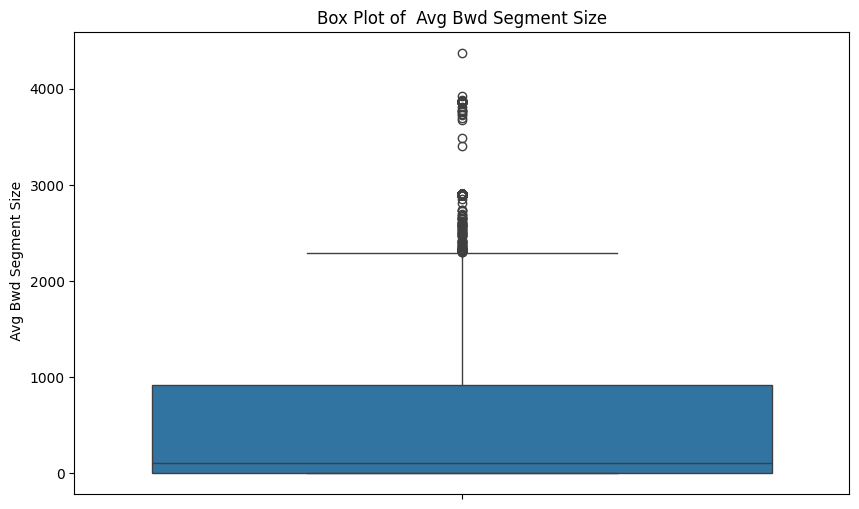

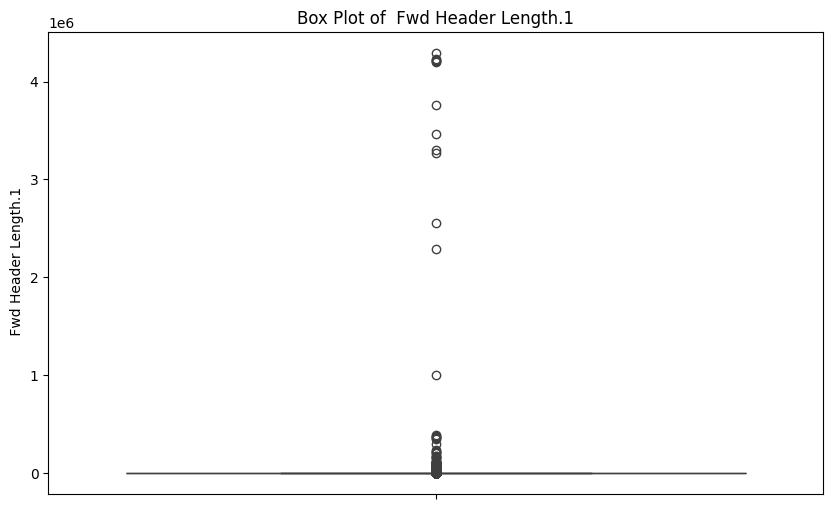

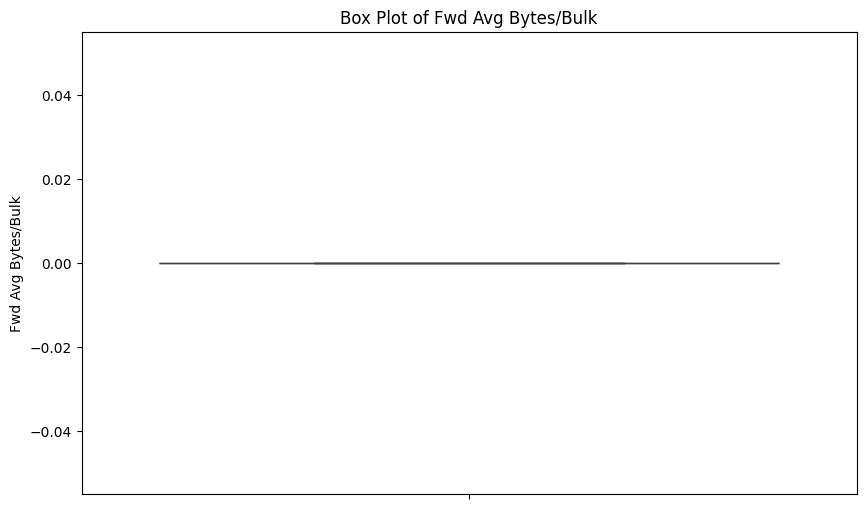

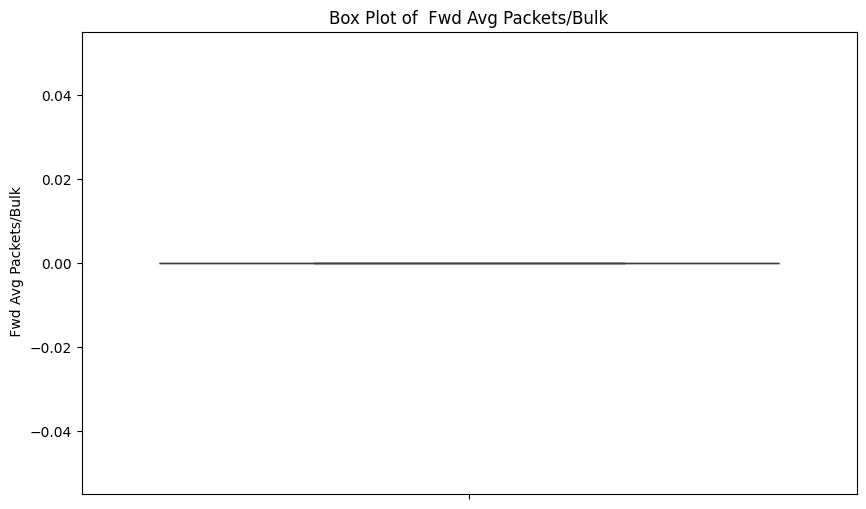

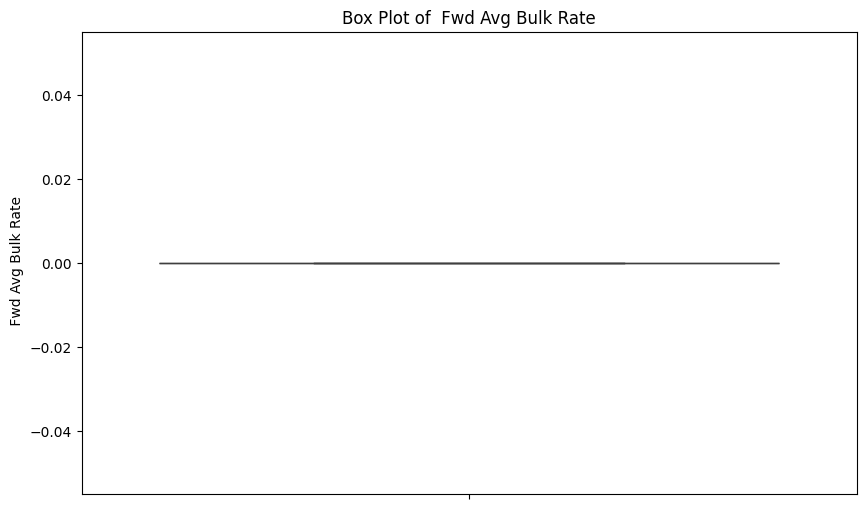

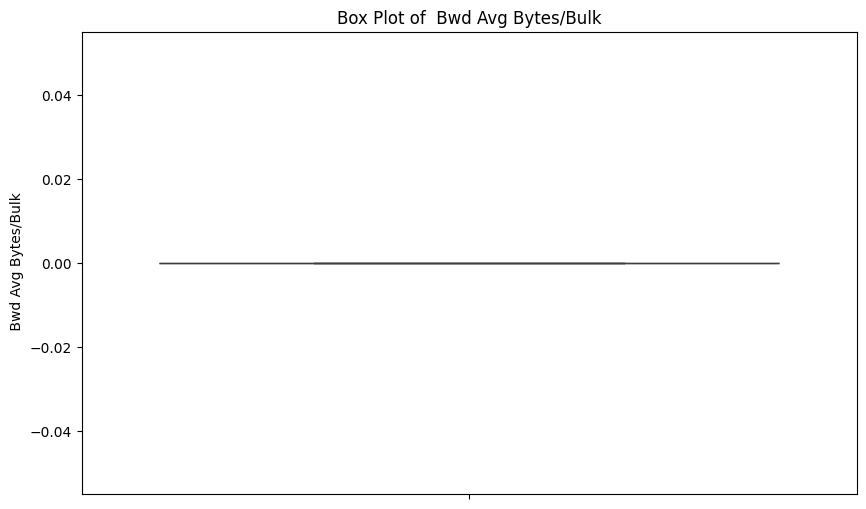

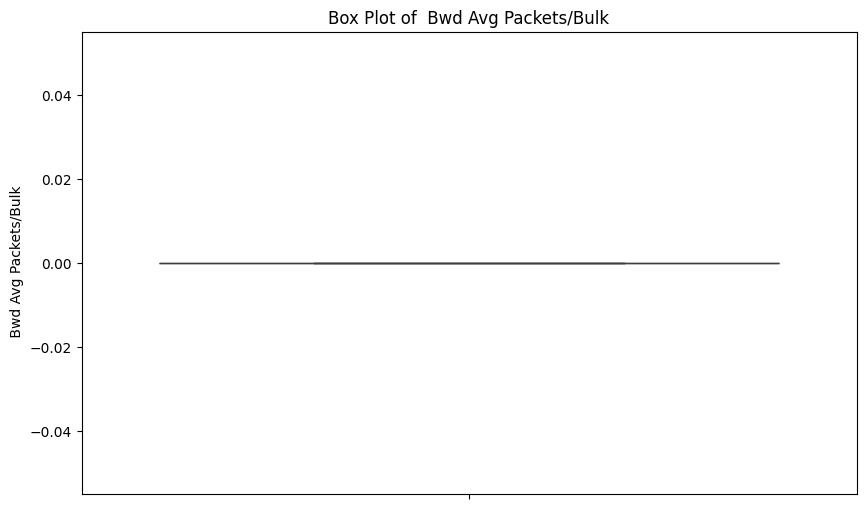

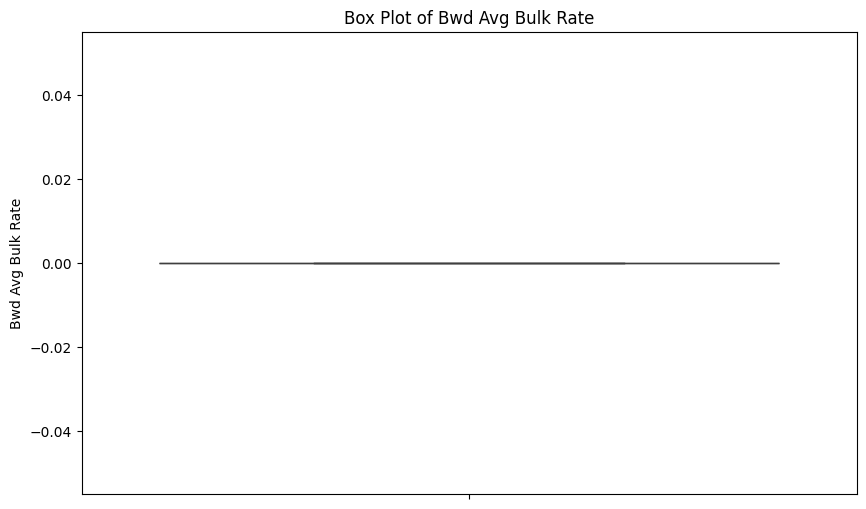

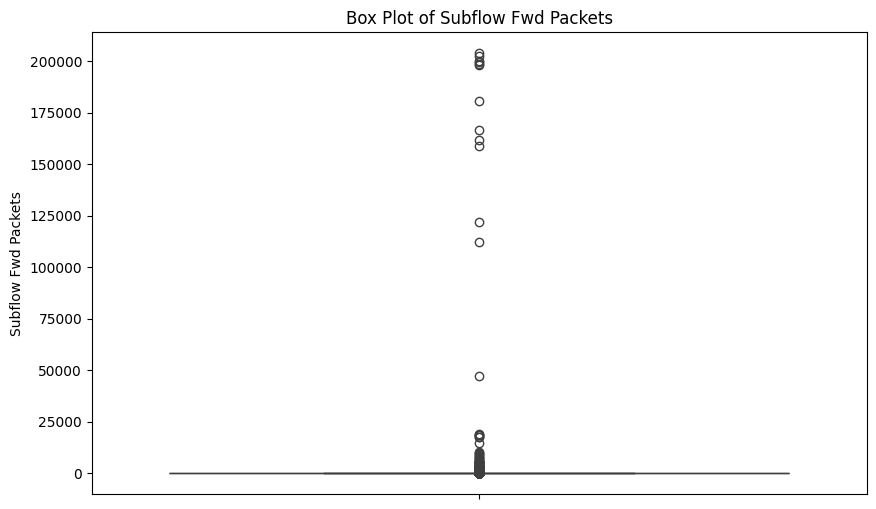

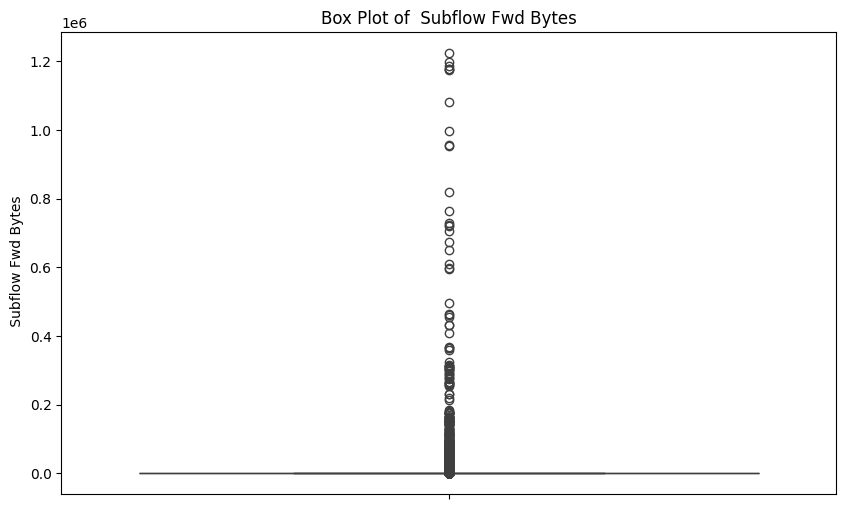

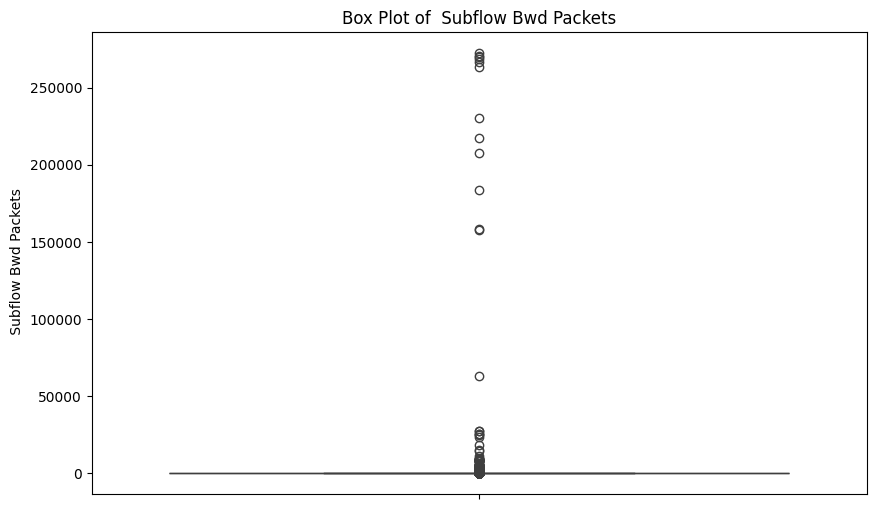

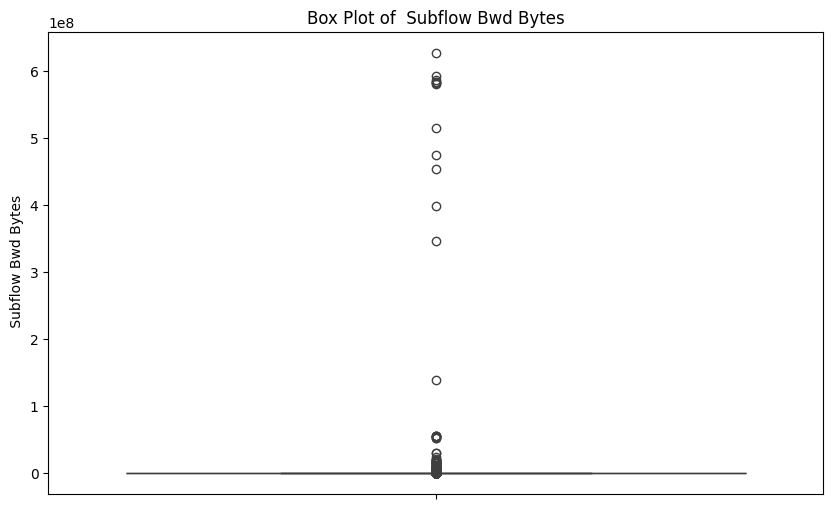

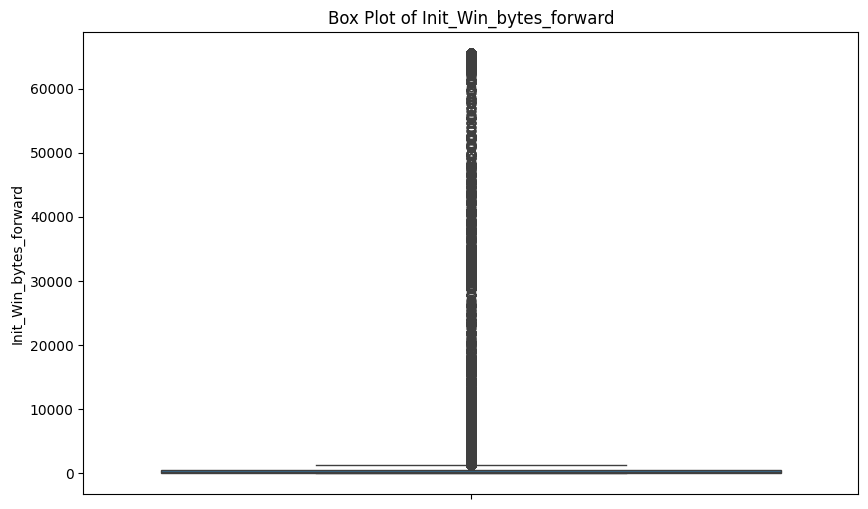

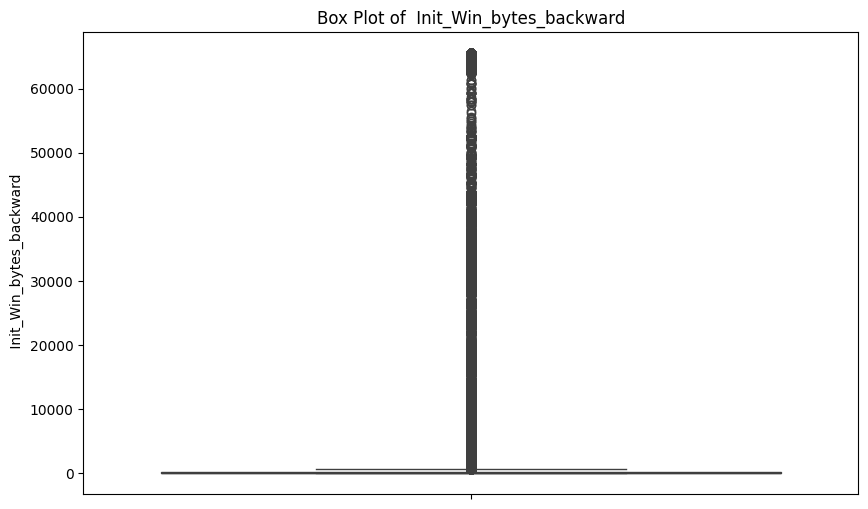

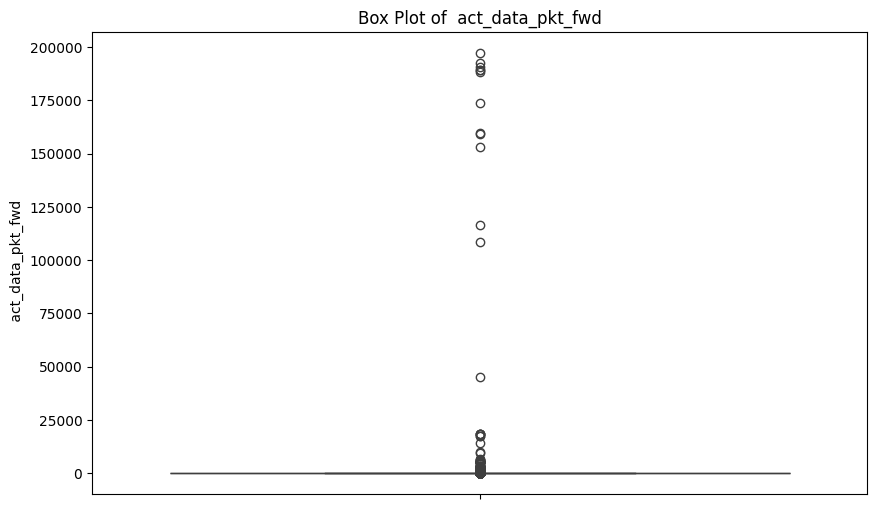

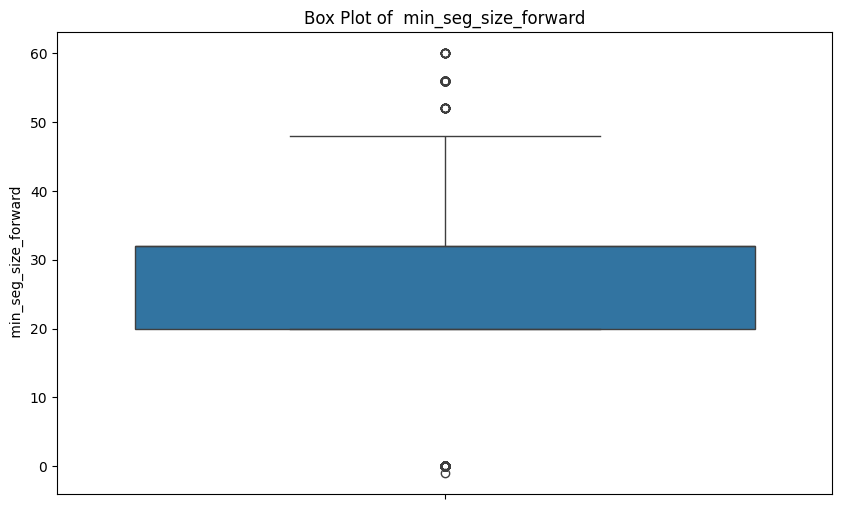

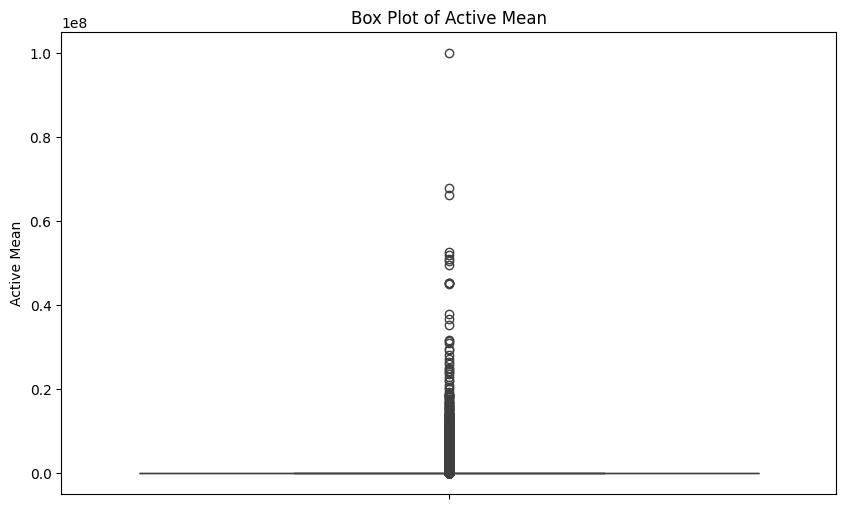

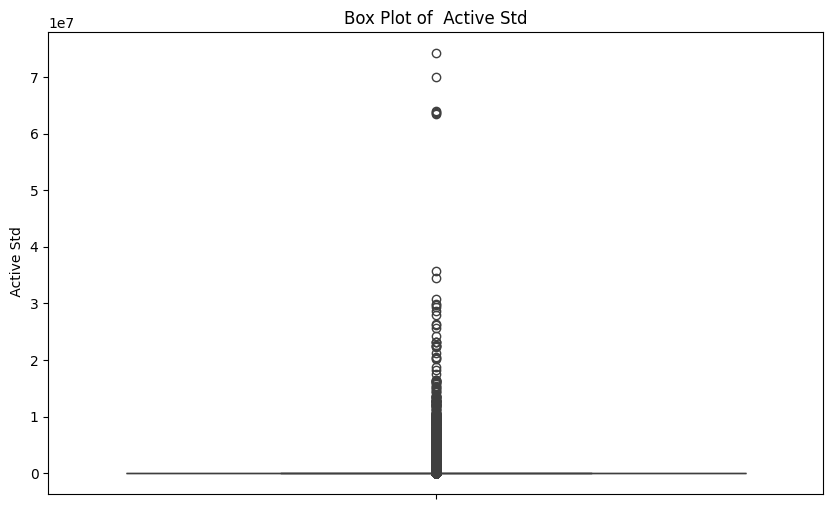

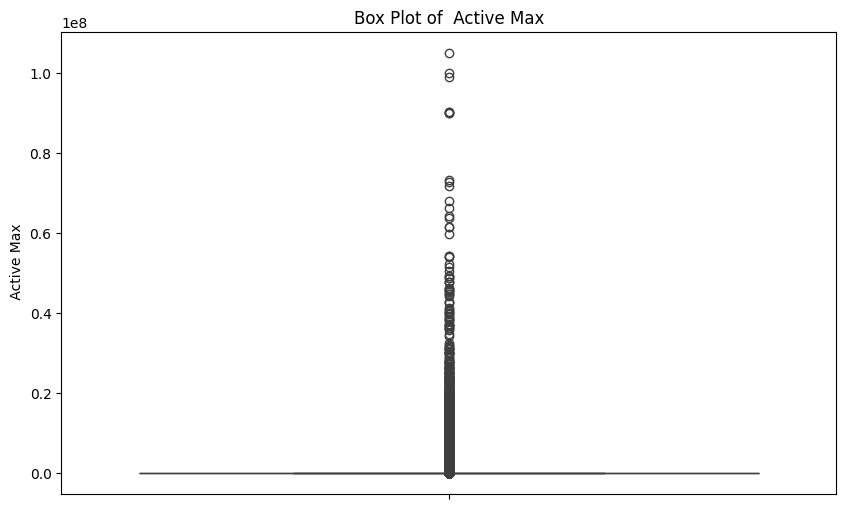

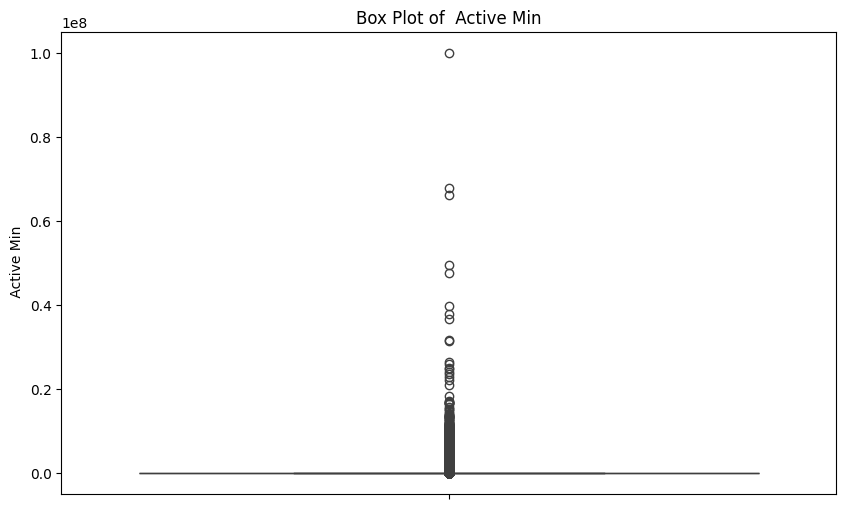

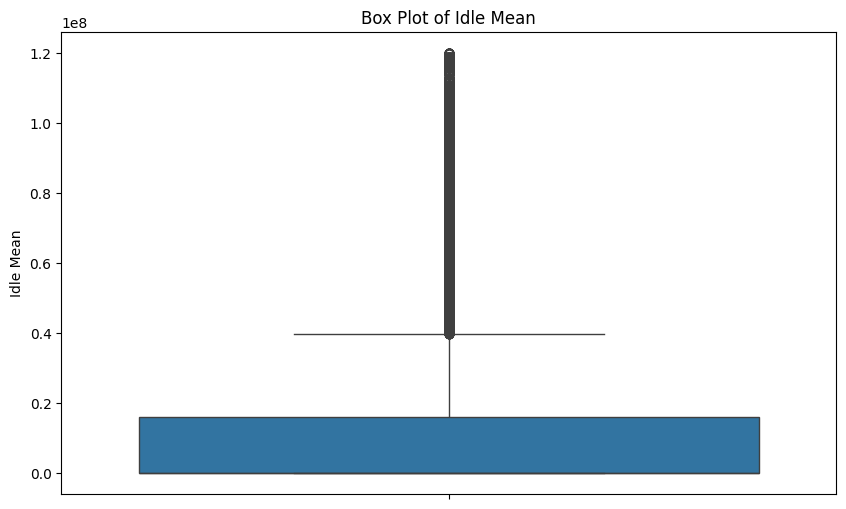

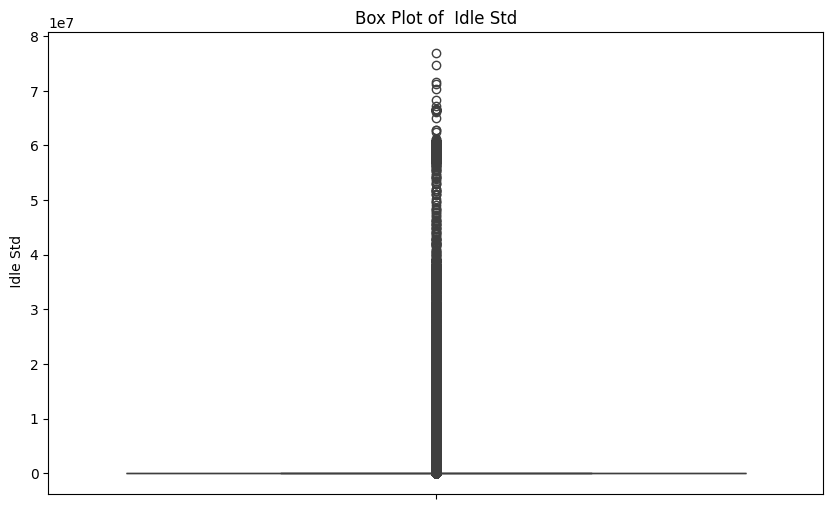

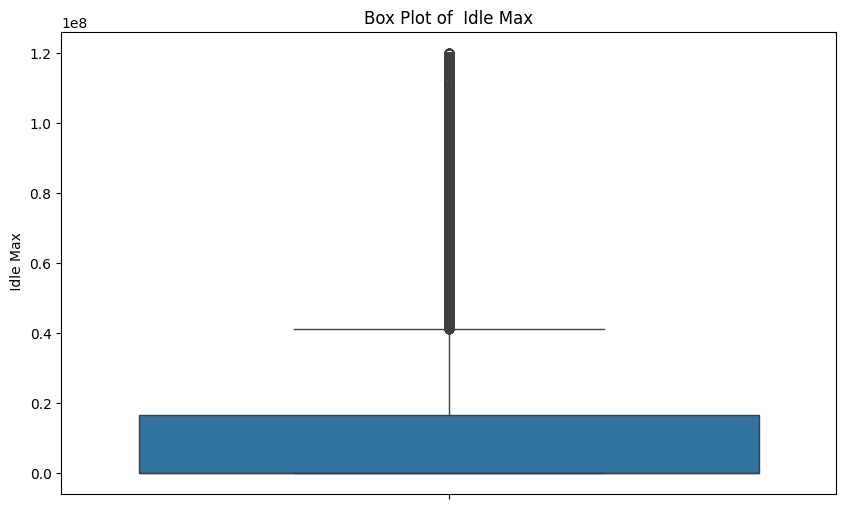

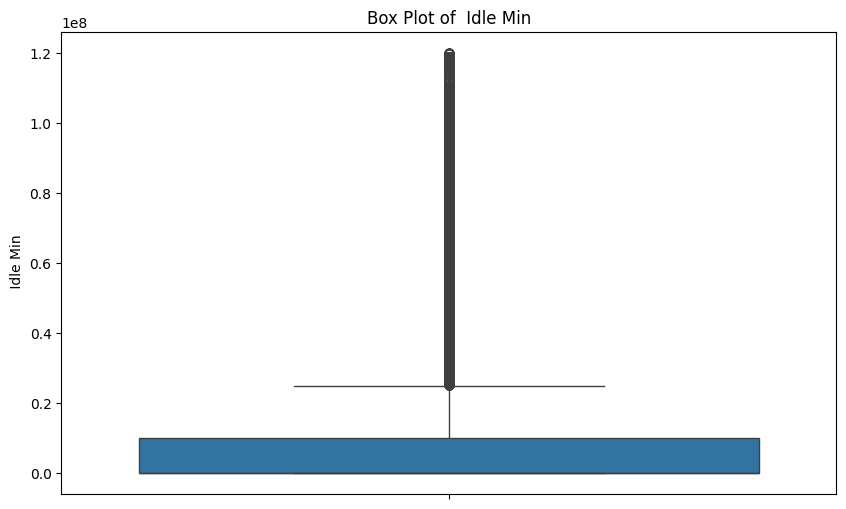

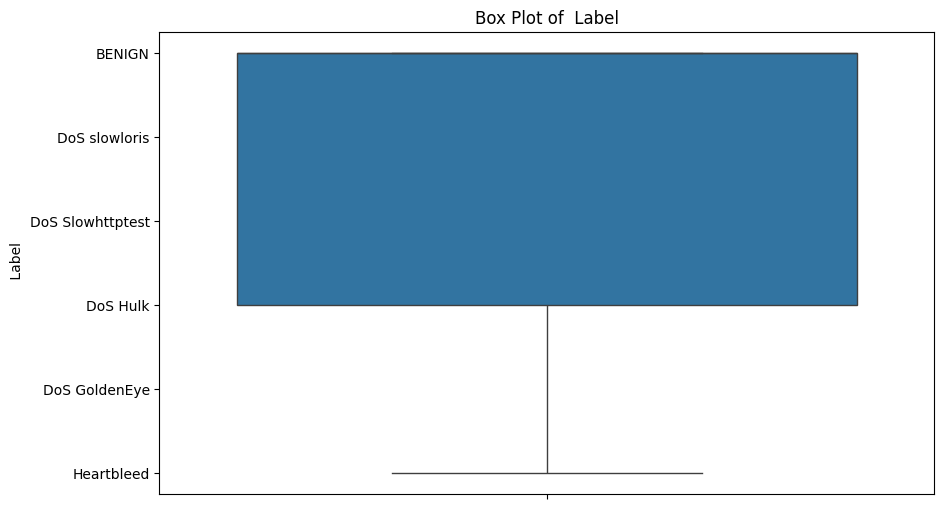

In [27]:
for column in df.columns:
    plot_boxplot(df, column)

In [28]:
# for column in df.columns:
#     plot_distribution(df, column)

- keep only one feature from each highly correlated pair.
- need to Missing & Infinite Values ( Flow Bytes's  has missing valyues ) seems to be MAR/ MNAR

Features selected 
Flow Duration
Fwd IAT Total
Total Fwd Packets
Total Backward Packets
Total Length of Bwd Packets
Fwd Packet Length Max
Fwd Packet Length Mean
Bwd Packet Length Max
Bwd Packet Length Mean
Flow Packets/s
Flow IAT Mean
Bwd IAT Mean
Fwd Header Length
Bwd Header Length
Subflow Fwd Packets
Subflow Bwd Packets